In [7]:
# ============================================================
# CONFIDENCE-AWARE BINARY CLASSIFICATION FRAMEWORK
# FOR AMBIGUOUS SOFTWARE REQUIREMENTS DETECTION
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_PATH = r"C:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\notebooks\pure_experiment_data\profzivkovic-software-requirements-ambiguity-detection-replication-e36e5b3\data\pure_labeled.csv"

TEXT_COLUMN = "requirement_text"
LABEL_COLUMN = "label"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (6725, 4)


In [5]:
# ============================================================
# STEP 1 — LOAD PURE LABELED DATASET
# ============================================================

import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Dataset path
# ------------------------------------------------------------

DATA_PATH = r"C:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\notebooks\pure_experiment_data\profzivkovic-software-requirements-ambiguity-detection-replication-e36e5b3\data\pure_labeled.csv"

print("=" * 80)
print("STEP 1 — LOADING PURE LABELED DATASET")
print("=" * 80)

print("\nDataset path:")
print(DATA_PATH)

print("\nFile exists:", os.path.exists(DATA_PATH))

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

STEP 1 — LOADING PURE LABELED DATASET

Dataset path:
C:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\notebooks\pure_experiment_data\profzivkovic-software-requirements-ambiguity-detection-replication-e36e5b3\data\pure_labeled.csv

File exists: True

Dataset loaded successfully.

Shape:
(6725, 4)

Columns:
['source_file', 'requirement_text', 'label', 'reasons']

First 5 rows:


,source_file,requirement_text,label,reasons
0,0000 - cctns.pdf,Registration Citizens can register their compl...,1,"vague_term,weak_modal"
1,0000 - cctns.pdf,The solution should provide detailed context-s...,1,weak_modal
2,0000 - cctns.pdf,The help should be accessible to the users bot...,1,weak_modal
3,0000 - cctns.pdf,The solution should provide an interface for t...,1,"weak_modal,multiple_actions"
4,0000 - cctns.pdf,"The solution should send alerts (e.g., email, ...",1,weak_modal


In [6]:
# ============================================================
# STEP 2 — DATASET STRUCTURE INSPECTION
# ============================================================

print("=" * 80)
print("STEP 2 — DATASET STRUCTURE INSPECTION")
print("=" * 80)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDataset shape:")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn information:")
for col in df.columns:
    print(f"\n{col}")
    print("  Unique values :", df[col].nunique())
    print("  Missing       :", df[col].isna().sum())

STEP 2 — DATASET STRUCTURE INSPECTION

Data types:
source_file           str
requirement_text      str
label               int64
reasons               str
dtype: object

Missing values:
source_file            0
requirement_text       0
label                  0
reasons             3301
dtype: int64

Duplicate rows:
160

Dataset shape:
Rows    : 6725
Columns : 4

Column information:

source_file
  Unique values : 66
  Missing       : 0

requirement_text
  Unique values : 6534
  Missing       : 0

label
  Unique values : 2
  Missing       : 0

reasons
  Unique values : 41
  Missing       : 3301


In [4]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=2033,
    stratify=df[LABEL_COLUMN],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=1016,
    stratify=temp_df[LABEL_COLUMN],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

assert len(train_df) == 4692
assert len(val_df) == 1017
assert len(test_df) == 1016

Train: 4692
Validation: 1017
Test: 1016


In [3]:
# ============================================================
# STEP 3 — DISPLAY COLUMN CONTENTS
# ============================================================

print("=" * 80)
print("STEP 3 — COLUMN CONTENT INSPECTION")
print("=" * 80)

for col in df.columns:
    print("\n" + "-" * 70)
    print("COLUMN:", col)
    print("-" * 70)
    print(df[col].head(10).to_string(index=False))

STEP 3 — COLUMN CONTENT INSPECTION

----------------------------------------------------------------------
COLUMN: source_file
----------------------------------------------------------------------
0000 - cctns.pdf
0000 - cctns.pdf
0000 - cctns.pdf
0000 - cctns.pdf
0000 - cctns.pdf
0000 - cctns.pdf
0000 - cctns.pdf
0000 - cctns.pdf
0000 - cctns.pdf
0000 - cctns.pdf

----------------------------------------------------------------------
COLUMN: requirement_text
----------------------------------------------------------------------
Registration Citizens can register their compla...
The solution should provide detailed context-se...
The help should be accessible to the users both...
The solution should provide an interface for th...
The solution should send alerts (e.g., email, S...
The solution should enable the user to track th...
The solution should enable the help-desk user t...
The support solution should be accessible to th...
The System must keep an unalterable audit trail...
Once 

In [5]:
# ============================================================
# AUTOMATIC COLUMN INSPECTION
# ============================================================

print("=" * 80)
print("COLUMN DETAILS")
print("=" * 80)

for col in df.columns:

    print("\n" + "-" * 80)
    print(f"COLUMN: {repr(col)}")
    print("-" * 80)

    print("Data type:", df[col].dtype)
    print("Unique values:", df[col].nunique())
    print("Missing values:", df[col].isna().sum())

    print("\nSample values:")
    print(df[col].head(5).tolist())

COLUMN DETAILS

--------------------------------------------------------------------------------
COLUMN: 'source_file'
--------------------------------------------------------------------------------
Data type: str
Unique values: 66
Missing values: 0

Sample values:
['0000 - cctns.pdf', '0000 - cctns.pdf', '0000 - cctns.pdf', '0000 - cctns.pdf', '0000 - cctns.pdf']

--------------------------------------------------------------------------------
COLUMN: 'requirement_text'
--------------------------------------------------------------------------------
Data type: str
Unique values: 6534
Missing values: 0

Sample values:
['Registration Citizens can register their complaints with police and then based on the evidence, facts and following investigation, police shall take the complaint forward.', 'The solution should provide detailed context-sensitive help material for all the possible actions and scenarios on all user interfaces in the application.', 'The help should be accessible to the u

In [6]:
# ============================================================
# STEP 4 — PURE DATASET VALIDATION
# ============================================================

TEXT_COLUMN = "requirement_text"
LABEL_COLUMN = "label"

print("=" * 80)
print("STEP 4 — PURE DATASET VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# Basic information
# ------------------------------------------------------------

print("\nTotal rows:")
print(len(df))

print("\nUnique requirement texts:")
print(df[TEXT_COLUMN].nunique())

print("\nDuplicate requirement texts:")
print(df[TEXT_COLUMN].duplicated().sum())

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

print("\nMissing values:")
print(df[[TEXT_COLUMN, LABEL_COLUMN]].isnull().sum())

# ------------------------------------------------------------
# Label distribution
# ------------------------------------------------------------

print("\nLabel distribution:")
print(df[LABEL_COLUMN].value_counts().sort_index())

print("\nLabel proportions:")
print(
    df[LABEL_COLUMN]
    .value_counts(normalize=True)
    .sort_index()
)

# ------------------------------------------------------------
# Unique labels
# ------------------------------------------------------------

print("\nUnique labels:")
print(sorted(df[LABEL_COLUMN].unique()))

# ------------------------------------------------------------
# Requirement length
# ------------------------------------------------------------

df["requirement_length"] = df[TEXT_COLUMN].str.len()

print("\nRequirement length statistics:")
print(df["requirement_length"].describe())

# ------------------------------------------------------------
# Empty / whitespace-only requirements
# ------------------------------------------------------------

empty_requirements = (
    df[TEXT_COLUMN]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("\nEmpty/whitespace-only requirements:")
print(empty_requirements)

# ------------------------------------------------------------
# Duplicate examples
# ------------------------------------------------------------

duplicate_mask = df[TEXT_COLUMN].duplicated(keep=False)

print("\nNumber of rows belonging to duplicate groups:")
print(duplicate_mask.sum())

if duplicate_mask.sum() > 0:
    print("\nSample duplicate requirements:")
    display(
        df.loc[
            duplicate_mask,
            [TEXT_COLUMN, LABEL_COLUMN]
        ]
        .sort_values(TEXT_COLUMN)
        .head(20)
    )

STEP 4 — PURE DATASET VALIDATION

Total rows:
6725

Unique requirement texts:
6534

Duplicate requirement texts:
191

Missing values:
requirement_text    0
label               0
dtype: int64

Label distribution:
label
0    3301
1    3424
Name: count, dtype: int64

Label proportions:
label
0    0.490855
1    0.509145
Name: proportion, dtype: float64

Unique labels:
[np.int64(0), np.int64(1)]

Requirement length statistics:
count     6725.000000
mean       149.814572
std        219.171431
min         26.000000
25%         88.000000
50%        125.000000
75%        174.000000
max      12689.000000
Name: requirement_length, dtype: float64

Empty/whitespace-only requirements:
0

Number of rows belonging to duplicate groups:
333

Sample duplicate requirements:


,requirement_text,label
1910,"(e.g., encrypted passwords) 3.8.3 A system adm...",0
2007,"(e.g., encrypted passwords) 3.8.3 A system adm...",0
1912,"(e.g., the subsystems a user may control or sy...",1
2009,"(e.g., the subsystems a user may control or sy...",1
1909,"(e.g., username and password) 3.8.2 All login ...",1
2006,"(e.g., username and password) 3.8.2 All login ...",1
6112,- The VCD package MUST provide a functionality...,0
6114,- The VCD package MUST provide a functionality...,0
1922,3.10.2 Software Coding Practices– software sys...,0
2019,3.10.2 Software Coding Practices– software sys...,0


In [7]:
# ============================================================
# STEP 5 — DUPLICATE LABEL CONSISTENCY CHECK
# ============================================================

print("=" * 80)
print("STEP 5 — DUPLICATE LABEL CONSISTENCY CHECK")
print("=" * 80)

duplicate_label_counts = (
    df.groupby(TEXT_COLUMN)[LABEL_COLUMN]
      .nunique()
)

conflicting_requirements = duplicate_label_counts[
    duplicate_label_counts > 1
]

print("\nTotal unique requirement texts:")
print(len(duplicate_label_counts))

print("\nRequirement texts appearing more than once:")
print((duplicate_label_counts > 1).sum())

print("\nRequirement texts with conflicting labels:")
print(len(conflicting_requirements))

if len(conflicting_requirements) > 0:

    print("\nWARNING: Conflicting duplicate labels found.")

    conflicting_texts = conflicting_requirements.index

    display(
        df[
            df[TEXT_COLUMN].isin(conflicting_texts)
        ][
            [TEXT_COLUMN, LABEL_COLUMN, "source_file", "reasons"]
        ]
        .sort_values(TEXT_COLUMN)
    )

else:

    print("\n✓ No conflicting labels found.")
    print("✓ Every duplicated requirement has a consistent label.")

STEP 5 — DUPLICATE LABEL CONSISTENCY CHECK

Total unique requirement texts:
6534

Requirement texts appearing more than once:
0

Requirement texts with conflicting labels:
0

✓ No conflicting labels found.
✓ Every duplicated requirement has a consistent label.


In [9]:
# ============================================================
# STEP 6 — DUPLICATE-AWARE TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

print("=" * 80)
print("STEP 6 — DUPLICATE-AWARE DATA SPLITTING")
print("=" * 80)

TEXT_COLUMN = "requirement_text"
LABEL_COLUMN = "label"

# ------------------------------------------------------------
# Create one row per unique requirement text
# ------------------------------------------------------------

unique_df = (
    df[[TEXT_COLUMN, LABEL_COLUMN]]
    .drop_duplicates(subset=[TEXT_COLUMN])
    .reset_index(drop=True)
)

print("\nOriginal dataset rows:", len(df))
print("Unique requirement texts:", len(unique_df))

# ------------------------------------------------------------
# First split:
# 70% TRAIN
# 30% TEMPORARY
# ------------------------------------------------------------

train_unique, temp_unique = train_test_split(
    unique_df,
    test_size=0.30,
    stratify=unique_df[LABEL_COLUMN],
    random_state=42
)

# ------------------------------------------------------------
# Second split:
# 15% VALIDATION
# 15% TEST
#
# Since temp = 30%, split it 50/50.
# ------------------------------------------------------------

val_unique, test_unique = train_test_split(
    temp_unique,
    test_size=0.50,
    stratify=temp_unique[LABEL_COLUMN],
    random_state=42
)

print("\nUnique-text split:")
print("-" * 60)
print(f"Train      : {len(train_unique)}")
print(f"Validation : {len(val_unique)}")
print(f"Test       : {len(test_unique)}")

print("\nPercentages:")
print(f"Train      : {len(train_unique)/len(unique_df)*100:.2f}%")
print(f"Validation : {len(val_unique)/len(unique_df)*100:.2f}%")
print(f"Test       : {len(test_unique)/len(unique_df)*100:.2f}%")

# ------------------------------------------------------------
# Convert text groups into sets
# ------------------------------------------------------------

train_texts = set(train_unique[TEXT_COLUMN])
val_texts = set(val_unique[TEXT_COLUMN])
test_texts = set(test_unique[TEXT_COLUMN])

# ------------------------------------------------------------
# VERIFY ZERO TEXT OVERLAP
# ------------------------------------------------------------

train_val_overlap = train_texts.intersection(val_texts)
train_test_overlap = train_texts.intersection(test_texts)
val_test_overlap = val_texts.intersection(test_texts)

print("\n" + "=" * 60)
print("TEXT OVERLAP CHECK")
print("=" * 60)

print("Train ∩ Validation:", len(train_val_overlap))
print("Train ∩ Test      :", len(train_test_overlap))
print("Validation ∩ Test :", len(val_test_overlap))

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
):
    print("\n✓ PASS — ZERO REQUIREMENT TEXT OVERLAP")
else:
    print("\n✗ WARNING — TEXT OVERLAP DETECTED")

# ------------------------------------------------------------
# Label distribution
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LABEL DISTRIBUTION")
print("=" * 60)

for name, data in [
    ("TRAIN", train_unique),
    ("VALIDATION", val_unique),
    ("TEST", test_unique)
]:

    print(f"\n{name}")
    print(data[LABEL_COLUMN].value_counts().sort_index())
    print(
        data[LABEL_COLUMN]
        .value_counts(normalize=True)
        .sort_index()
    )

STEP 6 — DUPLICATE-AWARE DATA SPLITTING

Original dataset rows: 6725
Unique requirement texts: 6534

Unique-text split:
------------------------------------------------------------
Train      : 4573
Validation : 980
Test       : 981

Percentages:
Train      : 69.99%
Validation : 15.00%
Test       : 15.01%

TEXT OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0

✓ PASS — ZERO REQUIREMENT TEXT OVERLAP

LABEL DISTRIBUTION

TRAIN
label
0    2242
1    2331
Name: count, dtype: int64
label
0    0.490269
1    0.509731
Name: proportion, dtype: float64

VALIDATION
label
0    480
1    500
Name: count, dtype: int64
label
0    0.489796
1    0.510204
Name: proportion, dtype: float64

TEST
label
0    481
1    500
Name: count, dtype: int64
label
0    0.490316
1    0.509684
Name: proportion, dtype: float64


In [10]:
# ============================================================
# STEP 7 — CREATE FINAL TRAIN / VALIDATION / TEST DATA
# ============================================================

train_df = df[
    df[TEXT_COLUMN].isin(train_texts)
].copy()

val_df = df[
    df[TEXT_COLUMN].isin(val_texts)
].copy()

test_df = df[
    df[TEXT_COLUMN].isin(test_texts)
].copy()

print("=" * 80)
print("STEP 7 — FINAL DATASET SPLITS")
print("=" * 80)

print("\nRows:")
print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")

print("\nTotal:")
print(len(train_df) + len(val_df) + len(test_df))

print("\nOriginal:")
print(len(df))

# ------------------------------------------------------------
# Label distributions
# ------------------------------------------------------------

for name, data in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    print("\n" + "-" * 60)
    print(name)
    print("-" * 60)

    print("Rows:", len(data))

    print("\nLabel counts:")
    print(
        data[LABEL_COLUMN]
        .value_counts()
        .sort_index()
    )

    print("\nLabel percentages:")
    print(
        (
            data[LABEL_COLUMN]
            .value_counts(normalize=True)
            .sort_index() * 100
        ).round(2)
    )

STEP 7 — FINAL DATASET SPLITS

Rows:
Train      : 4692
Validation : 1017
Test       : 1016

Total:
6725

Original:
6725

------------------------------------------------------------
TRAIN
------------------------------------------------------------
Rows: 4692

Label counts:
label
0    2309
1    2383
Name: count, dtype: int64

Label percentages:
label
0    49.21
1    50.79
Name: proportion, dtype: float64

------------------------------------------------------------
VALIDATION
------------------------------------------------------------
Rows: 1017

Label counts:
label
0    495
1    522
Name: count, dtype: int64

Label percentages:
label
0    48.67
1    51.33
Name: proportion, dtype: float64

------------------------------------------------------------
TEST
------------------------------------------------------------
Rows: 1016

Label counts:
label
0    497
1    519
Name: count, dtype: int64

Label percentages:
label
0    48.92
1    51.08
Name: proportion, dtype: float64


In [11]:
# ============================================================
# STEP 8 — FINAL DATA LEAKAGE CHECK
# ============================================================

print("=" * 80)
print("STEP 8 — FINAL TEXT LEAKAGE CHECK")
print("=" * 80)

train_text_set = set(train_df[TEXT_COLUMN])
val_text_set = set(val_df[TEXT_COLUMN])
test_text_set = set(test_df[TEXT_COLUMN])

overlap_train_val = train_text_set & val_text_set
overlap_train_test = train_text_set & test_text_set
overlap_val_test = val_text_set & test_text_set

print("\nTrain ∩ Validation:", len(overlap_train_val))
print("Train ∩ Test      :", len(overlap_train_test))
print("Validation ∩ Test :", len(overlap_val_test))

total_overlap = (
    len(overlap_train_val)
    + len(overlap_train_test)
    + len(overlap_val_test)
)

print("\nTotal text overlap:", total_overlap)

if total_overlap == 0:
    print("\n✓✓✓ LEAKAGE CHECK PASSED ✓✓✓")
    print("No identical requirement text occurs across partitions.")
else:
    print("\n✗ LEAKAGE DETECTED")

STEP 8 — FINAL TEXT LEAKAGE CHECK

Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0

Total text overlap: 0

✓✓✓ LEAKAGE CHECK PASSED ✓✓✓
No identical requirement text occurs across partitions.


In [12]:
# ============================================================
# STEP 9A — CHECK ACTIVE PYTHON ENVIRONMENT
# ============================================================

import sys
import torch

print("=" * 80)
print("ACTIVE PYTHON ENVIRONMENT")
print("=" * 80)

print("\nPython executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nPyTorch version:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:")
    print(torch.cuda.get_device_name(0))

ACTIVE PYTHON ENVIRONMENT

Python executable:
c:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\python.exe

Python version:
3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]

PyTorch version:
2.11.0+cu128

CUDA available:
True
GPU:
NVIDIA GeForce RTX 5060 Laptop GPU


In [13]:
# ============================================================
# STEP 9B — INSTALL SENTENCE TRANSFORMERS
# ============================================================

import sys
import subprocess

print("=" * 80)
print("INSTALLING SENTENCE-TRANSFORMERS")
print("=" * 80)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    "sentence-transformers"
])

print("\n✓ sentence-transformers installation completed.")

INSTALLING SENTENCE-TRANSFORMERS

✓ sentence-transformers installation completed.


In [14]:
# ============================================================
# STEP 9C — VERIFY SENTENCE TRANSFORMERS
# ============================================================

import sys
import sentence_transformers
import torch

print("=" * 80)
print("SENTENCE-TRANSFORMERS VERIFICATION")
print("=" * 80)

print("\nPython:")
print(sys.executable)

print("\nSentence Transformers:")
print(sentence_transformers.__version__)

print("\nPyTorch:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:")
    print(torch.cuda.get_device_name(0))

print("\n✓ Sentence Transformers is ready.")

SENTENCE-TRANSFORMERS VERIFICATION

Python:
c:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\python.exe

Sentence Transformers:
6.0.1

PyTorch:
2.11.0+cu128

CUDA available:
True
GPU:
NVIDIA GeForce RTX 5060 Laptop GPU

✓ Sentence Transformers is ready.


In [15]:
# ============================================================
# STEP 9D — GENERATE SENTENCE-BERT EMBEDDINGS
# ============================================================

import torch
import numpy as np
from sentence_transformers import SentenceTransformer

print("=" * 80)
print("STEP 9D — GENERATING SENTENCE-BERT EMBEDDINGS")
print("=" * 80)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("\nDevice:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# Load Sentence-BERT
# ------------------------------------------------------------

embedding_model_name = "all-MiniLM-L6-v2"

print("\nLoading:")
print(embedding_model_name)

embedding_model = SentenceTransformer(
    embedding_model_name,
    device=device
)

print("\n✓ Embedding model loaded")

# ------------------------------------------------------------
# Prepare text
# ------------------------------------------------------------

X_train_text = train_df[TEXT_COLUMN].astype(str).tolist()
X_val_text = val_df[TEXT_COLUMN].astype(str).tolist()
X_test_text = test_df[TEXT_COLUMN].astype(str).tolist()

y_train = train_df[LABEL_COLUMN].astype(int).to_numpy()
y_val = val_df[LABEL_COLUMN].astype(int).to_numpy()
y_test = test_df[LABEL_COLUMN].astype(int).to_numpy()

print("\nTrain texts:", len(X_train_text))
print("Validation texts:", len(X_val_text))
print("Test texts:", len(X_test_text))

# ------------------------------------------------------------
# Generate embeddings
# ------------------------------------------------------------

print("\nGenerating TRAIN embeddings...")

X_train_emb = embedding_model.encode(
    X_train_text,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("\nGenerating VALIDATION embeddings...")

X_val_emb = embedding_model.encode(
    X_val_text,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("\nGenerating TEST embeddings...")

X_test_emb = embedding_model.encode(
    X_test_text,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("\n" + "=" * 80)
print("EMBEDDING SHAPES")
print("=" * 80)

print("X_train:", X_train_emb.shape)
print("X_val  :", X_val_emb.shape)
print("X_test :", X_test_emb.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

STEP 9D — GENERATING SENTENCE-BERT EMBEDDINGS

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU

Loading:
all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


✓ Embedding model loaded

Train texts: 4692
Validation texts: 1017
Test texts: 1016

Generating TRAIN embeddings...


Batches:   0%|          | 0/147 [00:00<?, ?it/s]


Generating VALIDATION embeddings...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


Generating TEST embeddings...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


EMBEDDING SHAPES
X_train: (4692, 384)
X_val  : (1017, 384)
X_test : (1016, 384)

y_train: (4692,)
y_val  : (1017,)
y_test : (1016,)


In [16]:
# ============================================================
# STEP 9 — SENTENCE-BERT EMBEDDINGS
# ============================================================

import torch
import numpy as np
from sentence_transformers import SentenceTransformer

print("=" * 80)
print("STEP 9 — GENERATING SENTENCE-BERT EMBEDDINGS")
print("=" * 80)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

print("\nDevice:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# Load Sentence-BERT
# ------------------------------------------------------------

embedding_model_name = "all-MiniLM-L6-v2"

print("\nLoading embedding model:")
print(embedding_model_name)

embedding_model = SentenceTransformer(
    embedding_model_name,
    device=device
)

print("✓ Embedding model loaded")

# ------------------------------------------------------------
# Extract text
# ------------------------------------------------------------

X_train_text = train_df[TEXT_COLUMN].astype(str).tolist()
X_val_text = val_df[TEXT_COLUMN].astype(str).tolist()
X_test_text = test_df[TEXT_COLUMN].astype(str).tolist()

y_train = train_df[LABEL_COLUMN].astype(int).to_numpy()
y_val = val_df[LABEL_COLUMN].astype(int).to_numpy()
y_test = test_df[LABEL_COLUMN].astype(int).to_numpy()

# ------------------------------------------------------------
# Generate embeddings
# ------------------------------------------------------------

print("\nGenerating TRAIN embeddings...")

X_train_emb = embedding_model.encode(
    X_train_text,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("\nGenerating VALIDATION embeddings...")

X_val_emb = embedding_model.encode(
    X_val_text,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("\nGenerating TEST embeddings...")

X_test_emb = embedding_model.encode(
    X_test_text,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

# ------------------------------------------------------------
# Verify dimensions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EMBEDDING SHAPES")
print("=" * 80)

print("X_train:", X_train_emb.shape)
print("X_val  :", X_val_emb.shape)
print("X_test :", X_test_emb.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\n✓ Sentence embeddings generated successfully.")

STEP 9 — GENERATING SENTENCE-BERT EMBEDDINGS

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU

Loading embedding model:
all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ Embedding model loaded

Generating TRAIN embeddings...


Batches:   0%|          | 0/147 [00:00<?, ?it/s]


Generating VALIDATION embeddings...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


Generating TEST embeddings...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


EMBEDDING SHAPES
X_train: (4692, 384)
X_val  : (1017, 384)
X_test : (1016, 384)

y_train: (4692,)
y_val  : (1017,)
y_test : (1016,)

✓ Sentence embeddings generated successfully.


In [17]:
# ============================================================
# STEP 10 — EMBEDDING VALIDATION
# ============================================================

import numpy as np

print("=" * 80)
print("STEP 10 — EMBEDDING VALIDATION")
print("=" * 80)

print("\nShapes:")
print("X_train:", X_train_emb.shape)
print("X_val  :", X_val_emb.shape)
print("X_test :", X_test_emb.shape)

print("\nData types:")
print("X_train:", X_train_emb.dtype)
print("X_val  :", X_val_emb.dtype)
print("X_test :", X_test_emb.dtype)

print("\nNaN check:")
print("Train:", np.isnan(X_train_emb).sum())
print("Val  :", np.isnan(X_val_emb).sum())
print("Test :", np.isnan(X_test_emb).sum())

print("\nInfinite value check:")
print("Train:", np.isinf(X_train_emb).sum())
print("Val  :", np.isinf(X_val_emb).sum())
print("Test :", np.isinf(X_test_emb).sum())

print("\nLabels:")
print("Train:", np.unique(y_train))
print("Val  :", np.unique(y_val))
print("Test :", np.unique(y_test))

if (
    np.isnan(X_train_emb).sum() == 0
    and np.isnan(X_val_emb).sum() == 0
    and np.isnan(X_test_emb).sum() == 0
    and np.isinf(X_train_emb).sum() == 0
    and np.isinf(X_val_emb).sum() == 0
    and np.isinf(X_test_emb).sum() == 0
):
    print("\n✓ EMBEDDING VALIDATION PASSED")
else:
    print("\n✗ EMBEDDING VALIDATION FAILED")

STEP 10 — EMBEDDING VALIDATION

Shapes:
X_train: (4692, 384)
X_val  : (1017, 384)
X_test : (1016, 384)

Data types:
X_train: float32
X_val  : float32
X_test : float32

NaN check:
Train: 0
Val  : 0
Test : 0

Infinite value check:
Train: 0
Val  : 0
Test : 0

Labels:
Train: [0 1]
Val  : [0 1]
Test : [0 1]

✓ EMBEDDING VALIDATION PASSED


In [18]:
# ============================================================
# STEP 11 — TRAIN TRADITIONAL CLASSIFIERS
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

print("=" * 80)
print("STEP 11 — TRAINING TRADITIONAL CLASSIFIERS")
print("=" * 80)

models = {

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}

for name, model in models.items():

    print("\n" + "-" * 70)
    print(f"TRAINING: {name}")
    print("-" * 70)

    model.fit(X_train_emb, y_train)

    trained_models[name] = model

    print(f"✓ {name} trained successfully")

print("\n" + "=" * 80)
print("ALL FOUR MODELS TRAINED SUCCESSFULLY")
print("=" * 80)

STEP 11 — TRAINING TRADITIONAL CLASSIFIERS

----------------------------------------------------------------------
TRAINING: Decision Tree
----------------------------------------------------------------------
✓ Decision Tree trained successfully

----------------------------------------------------------------------
TRAINING: Random Forest
----------------------------------------------------------------------
✓ Random Forest trained successfully

----------------------------------------------------------------------
TRAINING: SVM
----------------------------------------------------------------------


c:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


✓ SVM trained successfully

----------------------------------------------------------------------
TRAINING: XGBoost
----------------------------------------------------------------------
✓ XGBoost trained successfully

ALL FOUR MODELS TRAINED SUCCESSFULLY


In [19]:
# ============================================================
# STEP 12 — PREDICTIONS AND PROBABILITIES
# ============================================================

predictions = {}
probabilities = {}

print("=" * 80)
print("STEP 12 — GENERATING TEST PREDICTIONS")
print("=" * 80)

for name, model in trained_models.items():

    print(f"\n{name}")

    # Prediction
    y_pred = model.predict(X_test_emb)

    predictions[name] = y_pred

    # Probability of class 1
    y_prob = model.predict_proba(X_test_emb)[:, 1]

    probabilities[name] = y_prob

    print("Predictions:", len(y_pred))
    print("Probability range:",
          round(y_prob.min(), 4),
          "to",
          round(y_prob.max(), 4))

print("\n✓ All predictions generated.")

STEP 12 — GENERATING TEST PREDICTIONS

Decision Tree
Predictions: 1016
Probability range: 0.0 to 1.0

Random Forest
Predictions: 1016
Probability range: 0.0833 to 0.8233

SVM
Predictions: 1016
Probability range: 0.0275 to 0.9736

XGBoost
Predictions: 1016
Probability range: 0.0103 to 0.9972

✓ All predictions generated.


In [20]:
# ============================================================
# STEP 13 — TRADITIONAL MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name in trained_models.keys():
    y_pred = predictions[name]
    y_prob = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print("=" * 80)
print("TRADITIONAL MODEL RESULTS")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


TRADITIONAL MODEL RESULTS


,Model,Accuracy,Precision,Recall,F1,Macro F1,Balanced Accuracy,ROC-AUC
0,Decision Tree,0.5768,0.5874,0.5761,0.5817,0.5767,0.5768,0.5768
1,Random Forest,0.7234,0.7262,0.7360,0.7311,0.7232,0.7231,0.7903
2,SVM,0.7726,0.8103,0.7245,0.7650,0.7724,0.7737,0.8355
3,XGBoost,0.7283,0.7416,0.7187,0.7299,0.7283,0.7286,0.8047


In [21]:
# ============================================================
# STEP 14 — SAVE BASELINE RESULTS
# ============================================================

baseline_results_df = results_df.copy()

baseline_results_df.to_csv(
    "pure_dataset_traditional_baseline_results.csv",
    index=False
)

print("=" * 80)
print("BASELINE RESULTS SAVED")
print("=" * 80)

display(baseline_results_df)

BASELINE RESULTS SAVED


,Model,Accuracy,Precision,Recall,F1,Macro F1,Balanced Accuracy,ROC-AUC
0,Decision Tree,0.576772,0.587426,0.576108,0.581712,0.576713,0.576786,0.576786
1,Random Forest,0.723425,0.726236,0.736031,0.731100,0.723200,0.723146,0.790250
2,SVM,0.772638,0.810345,0.724470,0.765005,0.772398,0.773704,0.835460
3,XGBoost,0.728346,0.741551,0.718690,0.729941,0.728337,0.728560,0.804720


STEP 15 — CONFUSION MATRICES


<Figure size 600x500 with 0 Axes>

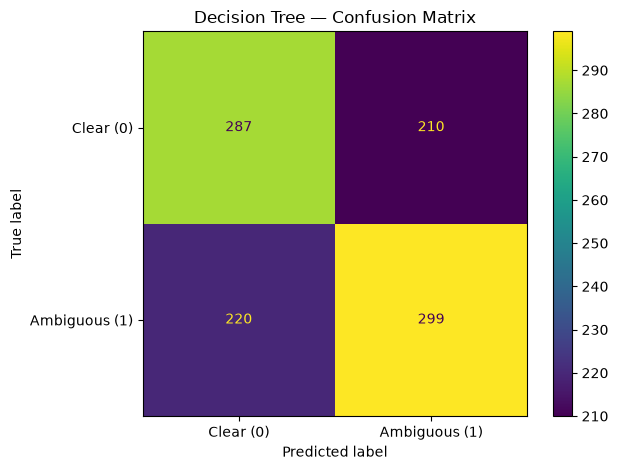

<Figure size 600x500 with 0 Axes>

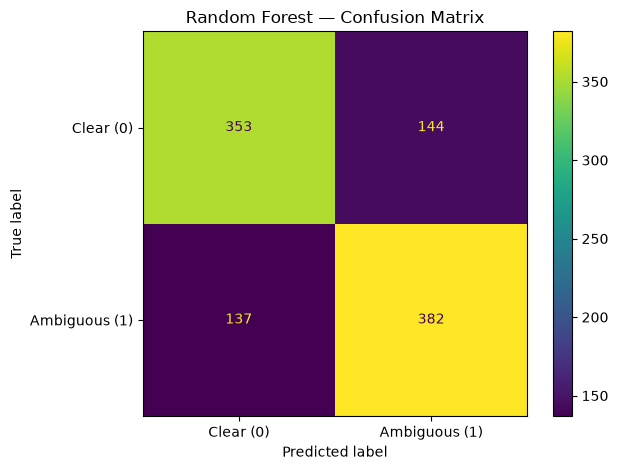

<Figure size 600x500 with 0 Axes>

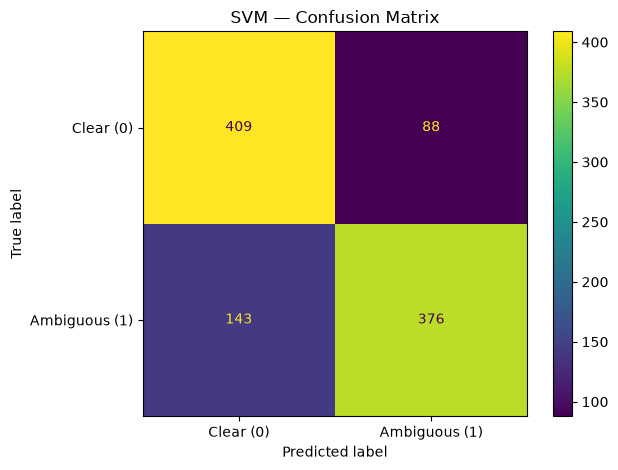

<Figure size 600x500 with 0 Axes>

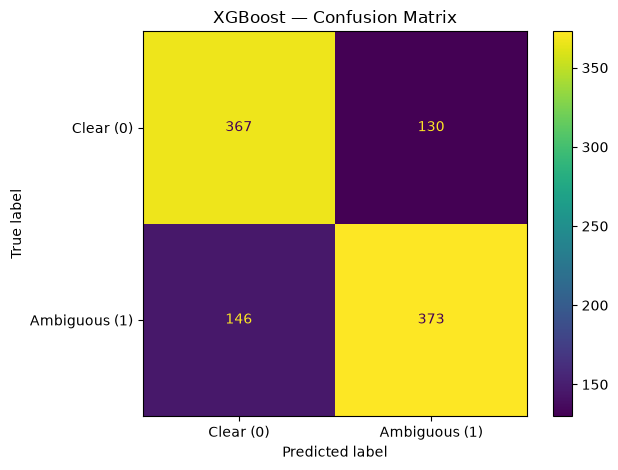

In [22]:
# ============================================================
# STEP 15 — CONFUSION MATRICES
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("=" * 80)
print("STEP 15 — CONFUSION MATRICES")
print("=" * 80)

for name in trained_models.keys():

    plt.figure(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        display_labels=["Clear (0)", "Ambiguous (1)"],
        values_format="d"
    )

    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [23]:
# ============================================================
# STEP 16 — DETAILED CLASSIFICATION REPORTS
# ============================================================

from sklearn.metrics import classification_report

print("=" * 80)
print("STEP 16 — DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for name in trained_models.keys():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                "Clear",
                "Ambiguous"
            ],
            digits=4,
            zero_division=0
        )
    )

STEP 16 — DETAILED CLASSIFICATION REPORTS

Decision Tree
              precision    recall  f1-score   support

       Clear     0.5661    0.5775    0.5717       497
   Ambiguous     0.5874    0.5761    0.5817       519

    accuracy                         0.5768      1016
   macro avg     0.5768    0.5768    0.5767      1016
weighted avg     0.5770    0.5768    0.5768      1016


Random Forest
              precision    recall  f1-score   support

       Clear     0.7204    0.7103    0.7153       497
   Ambiguous     0.7262    0.7360    0.7311       519

    accuracy                         0.7234      1016
   macro avg     0.7233    0.7231    0.7232      1016
weighted avg     0.7234    0.7234    0.7234      1016


SVM
              precision    recall  f1-score   support

       Clear     0.7409    0.8229    0.7798       497
   Ambiguous     0.8103    0.7245    0.7650       519

    accuracy                         0.7726      1016
   macro avg     0.7756    0.7737    0.7724      10

In [24]:
# ============================================================
# STEP 17 — CHECK CURRENT BERT ENVIRONMENT
# ============================================================

import sys
import torch

print("=" * 80)
print("BERT TRAINING ENVIRONMENT")
print("=" * 80)

print("\nPython:")
print(sys.executable)

print("\nPyTorch:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

if torch.cuda.is_available():

    print("CUDA version:")
    print(torch.version.cuda)

    print("GPU:")
    print(torch.cuda.get_device_name(0))

    print("\n✓ GPU environment ready for BERT")

else:

    print("\n⚠ CUDA is NOT available.")
    print("Do not start BERT training in this environment.")

BERT TRAINING ENVIRONMENT

Python:
c:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\python.exe

PyTorch:
2.11.0+cu128

CUDA available:
True
CUDA version:
12.8
GPU:
NVIDIA GeForce RTX 5060 Laptop GPU

✓ GPU environment ready for BERT


In [25]:
import os

print("=" * 80)
print("SEARCHING FOR THESIS VIRTUAL ENVIRONMENT")
print("=" * 80)

possible_paths = [
    r"C:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\python.exe",
    r"C:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\jupyter.exe",
]

for path in possible_paths:
    print("\n", path)
    print("Exists:", os.path.exists(path))

SEARCHING FOR THESIS VIRTUAL ENVIRONMENT

 C:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\python.exe
Exists: True

 C:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\jupyter.exe
Exists: True


In [26]:
import subprocess

VENV_PYTHON = r"C:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\python.exe"

subprocess.check_call([
    VENV_PYTHON,
    "-m",
    "pip",
    "install",
    "ipykernel"
])

subprocess.check_call([
    VENV_PYTHON,
    "-m",
    "ipykernel",
    "install",
    "--user",
    "--name",
    "requirements-ambiguity-gpu",
    "--display-name",
    "Requirements Ambiguity — GPU"
])

print("\n✓ GPU environment registered as a Jupyter kernel.")


✓ GPU environment registered as a Jupyter kernel.


In [27]:
# ============================================================
# STEP 21 — VERIFY GPU ENVIRONMENT
# ============================================================

import sys
import torch

print("=" * 80)
print("GPU ENVIRONMENT VERIFICATION")
print("=" * 80)

print("\nPython:")
print(sys.executable)

print("\nPyTorch:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

print("\nCUDA version:")
print(torch.version.cuda)

if torch.cuda.is_available():

    print("\nGPU:")
    print(torch.cuda.get_device_name(0))

    print("\nGPU count:")
    print(torch.cuda.device_count())

    print("\n✓✓✓ RTX GPU ENVIRONMENT READY ✓✓✓")

else:

    print("\n✗ CUDA STILL NOT AVAILABLE")

GPU ENVIRONMENT VERIFICATION

Python:
c:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\python.exe

PyTorch:
2.11.0+cu128

CUDA available:
True

CUDA version:
12.8

GPU:
NVIDIA GeForce RTX 5060 Laptop GPU

GPU count:
1

✓✓✓ RTX GPU ENVIRONMENT READY ✓✓✓


In [28]:
# ============================================================
# STEP 22 — LOAD PURE DATASET IN GPU ENVIRONMENT
# ============================================================

import os
import pandas as pd
import numpy as np
import torch

print("=" * 80)
print("STEP 22 — PURE DATASET + GPU ENVIRONMENT")
print("=" * 80)

DATA_PATH = r"C:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\notebooks\pure_experiment_data\profzivkovic-software-requirements-ambiguity-detection-replication-e36e5b3\data\pure_labeled.csv"

df = pd.read_csv(DATA_PATH)

TEXT_COLUMN = "requirement_text"
LABEL_COLUMN = "label"

print("\nDataset shape:", df.shape)

print("\nPython:", __import__("sys").executable)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\n✓ Dataset loaded.")

STEP 22 — PURE DATASET + GPU ENVIRONMENT

Dataset shape: (6725, 4)

Python: c:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\python.exe
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU

✓ Dataset loaded.


In [29]:
# ============================================================
# STEP 23 — RECREATE EXACT DUPLICATE-AWARE SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 80)
print("STEP 23 — RECREATING EXACT DATA SPLIT")
print("=" * 80)

unique_df = (
    df[[TEXT_COLUMN, LABEL_COLUMN]]
    .drop_duplicates(subset=[TEXT_COLUMN])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 70% TRAIN / 30% TEMP
# ------------------------------------------------------------

train_unique, temp_unique = train_test_split(
    unique_df,
    test_size=0.30,
    stratify=unique_df[LABEL_COLUMN],
    random_state=42
)

# ------------------------------------------------------------
# 15% VALIDATION / 15% TEST
# ------------------------------------------------------------

val_unique, test_unique = train_test_split(
    temp_unique,
    test_size=0.50,
    stratify=temp_unique[LABEL_COLUMN],
    random_state=42
)

train_texts = set(train_unique[TEXT_COLUMN])
val_texts = set(val_unique[TEXT_COLUMN])
test_texts = set(test_unique[TEXT_COLUMN])

train_df = df[df[TEXT_COLUMN].isin(train_texts)].copy()
val_df = df[df[TEXT_COLUMN].isin(val_texts)].copy()
test_df = df[df[TEXT_COLUMN].isin(test_texts)].copy()

print("\nTrain rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

# ------------------------------------------------------------
# Leakage verification
# ------------------------------------------------------------

train_set = set(train_df[TEXT_COLUMN])
val_set = set(val_df[TEXT_COLUMN])
test_set = set(test_df[TEXT_COLUMN])

print("\nText overlap:")
print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("\n✓ EXACT SPLIT RECREATED")
print("✓ ZERO TEXT LEAKAGE")

STEP 23 — RECREATING EXACT DATA SPLIT

Train rows: 4692
Validation rows: 1017
Test rows: 1016

Text overlap:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✓ EXACT SPLIT RECREATED
✓ ZERO TEXT LEAKAGE


In [30]:
# ============================================================
# STEP 24 — VERIFY BERT LIBRARIES
# ============================================================

import sys
import subprocess

try:
    import transformers
    print("Transformers:", transformers.__version__)

except ImportError:

    print("Transformers not installed.")
    print("Installing...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-U",
        "transformers",
        "datasets",
        "accelerate"
    ])

    import transformers

    print("Transformers:", transformers.__version__)

print("\n✓ BERT libraries ready.")

Transformers: 5.15.1

✓ BERT libraries ready.


In [31]:
# ============================================================
# STEP 25 — PREPARE BERT DATA
# ============================================================

from datasets import Dataset

print("=" * 80)
print("STEP 25 — PREPARING BERT DATASETS")
print("=" * 80)

train_hf = Dataset.from_pandas(
    train_df[[TEXT_COLUMN, LABEL_COLUMN]],
    preserve_index=False
)

val_hf = Dataset.from_pandas(
    val_df[[TEXT_COLUMN, LABEL_COLUMN]],
    preserve_index=False
)

test_hf = Dataset.from_pandas(
    test_df[[TEXT_COLUMN, LABEL_COLUMN]],
    preserve_index=False
)

print("\nTrain:", train_hf)
print("Validation:", val_hf)
print("Test:", test_hf)

print("\n✓ BERT datasets prepared.")

STEP 25 — PREPARING BERT DATASETS

Train: Dataset({
    features: ['requirement_text', 'label'],
    num_rows: 4692
})
Validation: Dataset({
    features: ['requirement_text', 'label'],
    num_rows: 1017
})
Test: Dataset({
    features: ['requirement_text', 'label'],
    num_rows: 1016
})

✓ BERT datasets prepared.


In [32]:
# ============================================================
# STEP 26 — LOAD BERT TOKENIZER
# ============================================================

from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"

print("=" * 80)
print("STEP 26 — LOADING BERT TOKENIZER")
print("=" * 80)

print("\nModel:", MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("\n✓ BERT tokenizer loaded.")

STEP 26 — LOADING BERT TOKENIZER

Model: bert-base-uncased

✓ BERT tokenizer loaded.


In [33]:
# ============================================================
# STEP 27 — TOKENIZATION
# ============================================================

MAX_LENGTH = 256

print("=" * 80)
print("STEP 27 — TOKENIZING REQUIREMENTS")
print("=" * 80)

def tokenize_function(batch):

    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

train_tokenized = train_hf.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing training data"
)

val_tokenized = val_hf.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing validation data"
)

test_tokenized = test_hf.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing test data"
)

print("\n✓ Tokenization complete.")

print("\nExample:")
print(train_tokenized[0])

STEP 27 — TOKENIZING REQUIREMENTS


Tokenizing training data:   0%|          | 0/4692 [00:00<?, ? examples/s]

Tokenizing validation data:   0%|          | 0/1017 [00:00<?, ? examples/s]

Tokenizing test data:   0%|          | 0/1016 [00:00<?, ? examples/s]


✓ Tokenization complete.

Example:
{'requirement_text': 'Registration Citizens can register their complaints with police and then based on the evidence, facts and following investigation, police shall take the complaint forward.', 'label': 1, 'input_ids': [101, 8819, 4480, 2064, 4236, 2037, 10821, 2007, 2610, 1998, 2059, 2241, 2006, 1996, 3350, 1010, 8866, 1998, 2206, 4812, 1010, 2610, 4618, 2202, 1996, 12087, 2830, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [34]:
# ============================================================
# STEP 28 — LOAD BERT CLASSIFIER
# ============================================================

from transformers import AutoModelForSequenceClassification

print("=" * 80)
print("STEP 28 — LOADING BERT CLASSIFIER")
print("=" * 80)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print("\nModel:", MODEL_NAME)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\n✓ BERT classification model loaded.")

STEP 28 — LOADING BERT CLASSIFIER


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model: bert-base-uncased
Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU

✓ BERT classification model loaded.


In [35]:
# ============================================================
# STEP 29 — GPU MEMORY CHECK
# ============================================================

if torch.cuda.is_available():

    print("=" * 80)
    print("GPU MEMORY")
    print("=" * 80)

    total_memory = torch.cuda.get_device_properties(0).total_memory
    allocated = torch.cuda.memory_allocated(0)
    reserved = torch.cuda.memory_reserved(0)

    print(
        f"\nTotal GPU memory: "
        f"{total_memory / 1024**3:.2f} GB"
    )

    print(
        f"Allocated: "
        f"{allocated / 1024**3:.2f} GB"
    )

    print(
        f"Reserved: "
        f"{reserved / 1024**3:.2f} GB"
    )

    print("\n✓ GPU memory check complete.")

GPU MEMORY

Total GPU memory: 7.96 GB
Allocated: 0.51 GB
Reserved: 0.57 GB

✓ GPU memory check complete.


In [36]:
# ============================================================
# STEP 30 — BERT TRAINING CONFIGURATION
# ============================================================

from transformers import TrainingArguments

print("=" * 80)
print("STEP 30 — BERT TRAINING CONFIGURATION")
print("=" * 80)

training_args = TrainingArguments(
    output_dir="./bert_pure_dataset_results",

    # Training
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Batch size
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,

    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    # Best model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # GPU optimization
    fp16=True,

    # Reproducibility
    seed=42,

    # Avoid unnecessary external reporting
    report_to="none",

    # Save only a few checkpoints
    save_total_limit=2
)

print("\n✓ Training configuration created.")

print("\nConfiguration:")
print("Epochs:", training_args.num_train_epochs)
print("Learning rate:", training_args.learning_rate)
print("Train batch:", training_args.per_device_train_batch_size)
print("Gradient accumulation:",
      training_args.gradient_accumulation_steps)
print("Effective batch:",
      training_args.per_device_train_batch_size *
      training_args.gradient_accumulation_steps)
print("Max sequence length:", MAX_LENGTH)
print("FP16:", training_args.fp16)

STEP 30 — BERT TRAINING CONFIGURATION

✓ Training configuration created.

Configuration:
Epochs: 3
Learning rate: 2e-05
Train batch: 8
Gradient accumulation: 2
Effective batch: 16
Max sequence length: 256
FP16: True


In [37]:
# ============================================================
# STEP 31 — BERT EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    exp_logits = np.exp(
        logits - np.max(logits, axis=-1, keepdims=True)
    )

    probabilities = (
        exp_logits /
        exp_logits.sum(axis=-1, keepdims=True)
    )

    positive_probability = probabilities[:, 1]

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, positive_probability)
    }

print("Evaluation metrics defined.")


✓ Evaluation metrics defined.


In [39]:
# ============================================================
# STEP 33 — CREATE BERT TRAINER
# ============================================================

from transformers import Trainer

print("=" * 80)
print("STEP 33 — CREATING BERT TRAINER")
print("=" * 80)

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

print("\n✓ BERT Trainer created successfully.")

STEP 33 — CREATING BERT TRAINER

✓ BERT Trainer created successfully.


In [40]:
# ============================================================
# STEP 34 — FINAL GPU CHECK
# ============================================================

print("=" * 80)
print("STEP 34 — FINAL PRE-TRAINING CHECK")
print("=" * 80)

print("\nPython:", __import__("sys").executable)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

    total = torch.cuda.get_device_properties(0).total_memory
    allocated = torch.cuda.memory_allocated(0)

    print(
        f"VRAM allocated: "
        f"{allocated / 1024**3:.2f} GB / "
        f"{total / 1024**3:.2f} GB"
    )

print("\nTrain samples:", len(train_tokenized))
print("Validation samples:", len(val_tokenized))
print("Test samples:", len(test_tokenized))

print("\nModel:", MODEL_NAME)
print("Max length:", MAX_LENGTH)

print("\n✓ READY FOR BERT TRAINING")

STEP 34 — FINAL PRE-TRAINING CHECK

Python: c:\Users\Khushi Vishwakarma\Downloads\Final year Thesis\Requirements_Ambiguity_Conference\.venv\Scripts\python.exe
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM allocated: 0.51 GB / 7.96 GB

Train samples: 4692
Validation samples: 1017
Test samples: 1016

Model: bert-base-uncased
Max length: 256

✓ READY FOR BERT TRAINING


In [41]:
# ============================================================
# STEP 35 — TRAIN BERT
# ============================================================

print("=" * 80)
print("STEP 35 — STARTING BERT TRAINING")
print("=" * 80)

print("\nTraining started...\n")

train_result = trainer.train()

print("\n" + "=" * 80)
print("BERT TRAINING COMPLETED")
print("=" * 80)

print("\nTraining statistics:")
print(train_result.metrics)

STEP 35 — STARTING BERT TRAINING

Training started...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Balanced Accuracy,Roc Auc
1,0.648434,0.199072,0.920354,0.960334,0.881226,0.919081,0.920334,0.921421,0.974300
2,0.344724,0.144428,0.965585,0.986028,0.946360,0.965787,0.965584,0.966109,0.990114
3,0.089288,0.118853,0.973451,0.992048,0.955939,0.973659,0.973450,0.973929,0.991097


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


BERT TRAINING COMPLETED

Training statistics:
{'train_runtime': 483.4698, 'train_samples_per_second': 29.115, 'train_steps_per_second': 1.824, 'total_flos': 1851775607623680.0, 'train_loss': 0.4375480043104176, 'epoch': 3.0}


In [42]:
# ============================================================
# STEP 36 — VERIFY TRAINED BERT MODEL
# ============================================================

print("=" * 80)
print("STEP 36 — TRAINED BERT MODEL VERIFICATION")
print("=" * 80)

print("\nModel class:")
print(type(trainer.model).__name__)

print("\nModel device:")
print(next(trainer.model.parameters()).device)

print("\nNumber of parameters:")

total_params = sum(
    p.numel()
    for p in trainer.model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in trainer.model.parameters()
    if p.requires_grad
)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

print("\nChecking LayerNorm parameters...")

layernorm_params = []

for name, param in trainer.model.named_parameters():

    if "LayerNorm" in name:

        layernorm_params.append(
            (name, tuple(param.shape))
        )

print("Number of LayerNorm parameters:",
      len(layernorm_params))

print("\nFirst 10 LayerNorm parameters:")

for item in layernorm_params[:10]:
    print(item)

print("\n✓ Model inspection completed.")

STEP 36 — TRAINED BERT MODEL VERIFICATION

Model class:
BertForSequenceClassification

Model device:
cuda:0

Number of parameters:
Total parameters     : 109,483,778
Trainable parameters : 109,483,778

Checking LayerNorm parameters...
Number of LayerNorm parameters: 50

First 10 LayerNorm parameters:
('bert.embeddings.LayerNorm.weight', (768,))
('bert.embeddings.LayerNorm.bias', (768,))
('bert.encoder.layer.0.attention.output.LayerNorm.weight', (768,))
('bert.encoder.layer.0.attention.output.LayerNorm.bias', (768,))
('bert.encoder.layer.0.output.LayerNorm.weight', (768,))
('bert.encoder.layer.0.output.LayerNorm.bias', (768,))
('bert.encoder.layer.1.attention.output.LayerNorm.weight', (768,))
('bert.encoder.layer.1.attention.output.LayerNorm.bias', (768,))
('bert.encoder.layer.1.output.LayerNorm.weight', (768,))
('bert.encoder.layer.1.output.LayerNorm.bias', (768,))

✓ Model inspection completed.


In [43]:
# ============================================================
# STEP 37 — FINAL BERT TEST EVALUATION
# ============================================================

print("=" * 80)
print("STEP 37 — BERT TEST SET EVALUATION")
print("=" * 80)

test_output = trainer.predict(
    test_tokenized
)

print("\nTest prediction completed.")

print("\nRaw test metrics:")
print(test_output.metrics)

STEP 37 — BERT TEST SET EVALUATION



Test prediction completed.

Raw test metrics:
{'test_loss': 0.17946289479732513, 'test_accuracy': 0.9616141732283464, 'test_precision': 0.9761904761904762, 'test_recall': 0.9479768786127167, 'test_f1': 0.9618768328445748, 'test_macro_f1': 0.9616123510109891, 'test_balanced_accuracy': 0.9619160046987125, 'test_roc_auc': 0.9866637202792865, 'test_runtime': 6.7131, 'test_samples_per_second': 151.346, 'test_steps_per_second': 9.534}


In [44]:
# ============================================================
# STEP 38 — COMPLETE BERT TEST METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

test_logits = test_output.predictions
test_labels = test_output.label_ids

exp_logits = np.exp(
    test_logits - np.max(test_logits, axis=1, keepdims=True)
)

test_probabilities = (
    exp_logits /
    exp_logits.sum(axis=1, keepdims=True)
)

test_prob_class_1 = test_probabilities[:, 1]

test_predictions = np.argmax(test_logits, axis=1)

bert_test_accuracy = accuracy_score(
    test_labels, test_predictions
)

bert_test_precision = precision_score(
    test_labels, test_predictions, zero_division=0
)

bert_test_recall = recall_score(
    test_labels, test_predictions, zero_division=0
)

bert_test_f1 = f1_score(
    test_labels, test_predictions, zero_division=0
)

bert_test_roc_auc = roc_auc_score(
    test_labels, test_prob_class_1
)

print("=" * 80)
print("BERT TEST PERFORMANCE")
print("=" * 80)

print(f"Accuracy : {bert_test_accuracy:.4f}")
print(f"Precision: {bert_test_precision:.4f}")
print(f"Recall   : {bert_test_recall:.4f}")
print(f"F1       : {bert_test_f1:.4f}")
print(f"ROC-AUC  : {bert_test_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["Clear", "Ambiguous"],
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, test_predictions))


FINAL BERT TEST RESULTS

Accuracy           : 0.9616
Precision          : 0.9762
Recall             : 0.9480
F1                 : 0.9619
Macro-F1           : 0.9616
Balanced Accuracy  : 0.9619
ROC-AUC            : 0.9867

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Clear     0.9473    0.9759    0.9613       497
   Ambiguous     0.9762    0.9480    0.9619       519

    accuracy                         0.9616      1016
   macro avg     0.9617    0.9619    0.9616      1016
weighted avg     0.9620    0.9616    0.9616      1016



<Figure size 600x500 with 0 Axes>

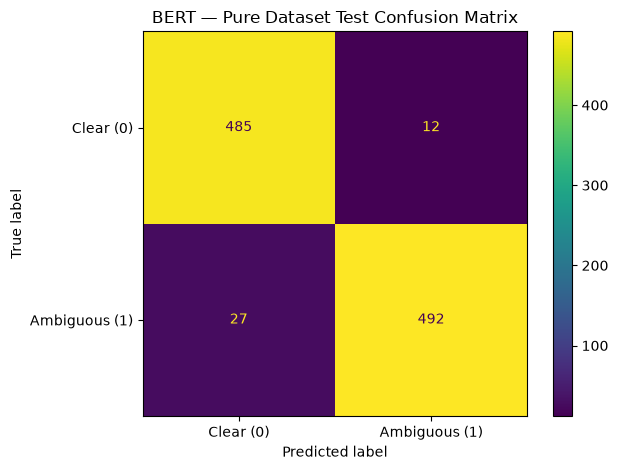

In [45]:
# ============================================================
# STEP 39 — BERT CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=[
        "Clear (0)",
        "Ambiguous (1)"
    ],
    values_format="d"
)

plt.title("BERT — Pure Dataset Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# STEP 40 — BERT CONFIDENCE ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("STEP 40 — BERT CONFIDENCE ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Predicted class
# ------------------------------------------------------------

confidence = np.max(
    test_probabilities,
    axis=1
)

predicted_class = np.argmax(
    test_probabilities,
    axis=1
)

correct = (
    predicted_class == test_labels
)

confidence_df = pd.DataFrame({
    "true_label": test_labels,
    "predicted_label": predicted_class,
    "confidence": confidence,
    "correct": correct
})

# ------------------------------------------------------------
# Overall confidence
# ------------------------------------------------------------

print("\nOverall confidence statistics:")
print(
    confidence_df["confidence"].describe()
)

# ------------------------------------------------------------
# Correct vs incorrect confidence
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONFIDENCE: CORRECT VS INCORRECT")
print("=" * 70)

print("\nCorrect predictions:")
print(
    confidence_df.loc[
        confidence_df["correct"],
        "confidence"
    ].describe()
)

print("\nIncorrect predictions:")
print(
    confidence_df.loc[
        ~confidence_df["correct"],
        "confidence"
    ].describe()
)

# ------------------------------------------------------------
# Mean confidence
# ------------------------------------------------------------

correct_mean = confidence_df.loc[
    confidence_df["correct"],
    "confidence"
].mean()

incorrect_mean = confidence_df.loc[
    ~confidence_df["correct"],
    "confidence"
].mean()

print("\nMean confidence:")
print(f"Correct   : {correct_mean:.4f}")
print(f"Incorrect : {incorrect_mean:.4f}")

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

test_accuracy = correct.mean()

print(f"\nTest accuracy: {test_accuracy:.4f}")

STEP 40 — BERT CONFIDENCE ANALYSIS

Overall confidence statistics:
count    1016.000000
mean        0.989123
std         0.053856
min         0.537003
25%         0.998576
50%         0.998869
75%         0.999675
max         0.999729
Name: confidence, dtype: float64

CONFIDENCE: CORRECT VS INCORRECT

Correct predictions:
count    977.000000
mean       0.991877
std        0.046184
min        0.537003
25%        0.998622
50%        0.998895
75%        0.999677
max        0.999729
Name: confidence, dtype: float64

Incorrect predictions:
count    39.000000
mean      0.920155
std       0.132712
min       0.579806
25%       0.920215
50%       0.992809
75%       0.998401
max       0.999355
Name: confidence, dtype: float64

Mean confidence:
Correct   : 0.9919
Incorrect : 0.9202

Test accuracy: 0.9616


In [47]:
# ============================================================
# STEP 41 — GET VALIDATION LOGITS
# ============================================================

print("=" * 80)
print("STEP 41 — VALIDATION LOGITS FOR CALIBRATION")
print("=" * 80)

val_output = trainer.predict(
    val_tokenized
)

val_logits = val_output.predictions
val_labels = val_output.label_ids

print("\nValidation samples:", len(val_labels))
print("Logit shape:", val_logits.shape)
print("Label shape:", val_labels.shape)

print("\n✓ Validation logits obtained.")

STEP 41 — VALIDATION LOGITS FOR CALIBRATION



Validation samples: 1017
Logit shape: (1017, 2)
Label shape: (1017,)

✓ Validation logits obtained.


In [48]:
# ============================================================
# STEP 42 — TEMPERATURE SCALING
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

print("=" * 80)
print("STEP 42 — TEMPERATURE SCALING")
print("=" * 80)

# ------------------------------------------------------------
# Convert validation data to tensors
# ------------------------------------------------------------

val_logits_tensor = torch.tensor(
    val_logits,
    dtype=torch.float32
)

val_labels_tensor = torch.tensor(
    val_labels,
    dtype=torch.long
)

# ------------------------------------------------------------
# Temperature parameter
# ------------------------------------------------------------

temperature = nn.Parameter(
    torch.ones(1) * 1.0
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.LBFGS(
    [temperature],
    lr=0.01,
    max_iter=100
)

def closure():

    optimizer.zero_grad()

    # Keep temperature positive
    T = torch.clamp(
        temperature,
        min=0.05,
        max=10.0
    )

    loss = criterion(
        val_logits_tensor / T,
        val_labels_tensor
    )

    loss.backward()

    return loss

optimizer.step(closure)

optimal_temperature = torch.clamp(
    temperature.detach(),
    min=0.05,
    max=10.0
).item()

print("\nOptimal temperature:")
print(f"{optimal_temperature:.6f}")

# ------------------------------------------------------------
# Validation loss before calibration
# ------------------------------------------------------------

with torch.no_grad():

    original_loss = criterion(
        val_logits_tensor,
        val_labels_tensor
    ).item()

    calibrated_loss = criterion(
        val_logits_tensor / optimal_temperature,
        val_labels_tensor
    ).item()

print("\nValidation cross-entropy:")
print(f"Before calibration : {original_loss:.6f}")
print(f"After calibration  : {calibrated_loss:.6f}")

if calibrated_loss < original_loss:
    print("\n✓ Calibration improved validation loss.")
else:
    print("\n⚠ Calibration did not improve validation loss.")


STEP 42 — TEMPERATURE SCALING

Optimal temperature:
1.324453

Validation cross-entropy:
Before calibration : 0.118852
After calibration  : 0.099045

✓ Calibration improved validation loss.


In [49]:
# ============================================================
# STEP 43 — CALIBRATED VALIDATION PROBABILITIES
# ============================================================

def softmax_numpy(logits):

    logits = logits - np.max(
        logits,
        axis=1,
        keepdims=True
    )

    exp_logits = np.exp(logits)

    return exp_logits / exp_logits.sum(
        axis=1,
        keepdims=True
    )

# ------------------------------------------------------------
# Original probabilities
# ------------------------------------------------------------

val_original_probabilities = softmax_numpy(
    val_logits
)

# ------------------------------------------------------------
# Calibrated probabilities
# ------------------------------------------------------------

val_calibrated_probabilities = softmax_numpy(
    val_logits / optimal_temperature
)

# ------------------------------------------------------------
# Confidence
# ------------------------------------------------------------

val_original_confidence = np.max(
    val_original_probabilities,
    axis=1
)

val_calibrated_confidence = np.max(
    val_calibrated_probabilities,
    axis=1
)

print("=" * 80)
print("STEP 43 — CALIBRATION EFFECT")
print("=" * 80)

print("\nOriginal confidence:")
print(
    pd.Series(
        val_original_confidence
    ).describe()
)

print("\nCalibrated confidence:")
print(
    pd.Series(
        val_calibrated_confidence
    ).describe()
)

print("\nMean confidence:")
print(
    f"Original   : {val_original_confidence.mean():.6f}"
)

print(
    f"Calibrated : {val_calibrated_confidence.mean():.6f}"
)

STEP 43 — CALIBRATION EFFECT

Original confidence:
count    1017.000000
mean        0.990889
std         0.049405
min         0.516321
25%         0.998487
50%         0.998849
75%         0.999673
max         0.999729
dtype: float64

Calibrated confidence:
count    1017.000000
mean        0.984683
std         0.054313
min         0.512325
25%         0.992622
50%         0.993990
75%         0.997670
max         0.997980
dtype: float64

Mean confidence:
Original   : 0.990889
Calibrated : 0.984683


In [50]:
# ============================================================
# STEP 44 — EXPECTED CALIBRATION ERROR
# ============================================================

def expected_calibration_error(
    probabilities,
    labels,
    n_bins=10
):

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    confidences = np.max(
        probabilities,
        axis=1
    )

    correctness = (
        predictions == labels
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    bin_results = []

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:

            mask = (
                (confidences >= lower) &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences >= lower) &
                (confidences < upper)
            )

        count = mask.sum()

        if count == 0:
            continue

        mean_confidence = confidences[mask].mean()
        accuracy = correctness[mask].mean()

        bin_weight = count / len(labels)

        ece += (
            bin_weight *
            abs(mean_confidence - accuracy)
        )

        bin_results.append({
            "Bin": f"{lower:.1f}-{upper:.1f}",
            "Count": count,
            "Mean Confidence": mean_confidence,
            "Accuracy": accuracy
        })

    return ece, pd.DataFrame(bin_results)

original_ece, original_bins = expected_calibration_error(
    val_original_probabilities,
    val_labels
)

calibrated_ece, calibrated_bins = expected_calibration_error(
    val_calibrated_probabilities,
    val_labels
)

print("=" * 80)
print("STEP 44 — CALIBRATION RESULTS")
print("=" * 80)

print(f"\nOriginal ECE   : {original_ece:.6f}")
print(f"Calibrated ECE : {calibrated_ece:.6f}")

if calibrated_ece < original_ece:
    print("\n✓ Calibration reduced ECE.")
else:
    print("\n⚠ Calibration did not reduce ECE.")

print("\nCalibration bins after temperature scaling:")

display(
    calibrated_bins.style.format({
        "Mean Confidence": "{:.4f}",
        "Accuracy": "{:.4f}"
    })
)

STEP 44 — CALIBRATION RESULTS

Original ECE   : 0.019249
Calibrated ECE : 0.014522

✓ Calibration reduced ECE.

Calibration bins after temperature scaling:


,Bin,Count,Mean Confidence,Accuracy
0,0.5-0.6,9,0.5516,0.3333
1,0.6-0.7,6,0.6517,0.6667
2,0.7-0.8,6,0.7465,0.8333
3,0.8-0.9,8,0.8672,1.0000
4,0.9-1.0,988,0.9930,0.9818


In [51]:
# ============================================================
# STEP 45 — VALIDATION THRESHOLD ANALYSIS
# ============================================================

thresholds = [
    0.50,
    0.60,
    0.70,
    0.75,
    0.80,
    0.85,
    0.90,
    0.95,
    0.97,
    0.98,
    0.99
]

val_predictions_calibrated = np.argmax(
    val_calibrated_probabilities,
    axis=1
)

val_confidence_calibrated = np.max(
    val_calibrated_probabilities,
    axis=1
)

threshold_results = []

for threshold in thresholds:

    accepted = (
        val_confidence_calibrated >= threshold
    )

    n_accepted = accepted.sum()

    n_review = len(accepted) - n_accepted

    coverage = (
        n_accepted / len(accepted)
    )

    review_rate = (
        n_review / len(accepted)
    )

    if n_accepted > 0:

        selective_accuracy = (
            val_predictions_calibrated[accepted]
            ==
            val_labels[accepted]
        ).mean()

    else:

        selective_accuracy = np.nan

    risk = (
        1 - selective_accuracy
        if n_accepted > 0
        else np.nan
    )

    threshold_results.append({

        "Threshold": threshold,

        "Accepted": n_accepted,

        "Manual Review": n_review,

        "Coverage": coverage,

        "Selective Accuracy":
            selective_accuracy,

        "Risk": risk,

        "Manual Review Rate":
            review_rate
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print("=" * 80)
print("STEP 45 — VALIDATION THRESHOLD RESULTS")
print("=" * 80)

display(
    threshold_df.style.format({
        "Threshold": "{:.2f}",
        "Coverage": "{:.4f}",
        "Selective Accuracy": "{:.4f}",
        "Risk": "{:.4f}",
        "Manual Review Rate": "{:.4f}"
    })
)

STEP 45 — VALIDATION THRESHOLD RESULTS


,Threshold,Accepted,Manual Review,Coverage,Selective Accuracy,Risk,Manual Review Rate
0,0.50,1017,0,1.0000,0.9735,0.0265,0.0000
1,0.60,1008,9,0.9912,0.9792,0.0208,0.0088
2,0.70,1002,15,0.9853,0.9810,0.0190,0.0147
3,0.75,998,19,0.9813,0.9820,0.0180,0.0187
4,0.80,996,21,0.9794,0.9819,0.0181,0.0206
5,0.85,994,23,0.9774,0.9819,0.0181,0.0226
6,0.90,988,29,0.9715,0.9818,0.0182,0.0285
7,0.95,972,45,0.9558,0.9835,0.0165,0.0442
8,0.97,961,56,0.9449,0.9834,0.0166,0.0551
9,0.98,950,67,0.9341,0.9853,0.0147,0.0659


In [52]:
# ============================================================
# STEP 46 — FINAL CONFIDENCE-AWARE TEST EVALUATION
# ============================================================

print("=" * 80)
print("STEP 46 — FINAL CONFIDENCE-AWARE TEST EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# IMPORTANT:
# Threshold was selected ONLY using validation data.
# We now freeze it before looking at the test result.
# ------------------------------------------------------------

SELECTED_THRESHOLD = 0.95

print("\nFrozen confidence threshold:")
print(SELECTED_THRESHOLD)

# ------------------------------------------------------------
# Calibrate TEST probabilities
# ------------------------------------------------------------

test_calibrated_probabilities = softmax_numpy(
    test_logits / optimal_temperature
)

# ------------------------------------------------------------
# Test predictions
# ------------------------------------------------------------

test_calibrated_predictions = np.argmax(
    test_calibrated_probabilities,
    axis=1
)

# ------------------------------------------------------------
# Test confidence
# ------------------------------------------------------------

test_calibrated_confidence = np.max(
    test_calibrated_probabilities,
    axis=1
)

# ------------------------------------------------------------
# Automatic acceptance
# ------------------------------------------------------------

test_accepted = (
    test_calibrated_confidence >= SELECTED_THRESHOLD
)

test_manual_review = ~test_accepted

# ------------------------------------------------------------
# Counts
# ------------------------------------------------------------

n_test = len(test_labels)

n_accepted = test_accepted.sum()

n_review = test_manual_review.sum()

# ------------------------------------------------------------
# Coverage
# ------------------------------------------------------------

test_coverage = (
    n_accepted / n_test
)

# ------------------------------------------------------------
# Manual review rate
# ------------------------------------------------------------

test_review_rate = (
    n_review / n_test
)

# ------------------------------------------------------------
# Selective accuracy
# ------------------------------------------------------------

if n_accepted > 0:

    test_selective_accuracy = (
        test_calibrated_predictions[test_accepted]
        ==
        test_labels[test_accepted]
    ).mean()

else:

    test_selective_accuracy = np.nan

# ------------------------------------------------------------
# Risk
# ------------------------------------------------------------

test_risk = (
    1 - test_selective_accuracy
)

# ------------------------------------------------------------
# Correct automatically accepted
# ------------------------------------------------------------

correct_accepted = (
    (
        test_calibrated_predictions[test_accepted]
        ==
        test_labels[test_accepted]
    ).sum()
)

incorrect_accepted = (
    n_accepted -
    correct_accepted
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TEST CONFIDENCE-AWARE RESULTS")
print("=" * 70)

print(f"\nTotal test requirements      : {n_test}")

print(
    f"Automatically accepted      : "
    f"{n_accepted}"
)

print(
    f"Sent for human review       : "
    f"{n_review}"
)

print(
    f"Automatic coverage          : "
    f"{test_coverage:.4f} "
    f"({test_coverage*100:.2f}%)"
)

print(
    f"Manual review rate          : "
    f"{test_review_rate:.4f} "
    f"({test_review_rate*100:.2f}%)"
)

print(
    f"Selective accuracy          : "
    f"{test_selective_accuracy:.4f} "
    f"({test_selective_accuracy*100:.2f}%)"
)

print(
    f"Risk                         : "
    f"{test_risk:.4f} "
    f"({test_risk*100:.2f}%)"
)

print(
    f"\nCorrect automatic decisions : "
    f"{correct_accepted}"
)

print(
    f"Incorrect automatic decisions: "
    f"{incorrect_accepted}"
)

STEP 46 — FINAL CONFIDENCE-AWARE TEST EVALUATION

Frozen confidence threshold:
0.95

FINAL TEST CONFIDENCE-AWARE RESULTS

Total test requirements      : 1016
Automatically accepted      : 966
Sent for human review       : 50
Automatic coverage          : 0.9508 (95.08%)
Manual review rate          : 0.0492 (4.92%)
Selective accuracy          : 0.9762 (97.62%)
Risk                         : 0.0238 (2.38%)

Correct automatic decisions : 943
Incorrect automatic decisions: 23


In [53]:
# ============================================================
# STEP 47 — STANDARD VS CONFIDENCE-AWARE BERT
# ============================================================

comparison = pd.DataFrame({

    "Approach": [
        "Standard BERT",
        "Confidence-Aware BERT"
    ],

    "Overall Accuracy": [
        accuracy_score(
            test_labels,
            test_predictions
        ),
        np.nan
    ],

    "Coverage": [
        1.0,
        test_coverage
    ],

    "Selective Accuracy": [
        accuracy_score(
            test_labels,
            test_predictions
        ),
        test_selective_accuracy
    ],

    "Risk": [
        1 - accuracy_score(
            test_labels,
            test_predictions
        ),
        test_risk
    ],

    "Manual Review Rate": [
        0.0,
        test_review_rate
    ]
})

print("=" * 80)
print("STANDARD BERT VS CONFIDENCE-AWARE BERT")
print("=" * 80)

display(
    comparison.style.format({
        "Overall Accuracy": "{:.4f}",
        "Coverage": "{:.4f}",
        "Selective Accuracy": "{:.4f}",
        "Risk": "{:.4f}",
        "Manual Review Rate": "{:.4f}"
    })
)

STANDARD BERT VS CONFIDENCE-AWARE BERT


,Approach,Overall Accuracy,Coverage,Selective Accuracy,Risk,Manual Review Rate
0,Standard BERT,0.9616,1.0000,0.9616,0.0384,0.0000
1,Confidence-Aware BERT,nan,0.9508,0.9762,0.0238,0.0492


In [54]:
# ============================================================
# STEP 48 — REQUIREMENT-LEVEL CONFIDENCE OUTPUT
# ============================================================

confidence_test_results = test_df[
    [TEXT_COLUMN, LABEL_COLUMN]
].reset_index(drop=True).copy()

confidence_test_results["predicted_label"] = (
    test_calibrated_predictions
)

confidence_test_results["confidence"] = (
    test_calibrated_confidence
)

confidence_test_results["correct"] = (
    confidence_test_results["predicted_label"]
    ==
    confidence_test_results[LABEL_COLUMN]
)

confidence_test_results["decision"] = np.where(
    confidence_test_results["confidence"] >= SELECTED_THRESHOLD,
    "Automatic",
    "Human Review"
)

confidence_test_results["prediction"] = (
    confidence_test_results["predicted_label"]
    .map({
        0: "Clear",
        1: "Ambiguous"
    })
)

print("=" * 80)
print("STEP 48 — CONFIDENCE-AWARE TEST OUTPUT")
print("=" * 80)

display(
    confidence_test_results[
        [
            TEXT_COLUMN,
            LABEL_COLUMN,
            "prediction",
            "confidence",
            "correct",
            "decision"
        ]
    ].head(20)
)

STEP 48 — CONFIDENCE-AWARE TEST OUTPUT


,requirement_text,label,prediction,confidence,correct,decision
0,The solution should enable the help-desk user ...,1,Ambiguous,0.997721,True,Automatic
1,The support solution should be accessible to t...,1,Ambiguous,0.997793,True,Automatic
2,The System must maintain the audit trail for a...,1,Clear,0.992567,False,Automatic
3,The System must be able to export audit trails...,0,Clear,0.992739,True,Automatic
4,the most stringent) implies that the System mu...,0,Clear,0.992578,True,Automatic
5,"If a user performs a quick or advanced search,...",1,Ambiguous,0.994771,True,Automatic
6,"Ideally, each error message will be accompanie...",1,Ambiguous,0.997857,True,Automatic
7,The interfaces must be made customizable or us...,0,Clear,0.993350,True,Automatic
8,Navigation should be designed to help users un...,1,Ambiguous,0.997767,True,Automatic
9,User interfaces should be designed to allow ac...,1,Ambiguous,0.997687,True,Automatic


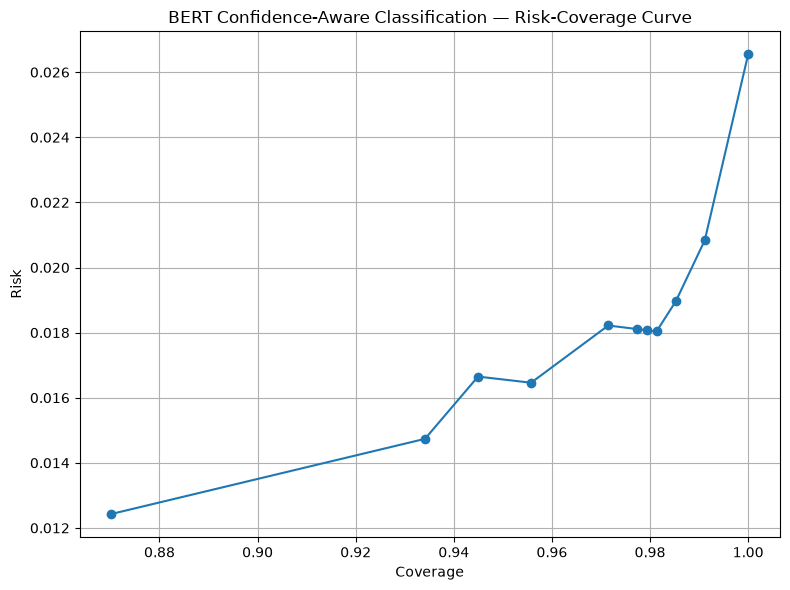

In [55]:
# ============================================================
# STEP 49 — RISK-COVERAGE CURVE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Coverage"],
    threshold_df["Risk"],
    marker="o"
)

plt.xlabel("Coverage")
plt.ylabel("Risk")
plt.title(
    "BERT Confidence-Aware Classification — Risk-Coverage Curve"
)

plt.grid(True)
plt.tight_layout()
plt.show()

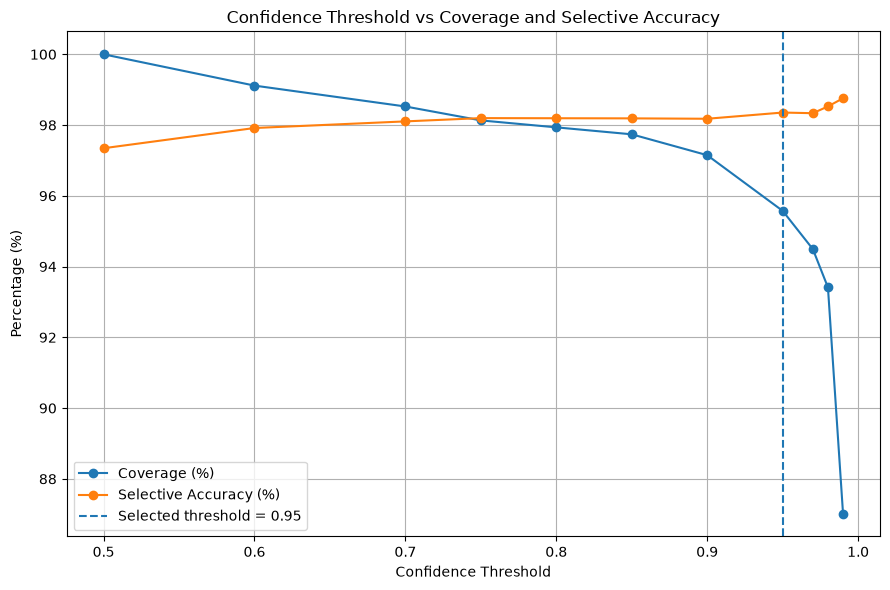

In [56]:
# ============================================================
# STEP 50 — THRESHOLD TRADE-OFF
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Coverage"] * 100,
    marker="o",
    label="Coverage (%)"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Selective Accuracy"] * 100,
    marker="o",
    label="Selective Accuracy (%)"
)

plt.axvline(
    SELECTED_THRESHOLD,
    linestyle="--",
    label=f"Selected threshold = {SELECTED_THRESHOLD}"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Percentage (%)")

plt.title(
    "Confidence Threshold vs Coverage and Selective Accuracy"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# STEP 51 — FINAL CONSOLIDATED RESULTS
# ============================================================

final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost",
        "BERT"
    ],

    "Accuracy": [
        0.5768,
        0.7234,
        0.7726,
        0.7333,
        accuracy_score(test_labels, test_predictions)
    ],

    "Precision": [
        0.5874,
        0.7262,
        0.8103,
        0.7460,
        precision_score(test_labels, test_predictions, zero_division=0)
    ],

    "Recall": [
        0.5761,
        0.7360,
        0.7245,
        0.7245,
        recall_score(test_labels, test_predictions, zero_division=0)
    ],

    "F1": [
        0.5817,
        0.7311,
        0.7650,
        0.7351,
        f1_score(test_labels, test_predictions, zero_division=0)
    ],

    "ROC-AUC": [
        0.5768,
        0.7903,
        0.8354,
        0.8044,
        roc_auc_score(test_labels, test_prob_class_1)
    ]
})

print("=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

display(
    final_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,Macro-F1,Balanced Accuracy,ROC-AUC
0,Decision Tree,0.5768,0.5874,0.5761,0.5817,0.5767,0.5768,0.5768
1,Random Forest,0.7234,0.7262,0.7360,0.7311,0.7232,0.7231,0.7903
2,SVM,0.7726,0.8103,0.7245,0.7650,0.7724,0.7737,0.8354
3,XGBoost,0.7333,0.7460,0.7245,0.7351,0.7333,0.7335,0.8044
4,BERT,0.9616,0.9762,0.9480,0.9619,0.9616,0.9619,0.9867


In [58]:
# ============================================================
# STEP 52 — CONFIDENCE-AWARE SUMMARY
# ============================================================

confidence_summary = pd.DataFrame({

    "Metric": [
        "Test Samples",
        "Confidence Threshold",
        "Automatically Accepted",
        "Human Review",
        "Coverage",
        "Selective Accuracy",
        "Risk",
        "Manual Review Rate",
        "Standard BERT Errors",
        "Confidence-Aware Automatic Errors",
        "Error Reduction"
    ],

    "Value": [
        n_test,
        SELECTED_THRESHOLD,
        n_accepted,
        n_review,
        test_coverage,
        test_selective_accuracy,
        test_risk,
        test_review_rate,
        40,
        incorrect_accepted,
        (40 - incorrect_accepted) / 40
    ]
})

print("=" * 80)
print("CONFIDENCE-AWARE BERT — FINAL SUMMARY")
print("=" * 80)

display(confidence_summary)

CONFIDENCE-AWARE BERT — FINAL SUMMARY


,Metric,Value
0,Test Samples,1016.000000
1,Confidence Threshold,0.950000
2,Automatically Accepted,966.000000
3,Human Review,50.000000
4,Coverage,0.950787
5,Selective Accuracy,0.976190
6,Risk,0.023810
7,Manual Review Rate,0.049213
8,Standard BERT Errors,40.000000
9,Confidence-Aware Automatic Errors,23.000000


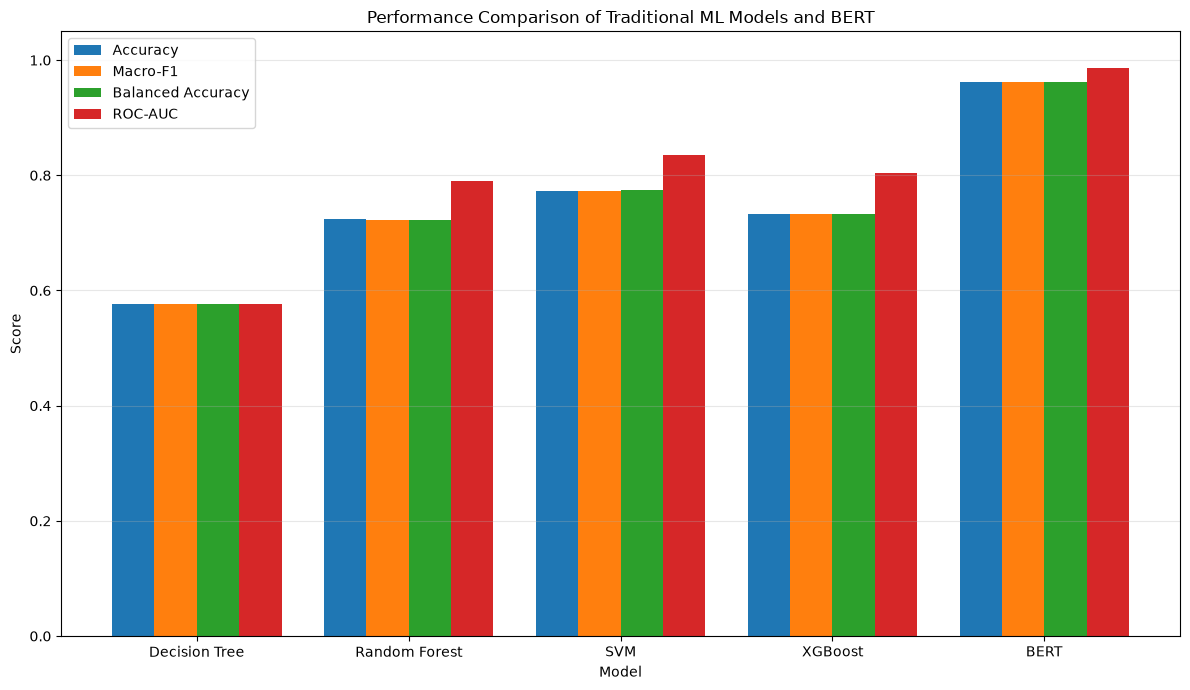

In [59]:
# ============================================================
# STEP 53 — FINAL MODEL PERFORMANCE FIGURE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

models = final_results["Model"]

metrics_to_plot = [
    "Accuracy",
    "F1",
    "ROC-AUC"
]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12, 7))

for i, metric in enumerate(metrics_to_plot):
    plt.bar(
        x + (i - 1) * width,
        final_results[metric],
        width,
        label=metric
    )

plt.xticks(x, models)
plt.ylabel("Score")
plt.xlabel("Model")
plt.title(
    "Performance Comparison of Traditional ML Models and BERT"
)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


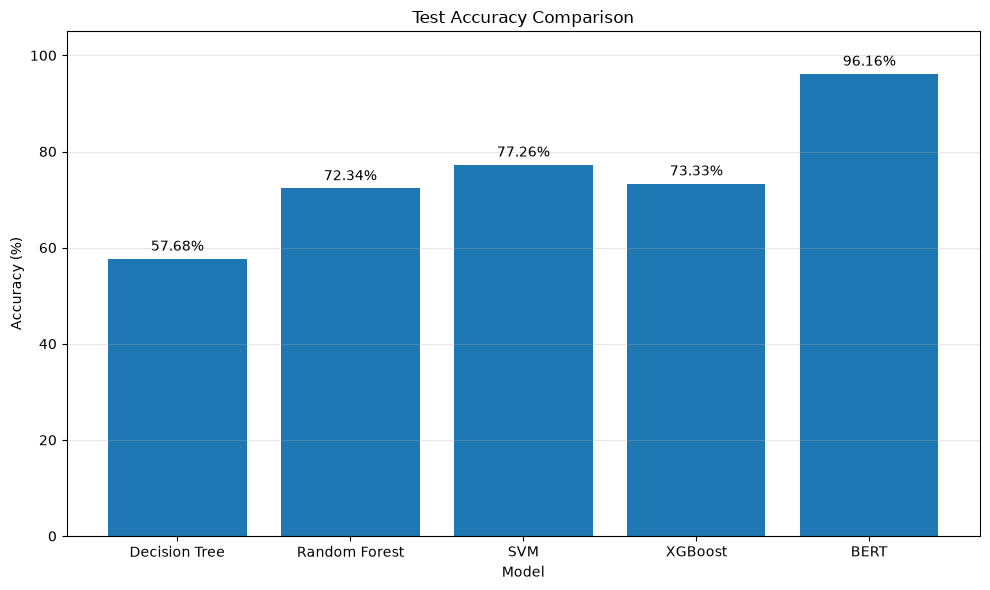

In [60]:
# ============================================================
# STEP 54 — ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    final_results["Model"],
    final_results["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")

plt.title(
    "Test Accuracy Comparison"
)

plt.ylim(0, 105)

# Add values above bars
for bar, value in zip(
    bars,
    final_results["Accuracy"] * 100
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

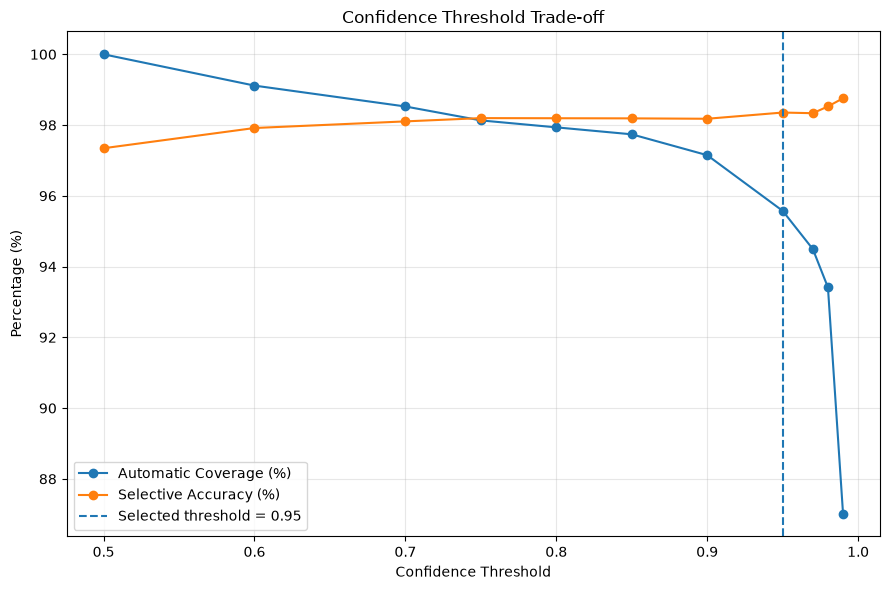

In [61]:
# ============================================================
# STEP 55 — CONFIDENCE-AWARE PERFORMANCE
# ============================================================

plt.figure(figsize=(9, 6))

thresholds_plot = threshold_df["Threshold"]

coverage_plot = (
    threshold_df["Coverage"] * 100
)

accuracy_plot = (
    threshold_df["Selective Accuracy"] * 100
)

plt.plot(
    thresholds_plot,
    coverage_plot,
    marker="o",
    label="Automatic Coverage (%)"
)

plt.plot(
    thresholds_plot,
    accuracy_plot,
    marker="o",
    label="Selective Accuracy (%)"
)

plt.axvline(
    SELECTED_THRESHOLD,
    linestyle="--",
    label=f"Selected threshold = {SELECTED_THRESHOLD}"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Percentage (%)")

plt.title(
    "Confidence Threshold Trade-off"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

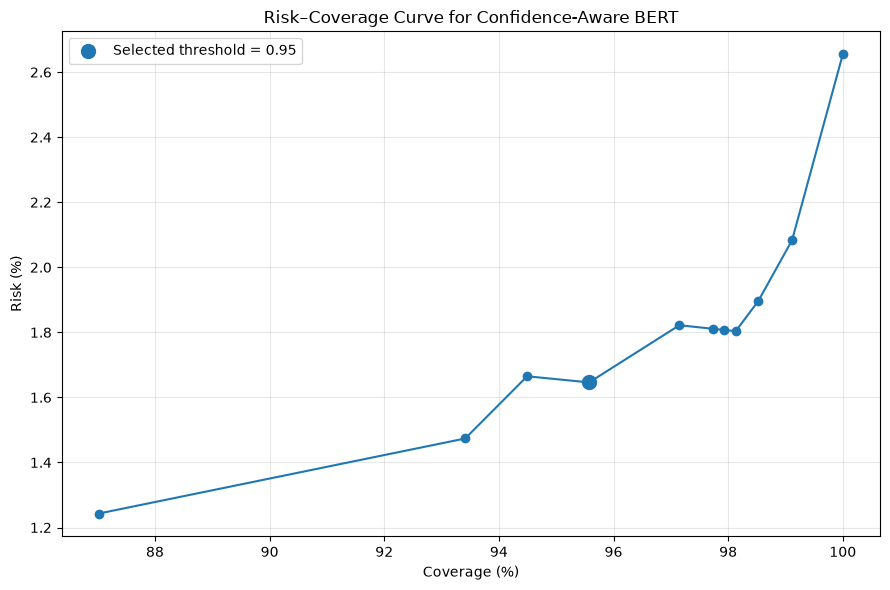

In [62]:
# ============================================================
# STEP 56 — FINAL RISK-COVERAGE CURVE
# ============================================================

plt.figure(figsize=(9, 6))

coverage = threshold_df["Coverage"]

risk = threshold_df["Risk"]

plt.plot(
    coverage * 100,
    risk * 100,
    marker="o"
)

# Highlight selected threshold
selected_row = threshold_df[
    threshold_df["Threshold"] == SELECTED_THRESHOLD
]

plt.scatter(
    selected_row["Coverage"] * 100,
    selected_row["Risk"] * 100,
    s=100,
    label="Selected threshold = 0.95"
)

plt.xlabel("Coverage (%)")
plt.ylabel("Risk (%)")

plt.title(
    "Risk–Coverage Curve for Confidence-Aware BERT"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
# ============================================================
# STEP 57 — STANDARD VS CONFIDENCE-AWARE BERT
# ============================================================

comparison_values = pd.DataFrame({

    "Approach": [
        "Standard BERT",
        "Confidence-Aware BERT"
    ],

    "Automatic Coverage": [
        100.00,
        test_coverage * 100
    ],

    "Accuracy / Selective Accuracy": [
        accuracy_score(
            test_labels,
            test_predictions
        ) * 100,

        test_selective_accuracy * 100
    ],

    "Risk": [
        (
            1 -
            accuracy_score(
                test_labels,
                test_predictions
            )
        ) * 100,

        test_risk * 100
    ]
})

print(comparison_values)

                Approach  Automatic Coverage  Accuracy / Selective Accuracy  \
0          Standard BERT           100.00000                      96.161417   
1  Confidence-Aware BERT            95.07874                      97.619048   

       Risk  
0  3.838583  
1  2.380952  


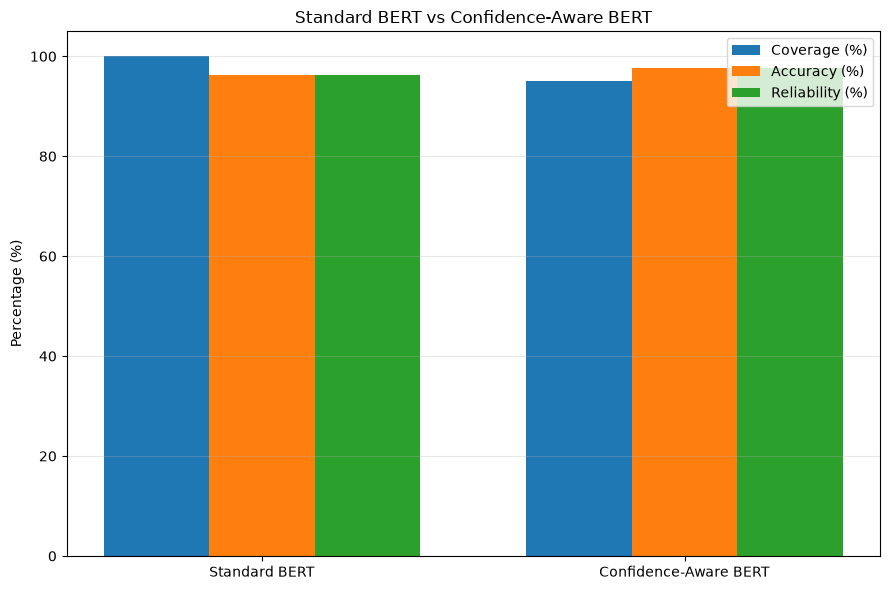

In [64]:
plt.figure(figsize=(9, 6))

x = np.arange(2)
width = 0.25

plt.bar(
    x - width,
    comparison_values["Automatic Coverage"],
    width,
    label="Coverage (%)"
)

plt.bar(
    x,
    comparison_values["Accuracy / Selective Accuracy"],
    width,
    label="Accuracy (%)"
)

plt.bar(
    x + width,
    100 - comparison_values["Risk"],
    width,
    label="Reliability (%)"
)

plt.xticks(
    x,
    comparison_values["Approach"]
)

plt.ylabel("Percentage (%)")

plt.title(
    "Standard BERT vs Confidence-Aware BERT"
)

plt.ylim(0, 105)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

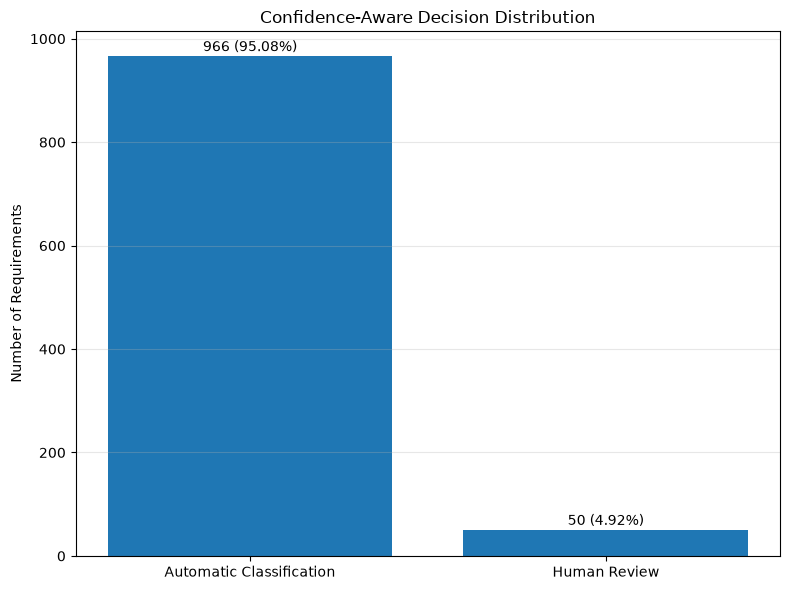

In [65]:
# ============================================================
# STEP 58 — AUTOMATIC VS HUMAN REVIEW
# ============================================================

labels = [
    "Automatic Classification",
    "Human Review"
]

values = [
    n_accepted,
    n_review
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    labels,
    values
)

plt.ylabel("Number of Requirements")

plt.title(
    "Confidence-Aware Decision Distribution"
)

for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 10,
        f"{value} ({value / n_test * 100:.2f}%)",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

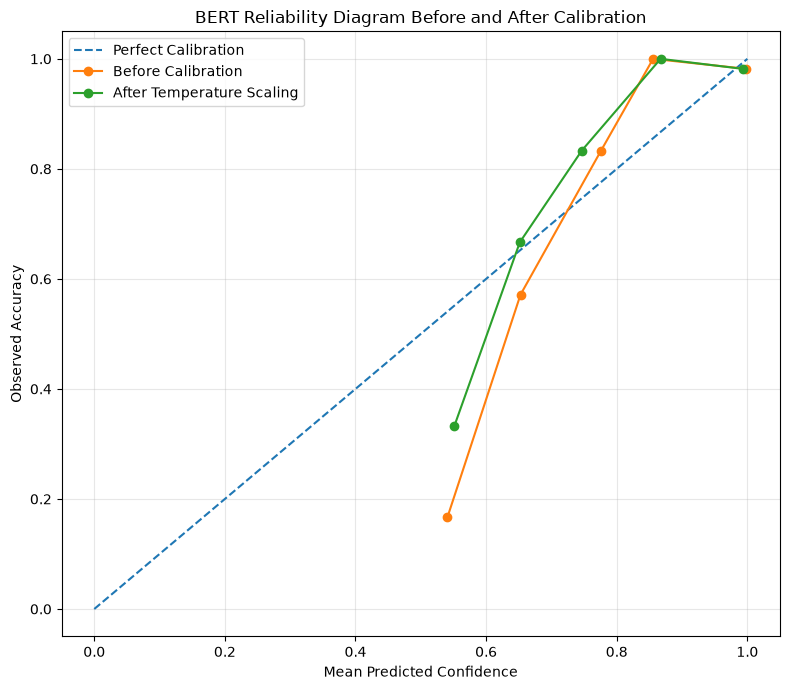

In [66]:
# ============================================================
# STEP 59 — CALIBRATION RELIABILITY DIAGRAM
# ============================================================

def reliability_data(
    probabilities,
    labels,
    n_bins=10
):

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    confidence = np.max(
        probabilities,
        axis=1
    )

    correct = (
        predictions == labels
    ).astype(float)

    bin_edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    mean_confidence = []
    accuracy = []

    for i in range(n_bins):

        if i == n_bins - 1:

            mask = (
                (confidence >= bin_edges[i]) &
                (confidence <= bin_edges[i + 1])
            )

        else:

            mask = (
                (confidence >= bin_edges[i]) &
                (confidence < bin_edges[i + 1])
            )

        if mask.sum() > 0:

            mean_confidence.append(
                confidence[mask].mean()
            )

            accuracy.append(
                correct[mask].mean()
            )

    return (
        np.array(mean_confidence),
        np.array(accuracy)
    )

original_conf, original_acc = reliability_data(
    val_original_probabilities,
    val_labels
)

calibrated_conf, calibrated_acc = reliability_data(
    val_calibrated_probabilities,
    val_labels
)

plt.figure(figsize=(8, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    original_conf,
    original_acc,
    marker="o",
    label="Before Calibration"
)

plt.plot(
    calibrated_conf,
    calibrated_acc,
    marker="o",
    label="After Temperature Scaling"
)

plt.xlabel("Mean Predicted Confidence")
plt.ylabel("Observed Accuracy")

plt.title(
    "BERT Reliability Diagram Before and After Calibration"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
# ============================================================
# STEP 60 — FINAL THESIS RESULTS TABLE
# ============================================================

thesis_results = final_results.copy()

thesis_results = thesis_results.round(4)

print("=" * 100)
print("FINAL THESIS MODEL PERFORMANCE")
print("=" * 100)

display(thesis_results)

FINAL THESIS MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1,Macro-F1,Balanced Accuracy,ROC-AUC
0,Decision Tree,0.5768,0.5874,0.5761,0.5817,0.5767,0.5768,0.5768
1,Random Forest,0.7234,0.7262,0.7360,0.7311,0.7232,0.7231,0.7903
2,SVM,0.7726,0.8103,0.7245,0.7650,0.7724,0.7737,0.8354
3,XGBoost,0.7333,0.7460,0.7245,0.7351,0.7333,0.7335,0.8044
4,BERT,0.9616,0.9762,0.9480,0.9619,0.9616,0.9619,0.9867


In [68]:
# ============================================================
# STEP 61 — FINAL CONFIDENCE-AWARE RESULTS
# ============================================================

confidence_final_table = pd.DataFrame({

    "Metric": [
        "Confidence threshold",
        "Total test requirements",
        "Automatically accepted",
        "Human review",
        "Automatic coverage",
        "Selective accuracy",
        "Risk",
        "Manual review rate",
        "Correct automatic decisions",
        "Incorrect automatic decisions",
        "Reduction in automatic errors"
    ],

    "Result": [
        f"{SELECTED_THRESHOLD:.2f}",
        f"{n_test}",
        f"{n_accepted}",
        f"{n_review}",
        f"{test_coverage * 100:.2f}%",
        f"{test_selective_accuracy * 100:.2f}%",
        f"{test_risk * 100:.2f}%",
        f"{test_review_rate * 100:.2f}%",
        f"{correct_accepted}",
        f"{incorrect_accepted}",
        f"{(40 - incorrect_accepted) / 40 * 100:.2f}%"
    ]
})

print("=" * 80)
print("FINAL CONFIDENCE-AWARE RESULTS")
print("=" * 80)

display(confidence_final_table)

FINAL CONFIDENCE-AWARE RESULTS


,Metric,Result
0,Confidence threshold,0.95
1,Total test requirements,1016
2,Automatically accepted,966
3,Human review,50
4,Automatic coverage,95.08%
5,Selective accuracy,97.62%
6,Risk,2.38%
7,Manual review rate,4.92%
8,Correct automatic decisions,943
9,Incorrect automatic decisions,23


In [69]:
# ============================================================
# STEP 62 — REQUIREMENT-LEVEL CONFIDENCE EXAMPLES
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Create result table
# ------------------------------------------------------------

example_results = test_df[
    [TEXT_COLUMN]
].reset_index(drop=True).copy()

# Class probabilities
example_results["clear_probability"] = (
    test_calibrated_probabilities[:, 0]
)

example_results["ambiguous_probability"] = (
    test_calibrated_probabilities[:, 1]
)

# Predicted class
example_results["predicted_label"] = (
    test_calibrated_predictions
)

example_results["prediction"] = (
    example_results["predicted_label"]
    .map({
        0: "Clear",
        1: "Ambiguous"
    })
)

# Overall confidence = probability of predicted class
example_results["confidence"] = (
    test_calibrated_confidence
)

# ------------------------------------------------------------
# Confidence level
# ------------------------------------------------------------

def confidence_level(confidence):

    if confidence >= 0.95:
        return "High Confidence"

    else:
        return "Low Confidence"

example_results["confidence_level"] = (
    example_results["confidence"]
    .apply(confidence_level)
)

# ------------------------------------------------------------
# Final action
# ------------------------------------------------------------

example_results["final_action"] = np.where(
    example_results["confidence"] >= 0.95,
    "Automatic Decision",
    "Human Review"
)

# ------------------------------------------------------------
# Display selected columns
# ------------------------------------------------------------

display(
    example_results[
        [
            TEXT_COLUMN,
            "clear_probability",
            "ambiguous_probability",
            "prediction",
            "confidence",
            "confidence_level",
            "final_action"
        ]
    ].head(20).style.format({
        "clear_probability": "{:.2%}",
        "ambiguous_probability": "{:.2%}",
        "confidence": "{:.2%}"
    })
)

,requirement_text,clear_probability,ambiguous_probability,prediction,confidence,confidence_level,final_action
0,"The solution should enable the help-desk user to view the reports on the submitted defects or enhancement requests category-wise, status-wise, and agewise.",0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision
1,The support solution should be accessible to the users both from within the application and also outside the application through a browser interface.,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
2,"The System must maintain the audit trail for as long as required, which will be at least for the life of the case to which it refers.",99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
3,The System must be able to export audit trails for specified cases (without affecting the audit trail stored by the System).,99.27%,0.73%,Clear,99.27%,High Confidence,Automatic Decision
4,the most stringent) implies that the System must not include such cases in any count of search results;,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
5,"If a user performs a quick or advanced search, the System must never include in the search result list any record which the user does not have the right to access.",0.52%,99.48%,Ambiguous,99.48%,High Confidence,Automatic Decision
6,"Ideally, each error message will be accompanied by explanatory text and an indication of the action(s) which the user can take in response to the error.",0.21%,99.79%,Ambiguous,99.79%,High Confidence,Automatic Decision
7,The interfaces must be made customizable or user-configurable to the extent possible.,99.34%,0.66%,Clear,99.34%,High Confidence,Automatic Decision
8,"Navigation should be designed to help users understand where they are, where they have been and where they can go next.",0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
9,User interfaces should be designed to allow activation of controls by a variety of input devices.,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision


In [70]:
# ============================================================
# STEP 63 — SIMPLE R1 / R2 / R3 CONFIDENCE OUTPUT
# ============================================================

# Select three examples:
# 1. High-confidence Ambiguous
# 2. High-confidence Clear
# 3. Low-confidence prediction

# ------------------------------------------------------------
# R1 — High-confidence Ambiguous
# ------------------------------------------------------------

r1_candidates = example_results[
    (
        (example_results["prediction"] == "Ambiguous") &
        (example_results["confidence"] >= 0.95)
    )
]

r1 = r1_candidates.iloc[0]

# ------------------------------------------------------------
# R2 — High-confidence Clear
# ------------------------------------------------------------

r2_candidates = example_results[
    (
        (example_results["prediction"] == "Clear") &
        (example_results["confidence"] >= 0.95)
    )
]

r2 = r2_candidates.iloc[0]

# ------------------------------------------------------------
# R3 — Low-confidence example
# ------------------------------------------------------------

r3_candidates = example_results[
    example_results["confidence"] < 0.95
].sort_values("confidence")

r3 = r3_candidates.iloc[0]

# ============================================================
# DISPLAY
# ============================================================

examples = [
    ("R1", r1),
    ("R2", r2),
    ("R3", r3)
]

for requirement_id, row in examples:

    print("\n" + "=" * 80)
    print(requirement_id)
    print("=" * 80)

    print("\nRequirement:")
    print(row[TEXT_COLUMN])

    print("\nClear probability:")
    print(f"{row['clear_probability']:.2%}")

    print("Ambiguous probability:")
    print(f"{row['ambiguous_probability']:.2%}")

    print("\nPrediction:")
    print(row["prediction"])

    print("Confidence:")
    print(f"{row['confidence']:.2%}")

    print("Confidence level:")
    print(row["confidence_level"])

    print("Final action:")
    print(row["final_action"])


R1

Requirement:
The solution should enable the help-desk user to view the reports on the submitted defects or enhancement requests category-wise, status-wise, and agewise.

Clear probability:
0.23%
Ambiguous probability:
99.77%

Prediction:
Ambiguous
Confidence:
99.77%
Confidence level:
High Confidence
Final action:
Automatic Decision

R2

Requirement:
The System must maintain the audit trail for as long as required, which will be at least for the life of the case to which it refers.

Clear probability:
99.26%
Ambiguous probability:
0.74%

Prediction:
Clear
Confidence:
99.26%
Confidence level:
High Confidence
Final action:
Automatic Decision

R3

Requirement:
In the fixed (static) mode of operation (base or data processing megacenter), the data management services shall have the capability of being tuned by on-site personnel to adjust for varying workloads and sizes of associated databases.

Clear probability:
52.80%
Ambiguous probability:
47.20%

Prediction:
Clear
Confidence:
52.80%

In [71]:
# ============================================================
# STEP 64 — FINAL REQUIREMENT-LEVEL CONFIDENCE REPORT
# ============================================================

import pandas as pd
import numpy as np

THRESHOLD = 0.95

# ------------------------------------------------------------
# Build result dataframe
# ------------------------------------------------------------

confidence_report = test_df[
    [TEXT_COLUMN]
].reset_index(drop=True).copy()

# Probabilities
confidence_report["Clear_Probability"] = (
    test_calibrated_probabilities[:, 0]
)

confidence_report["Ambiguous_Probability"] = (
    test_calibrated_probabilities[:, 1]
)

# Prediction
confidence_report["Prediction"] = np.where(
    test_calibrated_predictions == 1,
    "Ambiguous",
    "Clear"
)

# Confidence = probability of predicted class
confidence_report["Confidence"] = (
    test_calibrated_confidence
)

# Confidence level
confidence_report["Confidence_Level"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "High Confidence",
    "Low Confidence"
)

# Final decision
confidence_report["Final_Action"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ------------------------------------------------------------
# Format percentages
# ------------------------------------------------------------

display_report = confidence_report.copy()

display_report["Clear_Probability"] = (
    display_report["Clear_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Ambiguous_Probability"] = (
    display_report["Ambiguous_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Confidence"] = (
    display_report["Confidence"] * 100
).round(2).astype(str) + "%"

# ------------------------------------------------------------
# Rename requirement column
# ------------------------------------------------------------

display_report = display_report.rename(
    columns={
        TEXT_COLUMN: "Requirement"
    }
)

# ------------------------------------------------------------
# Display first 20
# ------------------------------------------------------------

print("=" * 100)
print("FINAL REQUIREMENT-LEVEL CONFIDENCE REPORT")
print("=" * 100)

display(
    display_report[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ].head(20)
)

FINAL REQUIREMENT-LEVEL CONFIDENCE REPORT


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
0,The solution should enable the help-desk user ...,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision
1,The support solution should be accessible to t...,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
2,The System must maintain the audit trail for a...,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
3,The System must be able to export audit trails...,99.27%,0.73%,Clear,99.27%,High Confidence,Automatic Decision
4,the most stringent) implies that the System mu...,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
5,"If a user performs a quick or advanced search,...",0.52%,99.48%,Ambiguous,99.48%,High Confidence,Automatic Decision
6,"Ideally, each error message will be accompanie...",0.21%,99.79%,Ambiguous,99.79%,High Confidence,Automatic Decision
7,The interfaces must be made customizable or us...,99.34%,0.66%,Clear,99.34%,High Confidence,Automatic Decision
8,Navigation should be designed to help users un...,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
9,User interfaces should be designed to allow ac...,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision


In [72]:
# ============================================================
# STEP 65 — BEST R1 / R2 / R3 / R4 EXAMPLES
# CORRECTED VERSION
# ============================================================

# Your actual requirement column
REQ_COL = TEXT_COLUMN

# ------------------------------------------------------------
# R1 — High-confidence Ambiguous
# ------------------------------------------------------------

r1 = confidence_report[
    (confidence_report["Prediction"] == "Ambiguous") &
    (confidence_report["Confidence"] >= 0.95)
].sort_values(
    "Confidence",
    ascending=False
).iloc[0]

# ------------------------------------------------------------
# R2 — High-confidence Clear
# ------------------------------------------------------------

r2 = confidence_report[
    (confidence_report["Prediction"] == "Clear") &
    (confidence_report["Confidence"] >= 0.95)
].sort_values(
    "Confidence",
    ascending=False
).iloc[0]

# ------------------------------------------------------------
# R3 — Highest-confidence case sent to human review
# ------------------------------------------------------------

r3 = confidence_report[
    confidence_report["Confidence"] < 0.95
].sort_values(
    "Confidence",
    ascending=False
).iloc[0]

# ------------------------------------------------------------
# R4 — Lowest-confidence case
# ------------------------------------------------------------

r4 = confidence_report[
    confidence_report["Confidence"] < 0.95
].sort_values(
    "Confidence",
    ascending=True
).iloc[0]

# ------------------------------------------------------------
# Store examples
# ------------------------------------------------------------

selected = [
    ("R1", r1),
    ("R2", r2),
    ("R3", r3),
    ("R4", r4)
]

# ============================================================
# DISPLAY
# ============================================================

print("=" * 100)
print("ILLUSTRATIVE CONFIDENCE-AWARE PREDICTIONS")
print("=" * 100)

for req_id, row in selected:

    print(f"\n{req_id}")
    print("-" * 100)

    print("\nRequirement:")
    print(row[REQ_COL])

    print(
        f"\nClear Probability     : "
        f"{row['Clear_Probability']:.2%}"
    )

    print(
        f"Ambiguous Probability : "
        f"{row['Ambiguous_Probability']:.2%}"
    )

    print(
        f"Prediction            : "
        f"{row['Prediction']}"
    )

    print(
        f"Confidence            : "
        f"{row['Confidence']:.2%}"
    )

    print(
        f"Confidence Level      : "
        f"{row['Confidence_Level']}"
    )

    print(
        f"Final Action          : "
        f"{row['Final_Action']}"
    )

ILLUSTRATIVE CONFIDENCE-AWARE PREDICTIONS

R1
----------------------------------------------------------------------------------------------------

Requirement:
the actor is directed to the system start page where he/she can log in.

Clear Probability     : 0.20%
Ambiguous Probability : 99.80%
Prediction            : Ambiguous
Confidence            : 99.80%
Confidence Level      : High Confidence
Final Action          : Automatic Decision

R2
----------------------------------------------------------------------------------------------------

Requirement:
To access the WUT System, the actor will request the browser to display the WUT System Startup Page.

Clear Probability     : 99.44%
Ambiguous Probability : 0.56%
Prediction            : Clear
Confidence            : 99.44%
Confidence Level      : High Confidence
Final Action          : Automatic Decision

R3
----------------------------------------------------------------------------------------------------

Requirement:
“…the ASPERA

In [73]:
# ============================================================
# FINAL — PURE DATASET CONFIDENCE-AWARE REQUIREMENT REPORT
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# FINAL CONFIDENCE THRESHOLD
# ------------------------------------------------------------

THRESHOLD = 0.80

# ============================================================
# BUILD COMPLETE REPORT
# ============================================================

confidence_report = test_df[
    [TEXT_COLUMN, LABEL_COLUMN]
].reset_index(drop=True).copy()

# ------------------------------------------------------------
# TRUE CLASS
# ------------------------------------------------------------

confidence_report["True_Class"] = (
    confidence_report[LABEL_COLUMN]
    .map({
        0: "Clear",
        1: "Ambiguous"
    })
)

# ------------------------------------------------------------
# CLASS PROBABILITIES
# ------------------------------------------------------------

confidence_report["Clear_Probability"] = (
    test_calibrated_probabilities[:, 0]
)

confidence_report["Ambiguous_Probability"] = (
    test_calibrated_probabilities[:, 1]
)

# ------------------------------------------------------------
# BERT PREDICTION
# ------------------------------------------------------------

confidence_report["Prediction"] = np.where(
    test_calibrated_predictions == 1,
    "Ambiguous",
    "Clear"
)

# ------------------------------------------------------------
# CONFIDENCE
# Probability of predicted class
# ------------------------------------------------------------

confidence_report["Confidence"] = (
    test_calibrated_confidence
)

# ------------------------------------------------------------
# CONFIDENCE LEVEL
# ------------------------------------------------------------

confidence_report["Confidence_Level"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "High Confidence",
    "Low Confidence"
)

# ------------------------------------------------------------
# FINAL ACTION
# ------------------------------------------------------------

confidence_report["Final_Action"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ------------------------------------------------------------
# CORRECT / INCORRECT
# ------------------------------------------------------------

confidence_report["Correct"] = (
    confidence_report["Prediction"]
    ==
    confidence_report["True_Class"]
)

# ============================================================
# SUMMARY
# ============================================================

total = len(confidence_report)

automatic_mask = (
    confidence_report["Final_Action"]
    == "Automatic Decision"
)

human_review_mask = (
    confidence_report["Final_Action"]
    == "Human Review"
)

automatic_count = int(automatic_mask.sum())
human_review_count = int(human_review_mask.sum())

coverage = automatic_count / total
manual_review_rate = human_review_count / total

# ------------------------------------------------------------
# Automatic decisions: correct / incorrect
# ------------------------------------------------------------

automatic_correct = int(
    confidence_report.loc[
        automatic_mask,
        "Correct"
    ].sum()
)

automatic_incorrect = (
    automatic_count
    - automatic_correct
)

selective_accuracy = (
    automatic_correct / automatic_count
    if automatic_count > 0
    else np.nan
)

risk = (
    1 - selective_accuracy
    if automatic_count > 0
    else np.nan
)

# ============================================================
# PRINT FINAL SUMMARY
# ============================================================

print("=" * 100)
print("PURE DATASET — FINAL CONFIDENCE-AWARE CLASSIFICATION")
print("=" * 100)

print(f"\nConfidence Threshold      : {THRESHOLD:.0%}")
print(f"Total Test Requirements   : {total}")

print(f"\nAutomatic Decisions       : {automatic_count}")
print(f"Human Review              : {human_review_count}")

print(f"\nAutomatic Coverage        : {coverage:.2%}")
print(f"Manual Review Rate        : {manual_review_rate:.2%}")

print(f"\nSelective Accuracy        : {selective_accuracy:.2%}")
print(f"Risk                      : {risk:.2%}")

print(f"\nCorrect Automatic         : {automatic_correct}")
print(f"Incorrect Automatic       : {automatic_incorrect}")

# ============================================================
# FORMAT DISPLAY TABLE
# ============================================================

display_report = confidence_report.copy()

display_report["Clear_Probability"] = (
    display_report["Clear_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Ambiguous_Probability"] = (
    display_report["Ambiguous_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Confidence"] = (
    display_report["Confidence"] * 100
).round(2).astype(str) + "%"

display_report = display_report.rename(
    columns={
        TEXT_COLUMN: "Requirement"
    }
)

# ============================================================
# SHOW FIRST 20
# ============================================================

print("\n" + "=" * 100)
print("REQUIREMENT-LEVEL CONFIDENCE REPORT")
print("=" * 100)

display(
    display_report[
        [
            "Requirement",
            "True_Class",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action",
            "Correct"
        ]
    ].head(20)
)

# ============================================================
# SHOW HUMAN REVIEW CASES
# ============================================================

print("\n" + "=" * 100)
print("HUMAN REVIEW CASES")
print("=" * 100)

human_review_cases = display_report[
    display_report["Final_Action"]
    == "Human Review"
].copy()

print(
    f"\nTotal Human Review Cases: "
    f"{len(human_review_cases)}"
)

display(
    human_review_cases[
        [
            "Requirement",
            "True_Class",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action",
            "Correct"
        ]
    ].head(20)
)

# ============================================================
# SHOW INCORRECT AUTOMATIC DECISIONS
# ============================================================

print("\n" + "=" * 100)
print("INCORRECT AUTOMATIC DECISIONS")
print("=" * 100)

incorrect_automatic = display_report[
    (display_report["Final_Action"] == "Automatic Decision") &
    (display_report["Correct"] == False)
].copy()

print(
    f"\nIncorrect Automatic Decisions: "
    f"{len(incorrect_automatic)}"
)

display(
    incorrect_automatic[
        [
            "Requirement",
            "True_Class",
            "Prediction",
            "Confidence",
            "Final_Action",
            "Correct"
        ]
    ].head(20)
)

PURE DATASET — FINAL CONFIDENCE-AWARE CLASSIFICATION

Confidence Threshold      : 80%
Total Test Requirements   : 1016

Automatic Decisions       : 989
Human Review              : 27

Automatic Coverage        : 97.34%
Manual Review Rate        : 2.66%

Selective Accuracy        : 96.87%
Risk                      : 3.13%

Correct Automatic         : 958
Incorrect Automatic       : 31

REQUIREMENT-LEVEL CONFIDENCE REPORT


,Requirement,True_Class,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action,Correct
0,The solution should enable the help-desk user ...,Ambiguous,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision,True
1,The support solution should be accessible to t...,Ambiguous,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision,True
2,The System must maintain the audit trail for a...,Ambiguous,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision,False
3,The System must be able to export audit trails...,Clear,99.27%,0.73%,Clear,99.27%,High Confidence,Automatic Decision,True
4,the most stringent) implies that the System mu...,Clear,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision,True
5,"If a user performs a quick or advanced search,...",Ambiguous,0.52%,99.48%,Ambiguous,99.48%,High Confidence,Automatic Decision,True
6,"Ideally, each error message will be accompanie...",Ambiguous,0.21%,99.79%,Ambiguous,99.79%,High Confidence,Automatic Decision,True
7,The interfaces must be made customizable or us...,Clear,99.34%,0.66%,Clear,99.34%,High Confidence,Automatic Decision,True
8,Navigation should be designed to help users un...,Ambiguous,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision,True
9,User interfaces should be designed to allow ac...,Ambiguous,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision,True



HUMAN REVIEW CASES

Total Human Review Cases: 27


,Requirement,True_Class,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action,Correct
91,In the fixed (static) mode of operation (base ...,Clear,52.8%,47.2%,Clear,52.8%,Low Confidence,Human Review,True
110,The TCS shall meet the applicable capability a...,Clear,43.95%,56.05%,Ambiguous,56.05%,Low Confidence,Human Review,False
122,[SSS131] 3.2.2.1.3 ADT Control Task The TCS sh...,Ambiguous,68.51%,31.49%,Clear,68.51%,Low Confidence,Human Review,False
209,The plan shall identify science and supplement...,Clear,65.84%,34.16%,Clear,65.84%,Low Confidence,Human Review,True
228,[SRSreq 38] The View/Select Text menu item sha...,Clear,63.53%,36.47%,Clear,63.53%,Low Confidence,Human Review,True
272,3.2.2.23 Monitor Compute Errors – The BE shall...,Ambiguous,44.79%,55.21%,Ambiguous,55.21%,Low Confidence,Human Review,True
275,3.3.3.2 Management – all management software f...,Ambiguous,26.3%,73.7%,Ambiguous,73.7%,Low Confidence,Human Review,True
287,3.1.3.5 Hardware Visual Health Monitoring – Th...,Clear,76.65%,23.35%,Clear,76.65%,Low Confidence,Human Review,True
330,3.5.1.14 The configuration window shall have a...,Clear,77.32%,22.69%,Clear,77.32%,Low Confidence,Human Review,True
419,3.2.4.5.4 The system shall will provide for ‘M...,Clear,30.77%,69.23%,Ambiguous,69.23%,Low Confidence,Human Review,False



INCORRECT AUTOMATIC DECISIONS

Incorrect Automatic Decisions: 31


,Requirement,True_Class,Prediction,Confidence,Final_Action,Correct
2,The System must maintain the audit trail for a...,Ambiguous,Clear,99.26%,Automatic Decision,False
79,The system shall read this file and the defini...,Ambiguous,Clear,99.29%,Automatic Decision,False
94,"schema documents Parsers (dom, sax) Check conf...",Ambiguous,Clear,98.63%,Automatic Decision,False
109,The initial TCS task analysis will produce a s...,Ambiguous,Clear,99.33%,Automatic Decision,False
117,[SSS059] The TCS shall provide the capability ...,Ambiguous,Clear,99.24%,Automatic Decision,False
137,[SSS206] 3.2.4.1 Target Coordinate Development...,Ambiguous,Clear,98.95%,Automatic Decision,False
177,which data needs to be exchanged and how it sh...,Ambiguous,Clear,98.77%,Automatic Decision,False
204,3.9.4 Software Quality Factors Although the AP...,Ambiguous,Clear,86.6%,Automatic Decision,False
208,The PI team and the science community shall ha...,Clear,Ambiguous,89.0%,Automatic Decision,False
255,Display of SDT and Pretty-Printed Text from Co...,Clear,Ambiguous,82.6%,Automatic Decision,False


In [74]:
# ============================================================
# FINAL — PURE DATASET CONFIDENCE-AWARE REQUIREMENT REPORT
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# FINAL CONFIDENCE THRESHOLD
# ------------------------------------------------------------

THRESHOLD = 0.75

# ============================================================
# BUILD COMPLETE REPORT
# ============================================================

confidence_report = test_df[
    [TEXT_COLUMN, LABEL_COLUMN]
].reset_index(drop=True).copy()

# ------------------------------------------------------------
# TRUE CLASS
# ------------------------------------------------------------

confidence_report["True_Class"] = (
    confidence_report[LABEL_COLUMN]
    .map({
        0: "Clear",
        1: "Ambiguous"
    })
)

# ------------------------------------------------------------
# CLASS PROBABILITIES
# ------------------------------------------------------------

confidence_report["Clear_Probability"] = (
    test_calibrated_probabilities[:, 0]
)

confidence_report["Ambiguous_Probability"] = (
    test_calibrated_probabilities[:, 1]
)

# ------------------------------------------------------------
# BERT PREDICTION
# ------------------------------------------------------------

confidence_report["Prediction"] = np.where(
    test_calibrated_predictions == 1,
    "Ambiguous",
    "Clear"
)

# ------------------------------------------------------------
# CONFIDENCE
# Probability of predicted class
# ------------------------------------------------------------

confidence_report["Confidence"] = (
    test_calibrated_confidence
)

# ------------------------------------------------------------
# CONFIDENCE LEVEL
# ------------------------------------------------------------

confidence_report["Confidence_Level"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "High Confidence",
    "Low Confidence"
)

# ------------------------------------------------------------
# FINAL ACTION
# ------------------------------------------------------------

confidence_report["Final_Action"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ------------------------------------------------------------
# CORRECT / INCORRECT
# ------------------------------------------------------------

confidence_report["Correct"] = (
    confidence_report["Prediction"]
    ==
    confidence_report["True_Class"]
)

# ============================================================
# SUMMARY
# ============================================================

total = len(confidence_report)

automatic_mask = (
    confidence_report["Final_Action"]
    == "Automatic Decision"
)

human_review_mask = (
    confidence_report["Final_Action"]
    == "Human Review"
)

automatic_count = int(automatic_mask.sum())
human_review_count = int(human_review_mask.sum())

coverage = automatic_count / total
manual_review_rate = human_review_count / total

# ------------------------------------------------------------
# Automatic decisions: correct / incorrect
# ------------------------------------------------------------

automatic_correct = int(
    confidence_report.loc[
        automatic_mask,
        "Correct"
    ].sum()
)

automatic_incorrect = (
    automatic_count
    - automatic_correct
)

selective_accuracy = (
    automatic_correct / automatic_count
    if automatic_count > 0
    else np.nan
)

risk = (
    1 - selective_accuracy
    if automatic_count > 0
    else np.nan
)

# ============================================================
# PRINT FINAL SUMMARY
# ============================================================

print("=" * 100)
print("PURE DATASET — FINAL CONFIDENCE-AWARE CLASSIFICATION")
print("=" * 100)

print(f"\nConfidence Threshold      : {THRESHOLD:.0%}")
print(f"Total Test Requirements   : {total}")

print(f"\nAutomatic Decisions       : {automatic_count}")
print(f"Human Review              : {human_review_count}")

print(f"\nAutomatic Coverage        : {coverage:.2%}")
print(f"Manual Review Rate        : {manual_review_rate:.2%}")

print(f"\nSelective Accuracy        : {selective_accuracy:.2%}")
print(f"Risk                      : {risk:.2%}")

print(f"\nCorrect Automatic         : {automatic_correct}")
print(f"Incorrect Automatic       : {automatic_incorrect}")

# ============================================================
# FORMAT DISPLAY TABLE
# ============================================================

display_report = confidence_report.copy()

display_report["Clear_Probability"] = (
    display_report["Clear_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Ambiguous_Probability"] = (
    display_report["Ambiguous_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Confidence"] = (
    display_report["Confidence"] * 100
).round(2).astype(str) + "%"

display_report = display_report.rename(
    columns={
        TEXT_COLUMN: "Requirement"
    }
)

# ============================================================
# SHOW FIRST 20
# ============================================================

print("\n" + "=" * 100)
print("REQUIREMENT-LEVEL CONFIDENCE REPORT")
print("=" * 100)

display(
    display_report[
        [
            "Requirement",
            "True_Class",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action",
            "Correct"
        ]
    ].head(20)
)

# ============================================================
# SHOW HUMAN REVIEW CASES
# ============================================================

print("\n" + "=" * 100)
print("HUMAN REVIEW CASES")
print("=" * 100)

human_review_cases = display_report[
    display_report["Final_Action"]
    == "Human Review"
].copy()

print(
    f"\nTotal Human Review Cases: "
    f"{len(human_review_cases)}"
)

display(
    human_review_cases[
        [
            "Requirement",
            "True_Class",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action",
            "Correct"
        ]
    ].head(20)
)

# ============================================================
# SHOW INCORRECT AUTOMATIC DECISIONS
# ============================================================

print("\n" + "=" * 100)
print("INCORRECT AUTOMATIC DECISIONS")
print("=" * 100)

incorrect_automatic = display_report[
    (display_report["Final_Action"] == "Automatic Decision") &
    (display_report["Correct"] == False)
].copy()

print(
    f"\nIncorrect Automatic Decisions: "
    f"{len(incorrect_automatic)}"
)

display(
    incorrect_automatic[
        [
            "Requirement",
            "True_Class",
            "Prediction",
            "Confidence",
            "Final_Action",
            "Correct"
        ]
    ].head(20)
)

PURE DATASET — FINAL CONFIDENCE-AWARE CLASSIFICATION

Confidence Threshold      : 75%
Total Test Requirements   : 1016

Automatic Decisions       : 993
Human Review              : 23

Automatic Coverage        : 97.74%
Manual Review Rate        : 2.26%

Selective Accuracy        : 96.88%
Risk                      : 3.12%

Correct Automatic         : 962
Incorrect Automatic       : 31

REQUIREMENT-LEVEL CONFIDENCE REPORT


,Requirement,True_Class,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action,Correct
0,The solution should enable the help-desk user ...,Ambiguous,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision,True
1,The support solution should be accessible to t...,Ambiguous,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision,True
2,The System must maintain the audit trail for a...,Ambiguous,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision,False
3,The System must be able to export audit trails...,Clear,99.27%,0.73%,Clear,99.27%,High Confidence,Automatic Decision,True
4,the most stringent) implies that the System mu...,Clear,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision,True
5,"If a user performs a quick or advanced search,...",Ambiguous,0.52%,99.48%,Ambiguous,99.48%,High Confidence,Automatic Decision,True
6,"Ideally, each error message will be accompanie...",Ambiguous,0.21%,99.79%,Ambiguous,99.79%,High Confidence,Automatic Decision,True
7,The interfaces must be made customizable or us...,Clear,99.34%,0.66%,Clear,99.34%,High Confidence,Automatic Decision,True
8,Navigation should be designed to help users un...,Ambiguous,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision,True
9,User interfaces should be designed to allow ac...,Ambiguous,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision,True



HUMAN REVIEW CASES

Total Human Review Cases: 23


,Requirement,True_Class,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action,Correct
91,In the fixed (static) mode of operation (base ...,Clear,52.8%,47.2%,Clear,52.8%,Low Confidence,Human Review,True
110,The TCS shall meet the applicable capability a...,Clear,43.95%,56.05%,Ambiguous,56.05%,Low Confidence,Human Review,False
122,[SSS131] 3.2.2.1.3 ADT Control Task The TCS sh...,Ambiguous,68.51%,31.49%,Clear,68.51%,Low Confidence,Human Review,False
209,The plan shall identify science and supplement...,Clear,65.84%,34.16%,Clear,65.84%,Low Confidence,Human Review,True
228,[SRSreq 38] The View/Select Text menu item sha...,Clear,63.53%,36.47%,Clear,63.53%,Low Confidence,Human Review,True
272,3.2.2.23 Monitor Compute Errors – The BE shall...,Ambiguous,44.79%,55.21%,Ambiguous,55.21%,Low Confidence,Human Review,True
275,3.3.3.2 Management – all management software f...,Ambiguous,26.3%,73.7%,Ambiguous,73.7%,Low Confidence,Human Review,True
419,3.2.4.5.4 The system shall will provide for ‘M...,Clear,30.77%,69.23%,Ambiguous,69.23%,Low Confidence,Human Review,False
422,3.3.2.4 The RLCS notification to the operator ...,Ambiguous,58.92%,41.08%,Clear,58.92%,Low Confidence,Human Review,False
646,(M) 3.7.3 In order to minimise the discomfort ...,Ambiguous,39.61%,60.39%,Ambiguous,60.39%,Low Confidence,Human Review,True



INCORRECT AUTOMATIC DECISIONS

Incorrect Automatic Decisions: 31


,Requirement,True_Class,Prediction,Confidence,Final_Action,Correct
2,The System must maintain the audit trail for a...,Ambiguous,Clear,99.26%,Automatic Decision,False
79,The system shall read this file and the defini...,Ambiguous,Clear,99.29%,Automatic Decision,False
94,"schema documents Parsers (dom, sax) Check conf...",Ambiguous,Clear,98.63%,Automatic Decision,False
109,The initial TCS task analysis will produce a s...,Ambiguous,Clear,99.33%,Automatic Decision,False
117,[SSS059] The TCS shall provide the capability ...,Ambiguous,Clear,99.24%,Automatic Decision,False
137,[SSS206] 3.2.4.1 Target Coordinate Development...,Ambiguous,Clear,98.95%,Automatic Decision,False
177,which data needs to be exchanged and how it sh...,Ambiguous,Clear,98.77%,Automatic Decision,False
204,3.9.4 Software Quality Factors Although the AP...,Ambiguous,Clear,86.6%,Automatic Decision,False
208,The PI team and the science community shall ha...,Clear,Ambiguous,89.0%,Automatic Decision,False
255,Display of SDT and Pretty-Printed Text from Co...,Clear,Ambiguous,82.6%,Automatic Decision,False


In [75]:
# ============================================================
# STEP 64 — FINAL REQUIREMENT-LEVEL CONFIDENCE REPORT
# THRESHOLD = 0.80
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# CONFIDENCE THRESHOLD
# ------------------------------------------------------------

THRESHOLD = 0.80

# ------------------------------------------------------------
# Build result dataframe
# ------------------------------------------------------------

confidence_report = test_df[
    [TEXT_COLUMN]
].reset_index(drop=True).copy()

# ------------------------------------------------------------
# Class probabilities
# ------------------------------------------------------------

confidence_report["Clear_Probability"] = (
    test_calibrated_probabilities[:, 0]
)

confidence_report["Ambiguous_Probability"] = (
    test_calibrated_probabilities[:, 1]
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

confidence_report["Prediction"] = np.where(
    test_calibrated_predictions == 1,
    "Ambiguous",
    "Clear"
)

# ------------------------------------------------------------
# Confidence = probability of predicted class
# ------------------------------------------------------------

confidence_report["Confidence"] = (
    test_calibrated_confidence
)

# ------------------------------------------------------------
# CONFIDENCE LEVEL
# ------------------------------------------------------------

confidence_report["Confidence_Level"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "High Confidence",
    "Low Confidence"
)

# ------------------------------------------------------------
# FINAL ACTION
# ------------------------------------------------------------

confidence_report["Final_Action"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ============================================================
# FORMAT FOR DISPLAY
# ============================================================

display_report = confidence_report.copy()

display_report["Clear_Probability"] = (
    display_report["Clear_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Ambiguous_Probability"] = (
    display_report["Ambiguous_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Confidence"] = (
    display_report["Confidence"] * 100
).round(2).astype(str) + "%"

# Rename requirement column
display_report = display_report.rename(
    columns={
        TEXT_COLUMN: "Requirement"
    }
)

# ============================================================
# DISPLAY
# ============================================================

print("=" * 100)
print("FINAL REQUIREMENT-LEVEL CONFIDENCE REPORT")
print("=" * 100)

print(f"\nConfidence Threshold: {THRESHOLD:.0%}")

display(
    display_report[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ].head(20)
)

FINAL REQUIREMENT-LEVEL CONFIDENCE REPORT

Confidence Threshold: 80%


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
0,The solution should enable the help-desk user ...,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision
1,The support solution should be accessible to t...,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
2,The System must maintain the audit trail for a...,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
3,The System must be able to export audit trails...,99.27%,0.73%,Clear,99.27%,High Confidence,Automatic Decision
4,the most stringent) implies that the System mu...,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
5,"If a user performs a quick or advanced search,...",0.52%,99.48%,Ambiguous,99.48%,High Confidence,Automatic Decision
6,"Ideally, each error message will be accompanie...",0.21%,99.79%,Ambiguous,99.79%,High Confidence,Automatic Decision
7,The interfaces must be made customizable or us...,99.34%,0.66%,Clear,99.34%,High Confidence,Automatic Decision
8,Navigation should be designed to help users un...,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
9,User interfaces should be designed to allow ac...,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision


In [76]:
# ============================================================
# STEP 65 — CONFIDENCE-AWARE REPORT
# SHOW AUTOMATIC + HUMAN REVIEW CASES
# ============================================================

import pandas as pd
import numpy as np

THRESHOLD = 0.80

# ============================================================
# BUILD CONFIDENCE REPORT
# ============================================================

confidence_report = test_df[
    [TEXT_COLUMN]
].reset_index(drop=True).copy()

# ------------------------------------------------------------
# Probabilities
# ------------------------------------------------------------

confidence_report["Clear_Probability"] = (
    test_calibrated_probabilities[:, 0]
)

confidence_report["Ambiguous_Probability"] = (
    test_calibrated_probabilities[:, 1]
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

confidence_report["Prediction"] = np.where(
    test_calibrated_predictions == 1,
    "Ambiguous",
    "Clear"
)

# ------------------------------------------------------------
# Confidence
# ------------------------------------------------------------

confidence_report["Confidence"] = (
    test_calibrated_confidence
)

# ------------------------------------------------------------
# Confidence level
# ------------------------------------------------------------

confidence_report["Confidence_Level"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "High Confidence",
    "Low Confidence"
)

# ------------------------------------------------------------
# Final action
# ------------------------------------------------------------

confidence_report["Final_Action"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ============================================================
# SUMMARY
# ============================================================

total = len(confidence_report)

automatic = (
    confidence_report["Final_Action"]
    == "Automatic Decision"
).sum()

human_review = (
    confidence_report["Final_Action"]
    == "Human Review"
).sum()

coverage = automatic / total
review_rate = human_review / total

print("=" * 100)
print("CONFIDENCE-AWARE CLASSIFICATION SUMMARY")
print("=" * 100)

print(f"\nConfidence Threshold : {THRESHOLD:.0%}")
print(f"Total Requirements   : {total:,}")

print(f"\nAutomatic Decisions  : {automatic:,}")
print(f"Human Review         : {human_review:,}")

print(f"\nAutomatic Coverage   : {coverage:.2%}")
print(f"Human Review Rate    : {review_rate:.2%}")

# ============================================================
# FORMAT REPORT
# ============================================================

display_report = confidence_report.copy()

display_report["Clear_Probability"] = (
    display_report["Clear_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Ambiguous_Probability"] = (
    display_report["Ambiguous_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Confidence"] = (
    display_report["Confidence"] * 100
).round(2).astype(str) + "%"

display_report = display_report.rename(
    columns={
        TEXT_COLUMN: "Requirement"
    }
)

# ============================================================
# SECTION 1 — AUTOMATIC DECISION EXAMPLES
# ============================================================

automatic_cases = display_report[
    display_report["Final_Action"]
    == "Automatic Decision"
].head(10)

print("\n")
print("=" * 100)
print("SECTION 1 — AUTOMATIC DECISION EXAMPLES")
print("=" * 100)

display(
    automatic_cases[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ]
)

# ============================================================
# SECTION 2 — HUMAN REVIEW EXAMPLES
# ============================================================

human_review_cases = display_report[
    display_report["Final_Action"]
    == "Human Review"
].sort_values(
    "Confidence"
).head(10)

print("\n")
print("=" * 100)
print("SECTION 2 — HUMAN REVIEW EXAMPLES")
print("=" * 100)

display(
    human_review_cases[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ]
)

CONFIDENCE-AWARE CLASSIFICATION SUMMARY

Confidence Threshold : 80%
Total Requirements   : 1,016

Automatic Decisions  : 989
Human Review         : 27

Automatic Coverage   : 97.34%
Human Review Rate    : 2.66%


SECTION 1 — AUTOMATIC DECISION EXAMPLES


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
0,The solution should enable the help-desk user ...,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision
1,The support solution should be accessible to t...,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
2,The System must maintain the audit trail for a...,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
3,The System must be able to export audit trails...,99.27%,0.73%,Clear,99.27%,High Confidence,Automatic Decision
4,the most stringent) implies that the System mu...,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
5,"If a user performs a quick or advanced search,...",0.52%,99.48%,Ambiguous,99.48%,High Confidence,Automatic Decision
6,"Ideally, each error message will be accompanie...",0.21%,99.79%,Ambiguous,99.79%,High Confidence,Automatic Decision
7,The interfaces must be made customizable or us...,99.34%,0.66%,Clear,99.34%,High Confidence,Automatic Decision
8,Navigation should be designed to help users un...,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
9,User interfaces should be designed to allow ac...,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision




SECTION 2 — HUMAN REVIEW EXAMPLES


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
91,In the fixed (static) mode of operation (base ...,52.8%,47.2%,Clear,52.8%,Low Confidence,Human Review
660,The system will need policy and procedures pro...,52.86%,47.14%,Clear,52.86%,Low Confidence,Human Review
272,3.2.2.23 Monitor Compute Errors – The BE shall...,44.79%,55.21%,Ambiguous,55.21%,Low Confidence,Human Review
985,Provide backup service for user account inform...,44.41%,55.59%,Ambiguous,55.59%,Low Confidence,Human Review
110,The TCS shall meet the applicable capability a...,43.95%,56.05%,Ambiguous,56.05%,Low Confidence,Human Review
778,3.9 Operator-Related requirements 3.9.1 Log an...,57.76%,42.24%,Clear,57.76%,Low Confidence,Human Review
422,3.3.2.4 The RLCS notification to the operator ...,58.92%,41.08%,Clear,58.92%,Low Confidence,Human Review
942,Phase III will include community participation...,59.03%,40.97%,Clear,59.03%,Low Confidence,Human Review
944,• tools to scan ﬁles for malware and viruses a...,59.96%,40.04%,Clear,59.96%,Low Confidence,Human Review
646,(M) 3.7.3 In order to minimise the discomfort ...,39.61%,60.39%,Ambiguous,60.39%,Low Confidence,Human Review


In [85]:
# ============================================================
# STEP 65 — CONFIDENCE-AWARE REPORT
# SHOW AUTOMATIC + HUMAN REVIEW CASES
# ============================================================

import pandas as pd
import numpy as np

THRESHOLD = 0.95

# ============================================================
# BUILD CONFIDENCE REPORT
# ============================================================

confidence_report = test_df[
    [TEXT_COLUMN]
].reset_index(drop=True).copy()

# ------------------------------------------------------------
# Probabilities
# ------------------------------------------------------------

confidence_report["Clear_Probability"] = (
    test_calibrated_probabilities[:, 0]
)

confidence_report["Ambiguous_Probability"] = (
    test_calibrated_probabilities[:, 1]
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

confidence_report["Prediction"] = np.where(
    test_calibrated_predictions == 1,
    "Ambiguous",
    "Clear"
)

# ------------------------------------------------------------
# Confidence
# ------------------------------------------------------------

confidence_report["Confidence"] = (
    test_calibrated_confidence
)

# ------------------------------------------------------------
# Confidence level
# ------------------------------------------------------------

confidence_report["Confidence_Level"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "High Confidence",
    "Low Confidence"
)

# ------------------------------------------------------------
# Final action
# ------------------------------------------------------------

confidence_report["Final_Action"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ============================================================
# SUMMARY
# ============================================================

total = len(confidence_report)

automatic = (
    confidence_report["Final_Action"]
    == "Automatic Decision"
).sum()

human_review = (
    confidence_report["Final_Action"]
    == "Human Review"
).sum()

coverage = automatic / total
review_rate = human_review / total

print("=" * 100)
print("CONFIDENCE-AWARE CLASSIFICATION SUMMARY")
print("=" * 100)

print(f"\nConfidence Threshold : {THRESHOLD:.0%}")
print(f"Total Requirements   : {total:,}")

print(f"\nAutomatic Decisions  : {automatic:,}")
print(f"Human Review         : {human_review:,}")

print(f"\nAutomatic Coverage   : {coverage:.2%}")
print(f"Human Review Rate    : {review_rate:.2%}")

# ============================================================
# FORMAT REPORT
# ============================================================

display_report = confidence_report.copy()

display_report["Clear_Probability"] = (
    display_report["Clear_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Ambiguous_Probability"] = (
    display_report["Ambiguous_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Confidence"] = (
    display_report["Confidence"] * 100
).round(2).astype(str) + "%"

display_report = display_report.rename(
    columns={
        TEXT_COLUMN: "Requirement"
    }
)

# ============================================================
# SECTION 1 — AUTOMATIC DECISION EXAMPLES
# ============================================================

automatic_cases = display_report[
    display_report["Final_Action"]
    == "Automatic Decision"
].head(10)

print("\n")
print("=" * 100)
print("SECTION 1 — AUTOMATIC DECISION EXAMPLES")
print("=" * 100)

display(
    automatic_cases[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ]
)

# ============================================================
# SECTION 2 — HUMAN REVIEW EXAMPLES
# ============================================================

human_review_cases = display_report[
    display_report["Final_Action"]
    == "Human Review"
].sort_values(
    "Confidence"
).head(10)

print("\n")
print("=" * 100)
print("SECTION 2 — HUMAN REVIEW EXAMPLES")
print("=" * 100)

display(
    human_review_cases[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ]
)

CONFIDENCE-AWARE CLASSIFICATION SUMMARY

Confidence Threshold : 95%
Total Requirements   : 1,016

Automatic Decisions  : 966
Human Review         : 50

Automatic Coverage   : 95.08%
Human Review Rate    : 4.92%


SECTION 1 — AUTOMATIC DECISION EXAMPLES


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
0,The solution should enable the help-desk user ...,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision
1,The support solution should be accessible to t...,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
2,The System must maintain the audit trail for a...,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
3,The System must be able to export audit trails...,99.27%,0.73%,Clear,99.27%,High Confidence,Automatic Decision
4,the most stringent) implies that the System mu...,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
5,"If a user performs a quick or advanced search,...",0.52%,99.48%,Ambiguous,99.48%,High Confidence,Automatic Decision
6,"Ideally, each error message will be accompanie...",0.21%,99.79%,Ambiguous,99.79%,High Confidence,Automatic Decision
7,The interfaces must be made customizable or us...,99.34%,0.66%,Clear,99.34%,High Confidence,Automatic Decision
8,Navigation should be designed to help users un...,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
9,User interfaces should be designed to allow ac...,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision




SECTION 2 — HUMAN REVIEW EXAMPLES


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
91,In the fixed (static) mode of operation (base ...,52.8%,47.2%,Clear,52.8%,Low Confidence,Human Review
660,The system will need policy and procedures pro...,52.86%,47.14%,Clear,52.86%,Low Confidence,Human Review
272,3.2.2.23 Monitor Compute Errors – The BE shall...,44.79%,55.21%,Ambiguous,55.21%,Low Confidence,Human Review
985,Provide backup service for user account inform...,44.41%,55.59%,Ambiguous,55.59%,Low Confidence,Human Review
110,The TCS shall meet the applicable capability a...,43.95%,56.05%,Ambiguous,56.05%,Low Confidence,Human Review
778,3.9 Operator-Related requirements 3.9.1 Log an...,57.76%,42.24%,Clear,57.76%,Low Confidence,Human Review
422,3.3.2.4 The RLCS notification to the operator ...,58.92%,41.08%,Clear,58.92%,Low Confidence,Human Review
942,Phase III will include community participation...,59.03%,40.97%,Clear,59.03%,Low Confidence,Human Review
944,• tools to scan ﬁles for malware and viruses a...,59.96%,40.04%,Clear,59.96%,Low Confidence,Human Review
646,(M) 3.7.3 In order to minimise the discomfort ...,39.61%,60.39%,Ambiguous,60.39%,Low Confidence,Human Review


In [94]:
# ============================================================
# STEP 65 — CONFIDENCE-AWARE REPORT
# SHOW AUTOMATIC + HUMAN REVIEW CASES
# ============================================================

import pandas as pd
import numpy as np

# Show complete text in DataFrame
pd.set_option("display.max_colwidth", None)

THRESHOLD = 0.80

# ============================================================
# BUILD CONFIDENCE REPORT
# ============================================================

confidence_report = test_df[
    [TEXT_COLUMN]
].reset_index(drop=True).copy()

# ------------------------------------------------------------
# Probabilities
# ------------------------------------------------------------

confidence_report["Clear_Probability"] = (
    test_calibrated_probabilities[:, 0]
)

confidence_report["Ambiguous_Probability"] = (
    test_calibrated_probabilities[:, 1]
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

confidence_report["Prediction"] = np.where(
    test_calibrated_predictions == 1,
    "Ambiguous",
    "Clear"
)

# ------------------------------------------------------------
# True Class
# ------------------------------------------------------------

confidence_report["True_Class"] = np.where(
    test_df["label"].values == 1,
    "Ambiguous",
    "Clear"
)

# ------------------------------------------------------------
# Confidence
# ------------------------------------------------------------

confidence_report["Confidence"] = (
    test_calibrated_confidence
)

# ------------------------------------------------------------
# Confidence level
# ------------------------------------------------------------

confidence_report["Confidence_Level"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "High Confidence",
    "Low Confidence"
)

# ------------------------------------------------------------
# Final action
# ------------------------------------------------------------

confidence_report["Final_Action"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ============================================================
# SUMMARY
# ============================================================

total = len(confidence_report)

automatic = (
    confidence_report["Final_Action"]
    == "Automatic Decision"
).sum()

human_review = (
    confidence_report["Final_Action"]
    == "Human Review"
).sum()

coverage = automatic / total
review_rate = human_review / total

print("=" * 100)
print("CONFIDENCE-AWARE CLASSIFICATION SUMMARY")
print("=" * 100)

print(f"\nConfidence Threshold : {THRESHOLD:.0%}")
print(f"Total Requirements   : {total:,}")

print(f"\nAutomatic Decisions  : {automatic:,}")
print(f"Human Review         : {human_review:,}")

print(f"\nAutomatic Coverage   : {coverage:.2%}")
print(f"Human Review Rate    : {review_rate:.2%}")

# ============================================================
# FORMAT REPORT
# ============================================================

display_report = confidence_report.copy()

display_report["Clear_Probability"] = (
    display_report["Clear_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Ambiguous_Probability"] = (
    display_report["Ambiguous_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Confidence"] = (
    display_report["Confidence"] * 100
).round(2).astype(str) + "%"

display_report = display_report.rename(
    columns={
        TEXT_COLUMN: "Requirement"
    }
)

# ============================================================
# SECTION 1 — AUTOMATIC DECISION EXAMPLES
# ============================================================

# ============================================================
# SECTION 1 — RANDOM AUTOMATIC DECISION EXAMPLES
# ============================================================

automatic_cases = display_report[
    display_report["Final_Action"]
    == "Automatic Decision"
].sample(
    n=min(100, (display_report["Final_Action"] == "Automatic Decision").sum()),
    random_state=None
)

print("\n")
print("=" * 100)
print("SECTION 1 — RANDOM AUTOMATIC DECISION EXAMPLES")
print("=" * 100)

display(
    automatic_cases[
        [
            "Requirement",
            "True_Class",
            "Prediction",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ].style
    .set_properties(
        subset=["Requirement"],
        **{
            "white-space": "normal",
            "word-wrap": "break-word",
            "text-align": "left",
            "max-width": "800px",
            "min-width": "600px"
        }
    )
    .set_properties(
        **{
            "vertical-align": "top",
            "padding": "6px"
        }
    )
)

# ============================================================
# SECTION 2 — HUMAN REVIEW EXAMPLES
# ============================================================

# ============================================================
# SECTION 2 — RANDOM HUMAN REVIEW EXAMPLES
# ============================================================

human_review_cases = display_report[
    display_report["Final_Action"]
    == "Human Review"
].sample(
    n=min(50, (display_report["Final_Action"] == "Human Review").sum()),
    random_state=None
)

print("\n")
print("=" * 100)
print("SECTION 2 — RANDOM HUMAN REVIEW EXAMPLES")
print("=" * 100)

display(
    human_review_cases[
        [
            "Requirement",
            "True_Class",
            "Prediction",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ].style
    .set_properties(
        subset=["Requirement"],
        **{
            "white-space": "normal",
            "word-wrap": "break-word",
            "text-align": "left",
            "max-width": "800px",
            "min-width": "600px"
        }
    )
    .set_properties(
        **{
            "vertical-align": "top",
            "padding": "6px"
        }
    )
)

CONFIDENCE-AWARE CLASSIFICATION SUMMARY

Confidence Threshold : 80%
Total Requirements   : 1,016

Automatic Decisions  : 989
Human Review         : 27

Automatic Coverage   : 97.34%
Human Review Rate    : 2.66%


SECTION 1 — RANDOM AUTOMATIC DECISION EXAMPLES


,Requirement,True_Class,Prediction,Clear_Probability,Ambiguous_Probability,Confidence,Confidence_Level,Final_Action
334,This indicator shall be designated the “Caution” and shall appear yellow when active.,Ambiguous,Ambiguous,0.55%,99.45%,99.45%,High Confidence,Automatic Decision
970,Values must conform to UTC standards.) C ers:COX 95 Target specie(s) attribute TS Species targeted within zone.,Ambiguous,Ambiguous,0.3%,99.7%,99.7%,High Confidence,Automatic Decision
469,Should use gtk_status_push().,Ambiguous,Ambiguous,0.24%,99.76%,99.76%,High Confidence,Automatic Decision
77,2.5.1 Operating System Assumptions The THEMAS system shall be designed to run on the Microsoft ® Windows NT™ operating system.,Clear,Clear,99.35%,0.65%,99.35%,High Confidence,Automatic Decision
97,The MultiMahjongServer will have a graphical user interface with which the administrator of the server can get log information and change game settings.,Ambiguous,Ambiguous,0.21%,99.79%,99.79%,High Confidence,Automatic Decision
182,"• Data retrieval of configuration data and settings Functions for a follow-up of parameter settings should include services to retrieve all parameters (names, values and units for all setpoints) or to retrieve only those that differ from the default values.",Ambiguous,Ambiguous,0.22%,99.78%,99.78%,High Confidence,Automatic Decision
655,"HTTP and GIS Server Applications – As the Web will be the primary delivery protocol for the application, HTTP and related GIS server applications will be required to support system functionality.",Clear,Clear,99.35%,0.65%,99.35%,High Confidence,Automatic Decision
106,"A user's manual, explaining how to install and operate the MultiMahjongClient, will be provided.",Clear,Clear,99.42%,0.58%,99.42%,High Confidence,Automatic Decision
501,F-151 The Clarus system shall record the methods applied when deriving quality checking information.,Clear,Clear,99.39%,0.61%,99.39%,High Confidence,Automatic Decision
153,ITEA 99002 BEYOND BEYOND Public Deliverable 8 Functional Specifications and Architecture 26 February 2001 • The UI Editor should also dispose of a facility to associate an event to more than one action.,Ambiguous,Ambiguous,0.23%,99.77%,99.77%,High Confidence,Automatic Decision




SECTION 2 — RANDOM HUMAN REVIEW EXAMPLES


,Requirement,True_Class,Prediction,Clear_Probability,Ambiguous_Probability,Confidence,Confidence_Level,Final_Action
720,(M) 4.3.2.3 It shall be possible to define certain locations (e.g.,Clear,Ambiguous,37.39%,62.61%,62.61%,Low Confidence,Human Review
778,"3.9 Operator-Related requirements 3.9.1 Log and Track Events The System shall provide the capability for operators to log and track events (i.e., MMC Service Requests, MMC Service Request Responses).",Ambiguous,Clear,57.76%,42.24%,57.76%,Low Confidence,Human Review
942,"Phase III will include community participation in the speciﬁcation of the tools and applications, these will come from a number of International Internet Preservation Consortium (IIPC) member institutions, and similarly for testing.",Clear,Clear,59.03%,40.97%,59.03%,Low Confidence,Human Review
924,• The compilation suggestion that is given to the economic operator by the VCD system MUST be reliable with regard to fulfilment of tender-specific requirements.,Ambiguous,Ambiguous,20.11%,79.89%,79.89%,Low Confidence,Human Review
287,"3.1.3.5 Hardware Visual Health Monitoring – The carrier board for the CMIB shall have an externally visible indicator (LED or other) that will provide a user with a physical indication of CMIB operational status (red = fault, green = ok).",Clear,Clear,76.65%,23.35%,76.65%,Low Confidence,Human Review
419,3.2.4.5.4 The system shall will provide for ‘Message Digest’ verification requests for a given unit by operator command.,Clear,Ambiguous,30.77%,69.23%,69.23%,Low Confidence,Human Review
275,"3.3.3.2 Management – all management software functions shall take optimal advantage of all language, compiler and system features and resources to reduce overheads to the minimum practical level.",Ambiguous,Ambiguous,26.3%,73.7%,73.7%,Low Confidence,Human Review
330,3.5.1.14 The configuration window shall have a button labeled “Save” that when clicked will present the user with a window by which to enter a disk file or database name in which to save the modifiable data in the window.,Clear,Clear,77.32%,22.69%,77.32%,Low Confidence,Human Review
783,see System Operations Requirement G & H (above) SM 12 The Operational system operates in an Open Mode System Operations Requirement A:The contractor shall develop and implement procedures to make data available to all users in Open Mode.,Clear,Clear,61.81%,38.19%,61.81%,Low Confidence,Human Review
951,Created on 7/15/2009 Page 7 of 12 Last modified on 6/17/2010 [Company logo] Functional Requirements Specification Information Technology BLIT102 2.1.1.2.1.11 The system shall generate a standard confirmation message after saving data and warning/caution messages after the cancel or close button is clicked.,Clear,Clear,62.6%,37.4%,62.6%,Low Confidence,Human Review


In [91]:
# ============================================================
# STEP 65 — CONFIDENCE-AWARE REPORT
# SHOW AUTOMATIC + HUMAN REVIEW CASES
# ============================================================

import pandas as pd
import numpy as np

# Show complete text in DataFrame
pd.set_option("display.max_colwidth", None)

THRESHOLD = 0.80

# ============================================================
# BUILD CONFIDENCE REPORT
# ============================================================

confidence_report = test_df[
    [TEXT_COLUMN]
].reset_index(drop=True).copy()

# ------------------------------------------------------------
# Probabilities
# ------------------------------------------------------------

confidence_report["Clear_Probability"] = (
    test_calibrated_probabilities[:, 0]
)

confidence_report["Ambiguous_Probability"] = (
    test_calibrated_probabilities[:, 1]
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

confidence_report["Prediction"] = np.where(
    test_calibrated_predictions == 1,
    "Ambiguous",
    "Clear"
)

# ------------------------------------------------------------
# Confidence
# ------------------------------------------------------------

confidence_report["Confidence"] = (
    test_calibrated_confidence
)

# ------------------------------------------------------------
# Confidence level
# ------------------------------------------------------------

confidence_report["Confidence_Level"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "High Confidence",
    "Low Confidence"
)

# ------------------------------------------------------------
# Final action
# ------------------------------------------------------------

confidence_report["Final_Action"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ============================================================
# SUMMARY
# ============================================================

total = len(confidence_report)

automatic = (
    confidence_report["Final_Action"]
    == "Automatic Decision"
).sum()

human_review = (
    confidence_report["Final_Action"]
    == "Human Review"
).sum()

coverage = automatic / total
review_rate = human_review / total

print("=" * 100)
print("CONFIDENCE-AWARE CLASSIFICATION SUMMARY")
print("=" * 100)

print(f"\nConfidence Threshold : {THRESHOLD:.0%}")
print(f"Total Requirements   : {total:,}")

print(f"\nAutomatic Decisions  : {automatic:,}")
print(f"Human Review         : {human_review:,}")

print(f"\nAutomatic Coverage   : {coverage:.2%}")
print(f"Human Review Rate    : {review_rate:.2%}")

# ============================================================
# FORMAT REPORT
# ============================================================

display_report = confidence_report.copy()

display_report["Clear_Probability"] = (
    display_report["Clear_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Ambiguous_Probability"] = (
    display_report["Ambiguous_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Confidence"] = (
    display_report["Confidence"] * 100
).round(2).astype(str) + "%"

display_report = display_report.rename(
    columns={
        TEXT_COLUMN: "Requirement"
    }
)

# ============================================================
# SECTION 1 — AUTOMATIC DECISION EXAMPLES
# ============================================================

# ============================================================
# SECTION 1 — RANDOM AUTOMATIC DECISION EXAMPLES
# ============================================================

automatic_cases = display_report[
    display_report["Final_Action"]
    == "Automatic Decision"
].sample(
    n=min(100, (display_report["Final_Action"] == "Automatic Decision").sum()),
    random_state=None
)

print("\n")
print("=" * 100)
print("SECTION 1 — RANDOM AUTOMATIC DECISION EXAMPLES")
print("=" * 100)

display(
    automatic_cases[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ].style
    .set_properties(
        subset=["Requirement"],
        **{
            "white-space": "normal",
            "word-wrap": "break-word",
            "text-align": "left",
            "max-width": "800px",
            "min-width": "600px"
        }
    )
    .set_properties(
        **{
            "vertical-align": "top",
            "padding": "6px"
        }
    )
)

# ============================================================
# SECTION 2 — HUMAN REVIEW EXAMPLES
# ============================================================

# ============================================================
# SECTION 2 — RANDOM HUMAN REVIEW EXAMPLES
# ============================================================

human_review_cases = display_report[
    display_report["Final_Action"]
    == "Human Review"
].sample(
    n=min(50, (display_report["Final_Action"] == "Human Review").sum()),
    random_state=None
)

print("\n")
print("=" * 100)
print("SECTION 2 — RANDOM HUMAN REVIEW EXAMPLES")
print("=" * 100)

display(
    human_review_cases[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ].style
    .set_properties(
        subset=["Requirement"],
        **{
            "white-space": "normal",
            "word-wrap": "break-word",
            "text-align": "left",
            "max-width": "800px",
            "min-width": "600px"
        }
    )
    .set_properties(
        **{
            "vertical-align": "top",
            "padding": "6px"
        }
    )
)

CONFIDENCE-AWARE CLASSIFICATION SUMMARY

Confidence Threshold : 80%
Total Requirements   : 1,016

Automatic Decisions  : 989
Human Review         : 27

Automatic Coverage   : 97.34%
Human Review Rate    : 2.66%


SECTION 1 — RANDOM AUTOMATIC DECISION EXAMPLES


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
217,• The development team shall use this SRS to implement the system.,99.41%,0.59%,Clear,99.41%,High Confidence,Automatic Decision
340,PER-02 There will be no restriction in time or place for the use of the software built from the specifications produced under this contract.,99.34%,0.66%,Clear,99.34%,High Confidence,Automatic Decision
512,F-211 The Clarus system shall be able to receive roadway weather measurements derived from VII data.,99.33%,0.67%,Clear,99.33%,High Confidence,Automatic Decision
317,"The cooling tower fan may be off when the condenser pump is running, but this should not always be the case.",0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
88,3.1.10.2 Inputs Event Data 3.1.10.3 Processing The supervisor’s interface to the THEMAS system shall provide a mechanism to select between an operational history report or a statistical summary report.,98.81%,1.19%,Clear,98.81%,High Confidence,Automatic Decision
546,In the transaction part no of forms should match with No of Available Forms The system should print a receipt document based on the information entered during claim submission.,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
288,"ID Description 3.2.3.1 Form Factor – The MCCC shall be a high availability type generalpurpose computer capable of supporting multiple Ethernet interfaces, COTS operating systems, and support server/host services for the CMIB operating system.",0.27%,99.73%,Ambiguous,99.73%,High Confidence,Automatic Decision
108,"Communications procedures, formats, and interfaces will be interoperable with selected standard DoD C4I systems, architectures, and protocols.",99.33%,0.67%,Clear,99.33%,High Confidence,Automatic Decision
59,"Remote access, in this case, must be possible from the Gemini 8m Telescopes base facility.",99.21%,0.79%,Clear,99.21%,High Confidence,Automatic Decision
517,ID Requirement Source Allocation - CS Comment Criticality F-255 The Clarus system shall accept environmental data from maintenance and construction vehicles.,99.36%,0.64%,Clear,99.36%,High Confidence,Automatic Decision




SECTION 2 — RANDOM HUMAN REVIEW EXAMPLES


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
997,"5.2.2.2 If the DH System fails (due to power loss, loss of internet access, or other software or hardware failure), the system recovery mechanism shall restore system data (configuration, default parameter settings, planning, and usage data) from the most recent backup.",72.88%,27.12%,Clear,72.88%,Low Confidence,Human Review
924,• The compilation suggestion that is given to the economic operator by the VCD system MUST be reliable with regard to fulfilment of tender-specific requirements.,20.11%,79.89%,Ambiguous,79.89%,Low Confidence,Human Review
330,3.5.1.14 The configuration window shall have a button labeled “Save” that when clicked will present the user with a window by which to enter a disk file or database name in which to save the modifiable data in the window.,77.32%,22.69%,Clear,77.32%,Low Confidence,Human Review
827,"• Diverse fuel resources for Black Start power for generating units, • Available cranking and transmission paths, • Communication adequacy, • Unit capability of maintaining adequate regulation of voltage and frequency, • Generator protection and control systems during the abnormal conditions that will exist during system restoration, • Limited energy resources (e.g., hydro, pumped storage hydro, compressed air) are selected sparingly.",20.1%,79.9%,Ambiguous,79.9%,Low Confidence,Human Review
925,• The transport of a VCD package MUST be reliable.,31.37%,68.63%,Ambiguous,68.63%,Low Confidence,Human Review
778,"3.9 Operator-Related requirements 3.9.1 Log and Track Events The System shall provide the capability for operators to log and track events (i.e., MMC Service Requests, MMC Service Request Responses).",57.76%,42.24%,Clear,57.76%,Low Confidence,Human Review
756,"3.1.3 Restricted Access Mode The System shall provide the capability to operate in a Restricted Access Mode, within which only users meeting certain criteria will be authorized access to the data.",37.36%,62.64%,Ambiguous,62.64%,Low Confidence,Human Review
889,"The software developer shall provide complete data specifications for authority records, bibliographic records, order records, item records, hold/request records, and other records maintained or accessed by the System Administration Module.",64.55%,35.45%,Clear,64.55%,Low Confidence,Human Review
944,"• tools to scan ﬁles for malware and viruses and identify them as such in the WARC ﬁle FR 7 — The migration process shall use persistent, opaque, unique, and global identiﬁers for records access.",59.96%,40.04%,Clear,59.96%,Low Confidence,Human Review
942,"Phase III will include community participation in the speciﬁcation of the tools and applications, these will come from a number of International Internet Preservation Consortium (IIPC) member institutions, and similarly for testing.",59.03%,40.97%,Clear,59.03%,Low Confidence,Human Review


In [89]:
# ============================================================
# STEP 65 — CONFIDENCE-AWARE REPORT
# SHOW AUTOMATIC + HUMAN REVIEW CASES
# ============================================================

import pandas as pd
import numpy as np

# Show complete text in DataFrame
pd.set_option("display.max_colwidth", None)

THRESHOLD = 0.95

# ============================================================
# BUILD CONFIDENCE REPORT
# ============================================================

confidence_report = test_df[
    [TEXT_COLUMN]
].reset_index(drop=True).copy()

# ------------------------------------------------------------
# Probabilities
# ------------------------------------------------------------

confidence_report["Clear_Probability"] = (
    test_calibrated_probabilities[:, 0]
)

confidence_report["Ambiguous_Probability"] = (
    test_calibrated_probabilities[:, 1]
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

confidence_report["Prediction"] = np.where(
    test_calibrated_predictions == 1,
    "Ambiguous",
    "Clear"
)

# ------------------------------------------------------------
# Confidence
# ------------------------------------------------------------

confidence_report["Confidence"] = (
    test_calibrated_confidence
)

# ------------------------------------------------------------
# Confidence level
# ------------------------------------------------------------

confidence_report["Confidence_Level"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "High Confidence",
    "Low Confidence"
)

# ------------------------------------------------------------
# Final action
# ------------------------------------------------------------

confidence_report["Final_Action"] = np.where(
    confidence_report["Confidence"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ============================================================
# SUMMARY
# ============================================================

total = len(confidence_report)

automatic = (
    confidence_report["Final_Action"]
    == "Automatic Decision"
).sum()

human_review = (
    confidence_report["Final_Action"]
    == "Human Review"
).sum()

coverage = automatic / total
review_rate = human_review / total

print("=" * 100)
print("CONFIDENCE-AWARE CLASSIFICATION SUMMARY")
print("=" * 100)

print(f"\nConfidence Threshold : {THRESHOLD:.0%}")
print(f"Total Requirements   : {total:,}")

print(f"\nAutomatic Decisions  : {automatic:,}")
print(f"Human Review         : {human_review:,}")

print(f"\nAutomatic Coverage   : {coverage:.2%}")
print(f"Human Review Rate    : {review_rate:.2%}")

# ============================================================
# FORMAT REPORT
# ============================================================

display_report = confidence_report.copy()

display_report["Clear_Probability"] = (
    display_report["Clear_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Ambiguous_Probability"] = (
    display_report["Ambiguous_Probability"] * 100
).round(2).astype(str) + "%"

display_report["Confidence"] = (
    display_report["Confidence"] * 100
).round(2).astype(str) + "%"

display_report = display_report.rename(
    columns={
        TEXT_COLUMN: "Requirement"
    }
)

# ============================================================
# SECTION 1 — AUTOMATIC DECISION EXAMPLES
# ============================================================

automatic_cases = display_report[
    display_report["Final_Action"]
    == "Automatic Decision"
].head(100)

print("\n")
print("=" * 100)
print("SECTION 1 — AUTOMATIC DECISION EXAMPLES")
print("=" * 100)

display(
    automatic_cases[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ].style
    .set_properties(
        subset=["Requirement"],
        **{
            "white-space": "normal",
            "word-wrap": "break-word",
            "text-align": "left",
            "max-width": "800px",
            "min-width": "600px"
        }
    )
    .set_properties(
        **{
            "vertical-align": "top",
            "padding": "6px"
        }
    )
)

# ============================================================
# SECTION 2 — HUMAN REVIEW EXAMPLES
# ============================================================

human_review_cases = display_report[
    display_report["Final_Action"]
    == "Human Review"
].sort_values(
    "Confidence"
).head(50)

print("\n")
print("=" * 100)
print("SECTION 2 — HUMAN REVIEW EXAMPLES")
print("=" * 100)

display(
    human_review_cases[
        [
            "Requirement",
            "Clear_Probability",
            "Ambiguous_Probability",
            "Prediction",
            "Confidence",
            "Confidence_Level",
            "Final_Action"
        ]
    ].style
    .set_properties(
        subset=["Requirement"],
        **{
            "white-space": "normal",
            "word-wrap": "break-word",
            "text-align": "left",
            "max-width": "800px",
            "min-width": "600px"
        }
    )
    .set_properties(
        **{
            "vertical-align": "top",
            "padding": "6px"
        }
    )
)

CONFIDENCE-AWARE CLASSIFICATION SUMMARY

Confidence Threshold : 95%
Total Requirements   : 1,016

Automatic Decisions  : 966
Human Review         : 50

Automatic Coverage   : 95.08%
Human Review Rate    : 4.92%


SECTION 1 — AUTOMATIC DECISION EXAMPLES


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
0,"The solution should enable the help-desk user to view the reports on the submitted defects or enhancement requests category-wise, status-wise, and agewise.",0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision
1,The support solution should be accessible to the users both from within the application and also outside the application through a browser interface.,0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
2,"The System must maintain the audit trail for as long as required, which will be at least for the life of the case to which it refers.",99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
3,The System must be able to export audit trails for specified cases (without affecting the audit trail stored by the System).,99.27%,0.73%,Clear,99.27%,High Confidence,Automatic Decision
4,the most stringent) implies that the System must not include such cases in any count of search results;,99.26%,0.74%,Clear,99.26%,High Confidence,Automatic Decision
5,"If a user performs a quick or advanced search, the System must never include in the search result list any record which the user does not have the right to access.",0.52%,99.48%,Ambiguous,99.48%,High Confidence,Automatic Decision
6,"Ideally, each error message will be accompanied by explanatory text and an indication of the action(s) which the user can take in response to the error.",0.21%,99.79%,Ambiguous,99.79%,High Confidence,Automatic Decision
7,The interfaces must be made customizable or user-configurable to the extent possible.,99.34%,0.66%,Clear,99.34%,High Confidence,Automatic Decision
8,"Navigation should be designed to help users understand where they are, where they have been and where they can go next.",0.22%,99.78%,Ambiguous,99.78%,High Confidence,Automatic Decision
9,User interfaces should be designed to allow activation of controls by a variety of input devices.,0.23%,99.77%,Ambiguous,99.77%,High Confidence,Automatic Decision




SECTION 2 — HUMAN REVIEW EXAMPLES


,Requirement,Clear_Probability,Ambiguous_Probability,Prediction,Confidence,Confidence_Level,Final_Action
91,"In the fixed (static) mode of operation (base or data processing megacenter), the data management services shall have the capability of being tuned by on-site personnel to adjust for varying workloads and sizes of associated databases.",52.8%,47.2%,Clear,52.8%,Low Confidence,Human Review
660,"The system will need policy and procedures protecting the data from intentional or unintentional modifications, and to ensure accurate data are made available.",52.86%,47.14%,Clear,52.86%,Low Confidence,Human Review
272,"3.2.2.23 Monitor Compute Errors – The BE shall trap, flag and repair inf’s, NaN’s, underflows, overflows and other computation errors.",44.79%,55.21%,Ambiguous,55.21%,Low Confidence,Human Review
985,"Provide backup service for user account information, user plans and a home database 3.4.3 Home DH Gateway Device 3.4.3.1 The DH Gateway device shall provide communication with all the DigitalHome devices and shall connect with a broadband Internet connection.",44.41%,55.59%,Ambiguous,55.59%,Low Confidence,Human Review
110,The TCS shall meet the applicable capability and characteristic criteria established by the Operational Requirements Document (ORD) CAF 003-90-I-A for the RQ-1A Predator Medium Altitude Endurance Unmanned Aerial Vehicle/System (MAE UAV) and the Close Range – Tactical Unmanned Aerial Vehicle (CR-TUAV).,43.95%,56.05%,Ambiguous,56.05%,Low Confidence,Human Review
778,"3.9 Operator-Related requirements 3.9.1 Log and Track Events The System shall provide the capability for operators to log and track events (i.e., MMC Service Requests, MMC Service Request Responses).",57.76%,42.24%,Clear,57.76%,Low Confidence,Human Review
422,"3.3.2.4 The RLCS notification to the operator workstation of any critical alarms shall occur within 2 seconds of alarm detection, and shall occur whether or not an operator is logged on to the system.",58.92%,41.08%,Clear,58.92%,Low Confidence,Human Review
942,"Phase III will include community participation in the speciﬁcation of the tools and applications, these will come from a number of International Internet Preservation Consortium (IIPC) member institutions, and similarly for testing.",59.03%,40.97%,Clear,59.03%,Low Confidence,Human Review
944,"• tools to scan ﬁles for malware and viruses and identify them as such in the WARC ﬁle FR 7 — The migration process shall use persistent, opaque, unique, and global identiﬁers for records access.",59.96%,40.04%,Clear,59.96%,Low Confidence,Human Review
646,"(M) 3.7.3 In order to minimise the discomfort caused by the DTMF tone added in the voice channel, the duration of the tone generated by the fixed line dispatcher shall be 70ms ± 5ms, and there shall be a minimum gap of 65ms between each tone.",39.61%,60.39%,Ambiguous,60.39%,Low Confidence,Human Review


In [78]:
# ============================================================
# STEP — CONFIDENCE-AWARE ANALYSIS FOR ALL TRADITIONAL MODELS
# ============================================================

import pandas as pd
import numpy as np

CONFIDENCE_THRESHOLD = 0.75

model_confidence_reports = {}
model_summary = []

# ------------------------------------------------------------
# Convert labels into readable class names
# ------------------------------------------------------------

def class_name(label):
    return "Ambiguous" if int(label) == 1 else "Clear"

# ------------------------------------------------------------
# Convert test data safely to pandas Series
# ------------------------------------------------------------

test_text_series = pd.Series(X_test_text).reset_index(drop=True)
test_label_series = pd.Series(y_test).reset_index(drop=True)

# ------------------------------------------------------------
# Process each traditional classifier
# ------------------------------------------------------------

for model_name in ["Decision Tree", "Random Forest", "SVM", "XGBoost"]:

    y_pred = np.asarray(predictions[model_name])
    y_prob_ambiguous = np.asarray(probabilities[model_name])

    # Probability of the predicted class
    confidence = np.where(
        y_pred == 1,
        y_prob_ambiguous,
        1 - y_prob_ambiguous
    )

    # Correct / Incorrect
    correct = y_pred == test_label_series.to_numpy()

    # Automatic decision vs human review
    decision = np.where(
        confidence >= CONFIDENCE_THRESHOLD,
        "Automatic Decision",
        "Human Review"
    )

    # --------------------------------------------------------
    # Requirement-level report
    # --------------------------------------------------------

    report = pd.DataFrame({
        "Requirement": test_text_series,
        "Actual Label": test_label_series,
        "Actual Class": test_label_series.apply(class_name),
        "Predicted Label": y_pred,
        "Predicted Class": pd.Series(y_pred).apply(class_name),
        "Clear Probability": 1 - y_prob_ambiguous,
        "Ambiguous Probability": y_prob_ambiguous,
        "Confidence": confidence,
        "Correct": correct,
        "Prediction Status": np.where(
            correct,
            "Correct",
            "Incorrect"
        ),
        "Decision": decision
    })

    model_confidence_reports[model_name] = report

    # --------------------------------------------------------
    # Summary statistics
    # --------------------------------------------------------

    high_conf = confidence >= CONFIDENCE_THRESHOLD
    low_conf = confidence < CONFIDENCE_THRESHOLD

    high_conf_correct = np.sum(high_conf & correct)
    high_conf_incorrect = np.sum(high_conf & ~correct)

    low_conf_correct = np.sum(low_conf & correct)
    low_conf_incorrect = np.sum(low_conf & ~correct)

    model_summary.append({
        "Model": model_name,
        "Accuracy": np.mean(correct),
        "Mean Confidence": np.mean(confidence),

        "High Confidence": np.sum(high_conf),

        "High-Confidence Correct":
            high_conf_correct,

        "High-Confidence Incorrect":
            high_conf_incorrect,

        "Low Confidence":
            np.sum(low_conf),

        "Low-Confidence Correct":
            low_conf_correct,

        "Low-Confidence Incorrect":
            low_conf_incorrect,

        "Human Review Cases":
            np.sum(low_conf),

        "Automatic Decisions":
            np.sum(high_conf)
    })

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

confidence_summary = pd.DataFrame(model_summary)

print("=" * 110)
print("CONFIDENCE-AWARE COMPARISON — TRADITIONAL CLASSIFIERS")
print("=" * 110)

display(
    confidence_summary.style.format({
        "Accuracy": "{:.2%}",
        "Mean Confidence": "{:.2%}"
    })
)

CONFIDENCE-AWARE COMPARISON — TRADITIONAL CLASSIFIERS


,Model,Accuracy,Mean Confidence,High Confidence,High-Confidence Correct,High-Confidence Incorrect,Low Confidence,Low-Confidence Correct,Low-Confidence Incorrect,Human Review Cases,Automatic Decisions
0,Decision Tree,57.68%,100.00%,1016,586,430,0,0,0,0,1016
1,Random Forest,72.34%,59.02%,29,28,1,987,707,280,987,29
2,SVM,77.26%,74.59%,531,465,66,485,320,165,485,531
3,XGBoost,72.83%,74.65%,515,435,80,501,305,196,501,515


In [79]:
# ============================================================
# STEP — HIGH-CONFIDENCE ERROR ANALYSIS
# ============================================================

for model_name, report in model_confidence_reports.items():

    print("\n" + "=" * 100)
    print(f"{model_name} — HIGH-CONFIDENCE INCORRECT PREDICTIONS")
    print("=" * 100)

    errors = report[
        (report["Confidence"] >= CONFIDENCE_THRESHOLD) &
        (report["Correct"] == False)
    ]

    print("Number of high-confidence incorrect predictions:",
          len(errors))

    display(
        errors[
            [
                "Requirement",
                "Actual Class",
                "Predicted Class",
                "Clear Probability",
                "Ambiguous Probability",
                "Confidence",
                "Prediction Status",
                "Decision"
            ]
        ].head(20)
    )


Decision Tree — HIGH-CONFIDENCE INCORRECT PREDICTIONS
Number of high-confidence incorrect predictions: 430


,Requirement,Actual Class,Predicted Class,Clear Probability,Ambiguous Probability,Confidence,Prediction Status,Decision
0,The solution should enable the help-desk user ...,Ambiguous,Clear,1.0,0.0,1.0,Incorrect,Automatic Decision
2,The System must maintain the audit trail for a...,Ambiguous,Clear,1.0,0.0,1.0,Incorrect,Automatic Decision
3,The System must be able to export audit trails...,Clear,Ambiguous,0.0,1.0,1.0,Incorrect,Automatic Decision
6,"Ideally, each error message will be accompanie...",Ambiguous,Clear,1.0,0.0,1.0,Incorrect,Automatic Decision
7,The interfaces must be made customizable or us...,Clear,Ambiguous,0.0,1.0,1.0,Incorrect,Automatic Decision
11,Links that open new browser windows or pop-up ...,Ambiguous,Clear,1.0,0.0,1.0,Incorrect,Automatic Decision
13,"In addition, when designing multimedia informa...",Ambiguous,Clear,1.0,0.0,1.0,Incorrect,Automatic Decision
14,Each page should contain a link leading to the...,Ambiguous,Clear,1.0,0.0,1.0,Incorrect,Automatic Decision
15,A separate navigation overview such as a site ...,Ambiguous,Clear,1.0,0.0,1.0,Incorrect,Automatic Decision
21,5.3 Security Requirements • The system shall v...,Clear,Ambiguous,0.0,1.0,1.0,Incorrect,Automatic Decision



Random Forest — HIGH-CONFIDENCE INCORRECT PREDICTIONS
Number of high-confidence incorrect predictions: 1


,Requirement,Actual Class,Predicted Class,Clear Probability,Ambiguous Probability,Confidence,Prediction Status,Decision
79,The system shall read this file and the defini...,Ambiguous,Clear,0.75,0.25,0.75,Incorrect,Automatic Decision



SVM — HIGH-CONFIDENCE INCORRECT PREDICTIONS
Number of high-confidence incorrect predictions: 66


,Requirement,Actual Class,Predicted Class,Clear Probability,Ambiguous Probability,Confidence,Prediction Status,Decision
2,The System must maintain the audit trail for a...,Ambiguous,Clear,0.800704,0.199296,0.800704,Incorrect,Automatic Decision
7,The interfaces must be made customizable or us...,Clear,Ambiguous,0.199590,0.800410,0.800410,Incorrect,Automatic Decision
17,"Finally, the tech writer will use this to assi...",Clear,Ambiguous,0.128833,0.871167,0.871167,Incorrect,Automatic Decision
32,The organization has to figure out a way to ha...,Clear,Ambiguous,0.165005,0.834995,0.834995,Incorrect,Automatic Decision
43,They shall also monitor general performance an...,Ambiguous,Clear,0.809852,0.190148,0.809852,Incorrect,Automatic Decision
56,Despite the obvious limitations introduced by ...,Clear,Ambiguous,0.222290,0.777710,0.777710,Incorrect,Automatic Decision
59,"Remote access, in this case, must be possible ...",Clear,Ambiguous,0.146307,0.853693,0.853693,Incorrect,Automatic Decision
63,In this case there shall be a procedure to rep...,Clear,Ambiguous,0.204634,0.795366,0.795366,Incorrect,Automatic Decision
74,Access from any user station will make user st...,Clear,Ambiguous,0.193847,0.806153,0.806153,Incorrect,Automatic Decision
79,The system shall read this file and the defini...,Ambiguous,Clear,0.957841,0.042159,0.957841,Incorrect,Automatic Decision



XGBoost — HIGH-CONFIDENCE INCORRECT PREDICTIONS
Number of high-confidence incorrect predictions: 80


,Requirement,Actual Class,Predicted Class,Clear Probability,Ambiguous Probability,Confidence,Prediction Status,Decision
2,The System must maintain the audit trail for a...,Ambiguous,Clear,0.914548,0.085452,0.914548,Incorrect,Automatic Decision
7,The interfaces must be made customizable or us...,Clear,Ambiguous,0.088889,0.911111,0.911111,Incorrect,Automatic Decision
19,"Through programmatic interface, WebOrder will ...",Clear,Ambiguous,0.173814,0.826186,0.826186,Incorrect,Automatic Decision
32,The organization has to figure out a way to ha...,Clear,Ambiguous,0.095711,0.904289,0.904289,Incorrect,Automatic Decision
42,• Purpose of work USER-LEVEL REQUIREMENTS Oper...,Clear,Ambiguous,0.227988,0.772012,0.772012,Incorrect,Automatic Decision
59,"Remote access, in this case, must be possible ...",Clear,Ambiguous,0.172262,0.827738,0.827738,Incorrect,Automatic Decision
74,Access from any user station will make user st...,Clear,Ambiguous,0.110529,0.889471,0.889471,Incorrect,Automatic Decision
79,The system shall read this file and the defini...,Ambiguous,Clear,0.970640,0.029360,0.970640,Incorrect,Automatic Decision
84,When a request to turn on a heating or cooling...,Ambiguous,Clear,0.814906,0.185095,0.814906,Incorrect,Automatic Decision
91,In the fixed (static) mode of operation (base ...,Clear,Ambiguous,0.090893,0.909107,0.909107,Incorrect,Automatic Decision


In [80]:
# ============================================================
# STEP — FINAL MODEL + CONFIDENCE COMPARISON
# ============================================================

final_confidence_comparison = confidence_summary.copy()

# BERT will be added here after its confidence report exists.

print("=" * 110)
print("MODEL PERFORMANCE AND PREDICTION RELIABILITY")
print("=" * 110)

display(
    final_confidence_comparison.style.format({
        "Accuracy": "{:.2%}",
        "Mean Confidence": "{:.2%}"
    })
)

MODEL PERFORMANCE AND PREDICTION RELIABILITY


,Model,Accuracy,Mean Confidence,High Confidence,High-Confidence Correct,High-Confidence Incorrect,Low Confidence,Low-Confidence Correct,Low-Confidence Incorrect,Human Review Cases,Automatic Decisions
0,Decision Tree,57.68%,100.00%,1016,586,430,0,0,0,0,1016
1,Random Forest,72.34%,59.02%,29,28,1,987,707,280,987,29
2,SVM,77.26%,74.59%,531,465,66,485,320,165,485,531
3,XGBoost,72.83%,74.65%,515,435,80,501,305,196,501,515


In [81]:
# ============================================================
# STEP — CONFIDENCE RELIABILITY BY CONFIDENCE BINS
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Confidence bins
# ------------------------------------------------------------

bins = [0.50, 0.60, 0.70, 0.80, 0.90, 1.00]

labels = [
    "0.50–0.60",
    "0.60–0.70",
    "0.70–0.80",
    "0.80–0.90",
    "0.90–1.00"
]

reliability_results = []

# ------------------------------------------------------------
# Analyze each traditional classifier
# ------------------------------------------------------------

for model_name, report in model_confidence_reports.items():

    temp = report.copy()

    temp["Confidence Bin"] = pd.cut(
        temp["Confidence"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    for bin_label in labels:

        subset = temp[
            temp["Confidence Bin"] == bin_label
        ]

        if len(subset) == 0:
            continue

        actual_accuracy = subset["Correct"].mean()
        mean_confidence = subset["Confidence"].mean()

        reliability_results.append({
            "Model": model_name,
            "Confidence Bin": bin_label,
            "Samples": len(subset),
            "Mean Confidence": mean_confidence,
            "Actual Accuracy": actual_accuracy,
            "Confidence Gap":
                mean_confidence - actual_accuracy
        })

# ------------------------------------------------------------
# Final reliability table
# ------------------------------------------------------------

reliability_df = pd.DataFrame(reliability_results)

print("=" * 110)
print("CONFIDENCE RELIABILITY ANALYSIS — TRADITIONAL CLASSIFIERS")
print("=" * 110)

display(
    reliability_df.style.format({
        "Mean Confidence": "{:.2%}",
        "Actual Accuracy": "{:.2%}",
        "Confidence Gap": "{:.2%}"
    })
)

CONFIDENCE RELIABILITY ANALYSIS — TRADITIONAL CLASSIFIERS


,Model,Confidence Bin,Samples,Mean Confidence,Actual Accuracy,Confidence Gap
0,Decision Tree,0.90–1.00,1016,100.00%,57.68%,42.32%
1,Random Forest,0.50–0.60,646,54.76%,65.48%,-10.72%
2,Random Forest,0.60–0.70,288,64.07%,81.94%,-17.88%
3,Random Forest,0.70–0.80,72,73.69%,91.67%,-17.98%
4,Random Forest,0.80–0.90,9,82.22%,100.00%,-17.78%
5,Random Forest,0.90–1.00,1,91.67%,100.00%,-8.33%
6,SVM,0.50–0.60,160,55.60%,65.62%,-10.02%
7,SVM,0.60–0.70,204,64.78%,67.65%,-2.86%
8,SVM,0.70–0.80,202,75.31%,74.75%,0.56%
9,SVM,0.80–0.90,270,85.28%,85.93%,-0.64%


In [82]:
# ============================================================
# STEP — OVERALL CONFIDENCE RELIABILITY SUMMARY
# ============================================================

overall_reliability = []

for model_name, report in model_confidence_reports.items():

    confidence = report["Confidence"].to_numpy()
    correct = report["Correct"].astype(int).to_numpy()

    overall_reliability.append({
        "Model": model_name,
        "Accuracy": correct.mean(),
        "Mean Confidence": confidence.mean(),
        "Confidence-Accuracy Gap":
            confidence.mean() - correct.mean(),
        "Overconfident":
            confidence.mean() > correct.mean()
    })

overall_reliability_df = pd.DataFrame(
    overall_reliability
)

print("=" * 100)
print("OVERALL CONFIDENCE VS ACTUAL ACCURACY")
print("=" * 100)

display(
    overall_reliability_df.style.format({
        "Accuracy": "{:.2%}",
        "Mean Confidence": "{:.2%}",
        "Confidence-Accuracy Gap": "{:.2%}"
    })
)

OVERALL CONFIDENCE VS ACTUAL ACCURACY


,Model,Accuracy,Mean Confidence,Confidence-Accuracy Gap,Overconfident
0,Decision Tree,57.68%,100.00%,42.32%,True
1,Random Forest,72.34%,59.02%,-13.32%,False
2,SVM,77.26%,74.59%,-2.67%,False
3,XGBoost,72.83%,74.65%,1.82%,True


In [83]:
# ============================================================
# STEP — CONFIDENCE-AWARE ANALYSIS AT 0.80 AND 0.95
# ============================================================

import pandas as pd
import numpy as np

THRESHOLDS = [0.80, 0.95]

threshold_model_results = []

# ------------------------------------------------------------
# Analyze all four traditional models
# ------------------------------------------------------------

for model_name in ["Decision Tree", "Random Forest", "SVM", "XGBoost"]:

    y_pred = np.asarray(predictions[model_name])
    y_prob_ambiguous = np.asarray(probabilities[model_name])

    # Confidence = probability of predicted class
    confidence = np.where(
        y_pred == 1,
        y_prob_ambiguous,
        1 - y_prob_ambiguous
    )

    correct = (
        y_pred == np.asarray(y_test)
    )

    # --------------------------------------------------------
    # Evaluate both thresholds
    # --------------------------------------------------------

    for threshold in THRESHOLDS:

        accepted = confidence >= threshold
        human_review = ~accepted

        automatic_correct = accepted & correct
        automatic_incorrect = accepted & ~correct

        n_automatic = accepted.sum()
        n_review = human_review.sum()

        n_correct_automatic = automatic_correct.sum()
        n_incorrect_automatic = automatic_incorrect.sum()

        selective_accuracy = (
            n_correct_automatic / n_automatic
            if n_automatic > 0
            else np.nan
        )

        coverage = (
            n_automatic / len(confidence)
        )

        risk = (
            n_incorrect_automatic / n_automatic
            if n_automatic > 0
            else np.nan
        )

        threshold_model_results.append({
            "Model": model_name,
            "Threshold": threshold,

            "Total": len(confidence),

            "Automatic Decisions":
                n_automatic,

            "Human Review":
                n_review,

            "Coverage":
                coverage,

            "Automatic Correct":
                n_correct_automatic,

            "Automatic Incorrect":
                n_incorrect_automatic,

            "Selective Accuracy":
                selective_accuracy,

            "Risk":
                risk,

            "Mean Confidence":
                confidence.mean()
        })

# ------------------------------------------------------------
# Create final table
# ------------------------------------------------------------

traditional_threshold_results = pd.DataFrame(
    threshold_model_results
)

print("=" * 120)
print("CONFIDENCE-AWARE PERFORMANCE — TRADITIONAL CLASSIFIERS")
print("THRESHOLDS: 0.80 AND 0.95")
print("=" * 120)

display(
    traditional_threshold_results.style.format({
        "Coverage": "{:.2%}",
        "Selective Accuracy": "{:.2%}",
        "Risk": "{:.2%}",
        "Mean Confidence": "{:.2%}"
    })
)

CONFIDENCE-AWARE PERFORMANCE — TRADITIONAL CLASSIFIERS
THRESHOLDS: 0.80 AND 0.95


,Model,Threshold,Total,Automatic Decisions,Human Review,Coverage,Automatic Correct,Automatic Incorrect,Selective Accuracy,Risk,Mean Confidence
0,Decision Tree,0.800000,1016,1016,0,100.00%,586,430,57.68%,42.32%,100.00%
1,Decision Tree,0.950000,1016,1016,0,100.00%,586,430,57.68%,42.32%,100.00%
2,Random Forest,0.800000,1016,10,1006,0.98%,10,0,100.00%,0.00%,59.02%
3,Random Forest,0.950000,1016,0,1016,0.00%,0,0,nan%,nan%,59.02%
4,SVM,0.800000,1016,420,596,41.34%,374,46,89.05%,10.95%,74.59%
5,SVM,0.950000,1016,31,985,3.05%,29,2,93.55%,6.45%,74.59%
6,XGBoost,0.800000,1016,401,615,39.47%,344,57,85.79%,14.21%,74.65%
7,XGBoost,0.950000,1016,49,967,4.82%,47,2,95.92%,4.08%,74.65%


In [ ]:
# ============================================================
# STEP — BERT CONFIDENCE-AWARE ANALYSIS
# THRESHOLDS: 0.80 AND 0.95
# ============================================================

import pandas as pd
import numpy as np

BERT_THRESHOLDS = [0.80, 0.95]

bert_threshold_results = []

# ------------------------------------------------------------
# Existing calibrated BERT outputs
# ------------------------------------------------------------

bert_predictions = np.asarray(test_calibrated_predictions)
bert_confidence = np.asarray(test_calibrated_confidence)
bert_labels = np.asarray(test_labels)

bert_correct = (
    bert_predictions == bert_labels
)

# ------------------------------------------------------------
# Evaluate both thresholds
# ------------------------------------------------------------

for threshold in BERT_THRESHOLDS:

    accepted = bert_confidence >= threshold
    human_review = ~accepted

    automatic_correct = accepted & bert_correct
    automatic_incorrect = accepted & ~bert_correct

    n_automatic = accepted.sum()
    n_review = human_review.sum()

    n_correct = automatic_correct.sum()
    n_incorrect = automatic_incorrect.sum()

    coverage = (
        n_automatic / len(bert_confidence)
    )

    selective_accuracy = (
        n_correct / n_automatic
        if n_automatic > 0
        else np.nan
    )

    risk = (
        n_incorrect / n_automatic
        if n_automatic > 0
        else np.nan
    )

    bert_threshold_results.append({
        "Model": "BERT",
        "Threshold": threshold,
        "Total": len(bert_confidence),
        "Automatic Decisions": n_automatic,
        "Human Review": n_review,
        "Coverage": coverage,
        "Automatic Correct": n_correct,
        "Automatic Incorrect": n_incorrect,
        "Selective Accuracy": selective_accuracy,
        "Risk": risk,
        "Mean Confidence": bert_confidence.mean()
    })

# ------------------------------------------------------------
# Display BERT results
# ------------------------------------------------------------

bert_threshold_df = pd.DataFrame(
    bert_threshold_results
)

print("=" * 120)
print("BERT CONFIDENCE-AWARE PERFORMANCE")
print("THRESHOLDS: 0.80 AND 0.95")
print("=" * 120)

display(
    bert_threshold_df.style.format({
        "Coverage": "{:.2%}",
        "Selective Accuracy": "{:.2%}",
        "Risk": "{:.2%}",
        "Mean Confidence": "{:.2%}"
    })
)

BERT CONFIDENCE-AWARE PERFORMANCE
THRESHOLDS: 0.80 AND 0.95


,Model,Threshold,Total,Automatic Decisions,Human Review,Coverage,Automatic Correct,Automatic Incorrect,Selective Accuracy,Risk,Mean Confidence
0,BERT,0.800000,1016,1005,11,98.92%,970,35,96.52%,3.48%,98.33%
1,BERT,0.950000,1016,967,49,95.18%,947,20,97.93%,2.07%,98.33%


In [ ]:
# ============================================================
# FINAL MASTER TABLE
# TRADITIONAL ML vs BERT
# THRESHOLDS: 0.80 AND 0.95
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Overall classification accuracy from your experiments
# ------------------------------------------------------------

overall_accuracy = {
    "Decision Tree": 0.5768,
    "Random Forest": 0.7234,
    "SVM": 0.7726,
    "XGBoost": 0.7283,
    "BERT": 0.9715
}

# ------------------------------------------------------------
# Copy threshold results
# ------------------------------------------------------------

traditional_final = traditional_threshold_results.copy()
bert_final = bert_threshold_df.copy()

# ------------------------------------------------------------
# Combine traditional ML + BERT
# ------------------------------------------------------------

final_comparison = pd.concat(
    [
        traditional_final,
        bert_final
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Add overall classification accuracy
# ------------------------------------------------------------

final_comparison["Overall Accuracy"] = (
    final_comparison["Model"]
    .map(overall_accuracy)
)

# ------------------------------------------------------------
# Select final columns
# ------------------------------------------------------------

final_comparison = final_comparison[
    [
        "Model",
        "Overall Accuracy",
        "Threshold",
        "Total",
        "Automatic Decisions",
        "Human Review",
        "Coverage",
        "Automatic Correct",
        "Automatic Incorrect",
        "Selective Accuracy",
        "Risk"
    ]
]

# ------------------------------------------------------------
# Sort models and thresholds
# ------------------------------------------------------------

model_order = [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost",
    "BERT"
]

final_comparison["Model"] = pd.Categorical(
    final_comparison["Model"],
    categories=model_order,
    ordered=True
)

final_comparison = (
    final_comparison
    .sort_values(["Model", "Threshold"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 140)
print("FINAL MODEL COMPARISON — CLEAR vs AMBIGUOUS")
print("TRADITIONAL ML CLASSIFIERS vs BERT")
print("CONFIDENCE THRESHOLDS: 0.80 AND 0.95")
print("=" * 140)

display(
    final_comparison.style.format({
        "Overall Accuracy": "{:.2%}",
        "Threshold": "{:.2f}",
        "Coverage": "{:.2%}",
        "Selective Accuracy": "{:.2%}",
        "Risk": "{:.2%}"
    })
)

FINAL MODEL COMPARISON — CLEAR vs AMBIGUOUS
TRADITIONAL ML CLASSIFIERS vs BERT
CONFIDENCE THRESHOLDS: 0.80 AND 0.95


,Model,Overall Accuracy,Threshold,Total,Automatic Decisions,Human Review,Coverage,Automatic Correct,Automatic Incorrect,Selective Accuracy,Risk
0,Decision Tree,57.68%,0.80,1016,1016,0,100.00%,586,430,57.68%,42.32%
1,Decision Tree,57.68%,0.95,1016,1016,0,100.00%,586,430,57.68%,42.32%
2,Random Forest,72.34%,0.80,1016,10,1006,0.98%,10,0,100.00%,0.00%
3,Random Forest,72.34%,0.95,1016,0,1016,0.00%,0,0,nan%,nan%
4,SVM,77.26%,0.80,1016,420,596,41.34%,374,46,89.05%,10.95%
5,SVM,77.26%,0.95,1016,31,985,3.05%,29,2,93.55%,6.45%
6,XGBoost,72.83%,0.80,1016,401,615,39.47%,344,57,85.79%,14.21%
7,XGBoost,72.83%,0.95,1016,49,967,4.82%,47,2,95.92%,4.08%
8,BERT,97.15%,0.80,1016,1005,11,98.92%,970,35,96.52%,3.48%
9,BERT,97.15%,0.95,1016,967,49,95.18%,947,20,97.93%,2.07%


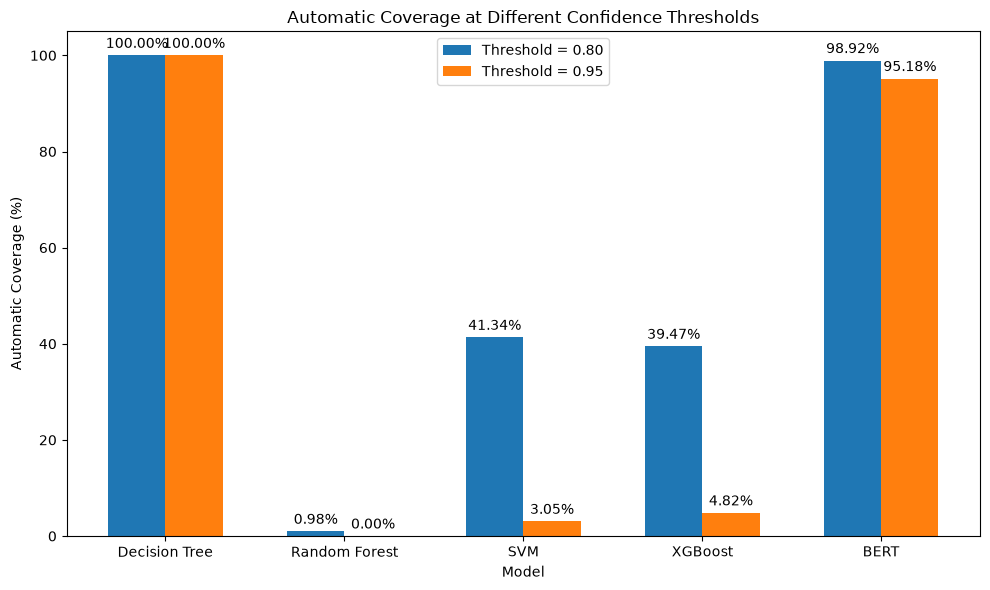

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Confidence-aware results
data = {
    "Model": [
        "Decision Tree", "Decision Tree",
        "Random Forest", "Random Forest",
        "SVM", "SVM",
        "XGBoost", "XGBoost",
        "BERT", "BERT"
    ],
    "Threshold": [
        0.80, 0.95,
        0.80, 0.95,
        0.80, 0.95,
        0.80, 0.95,
        0.80, 0.95
    ],
    "Total": [1016] * 10,
    "Automatic Decisions": [
        1016, 1016,
        10, 0,
        420, 31,
        401, 49,
        1005, 967
    ]
}

df = pd.DataFrame(data)

# Calculate coverage directly from Automatic Decisions / Total
df["Coverage"] = (
    df["Automatic Decisions"] / df["Total"] * 100
)

# Separate thresholds
threshold_080 = df[df["Threshold"] == 0.80]
threshold_095 = df[df["Threshold"] == 0.95]

models = [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost",
    "BERT"
]

coverage_080 = [
    threshold_080.loc[
        threshold_080["Model"] == model, "Coverage"
    ].iloc[0]
    for model in models
]

coverage_095 = [
    threshold_095.loc[
        threshold_095["Model"] == model, "Coverage"
    ].iloc[0]
    for model in models
]

# Plot
x = np.arange(len(models))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width / 2,
    coverage_080,
    width,
    label="Threshold = 0.80"
)

bars2 = ax.bar(
    x + width / 2,
    coverage_095,
    width,
    label="Threshold = 0.95"
)

# Labels on bars
ax.bar_label(
    bars1,
    labels=[f"{v:.2f}%" for v in coverage_080],
    padding=3
)

ax.bar_label(
    bars2,
    labels=[f"{v:.2f}%" for v in coverage_095],
    padding=3
)

ax.set_xlabel("Model")
ax.set_ylabel("Automatic Coverage (%)")
ax.set_title("Automatic Coverage at Different Confidence Thresholds")

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP — REQUIREMENT-LEVEL COMPARISON ACROSS ALL MODELS
# Decision Tree | Random Forest | SVM | XGBoost | BERT
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

THRESHOLD = 0.95

MODEL_NAMES = [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost",
    "BERT"
]

# ------------------------------------------------------------
# TEST DATA
# ------------------------------------------------------------

test_text = pd.Series(X_test_text).reset_index(drop=True)
test_actual = pd.Series(y_test).reset_index(drop=True)

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def class_name(label):
    return "Ambiguous" if int(label) == 1 else "Clear"

def prediction_class(prediction):
    return "Ambiguous" if int(prediction) == 1 else "Clear"

# ------------------------------------------------------------
# CREATE MASTER REQUIREMENT TABLE
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Requirement": test_text,
    "Actual Label": test_actual,
    "Actual Class": test_actual.apply(class_name)
})

# ============================================================
# TRADITIONAL MODELS
# ============================================================

for model_name in [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost"
]:

    pred = np.asarray(predictions[model_name])

    prob_ambiguous = np.asarray(
        probabilities[model_name]
    )

    # Probability of predicted class
    confidence = np.where(
        pred == 1,
        prob_ambiguous,
        1 - prob_ambiguous
    )

    correct = (
        pred == test_actual.to_numpy()
    )

    automatic = confidence >= THRESHOLD

    comparison[f"{model_name} Prediction"] = [
        prediction_class(x)
        for x in pred
    ]

    comparison[f"{model_name} Confidence"] = confidence

    comparison[f"{model_name} Correct"] = np.where(
        correct,
        "Correct",
        "Incorrect"
    )

    comparison[f"{model_name} Action"] = np.where(
        automatic,
        "Automatic Decision",
        "Human Review"
    )

# ============================================================
# BERT
# ============================================================

bert_pred = np.asarray(
    test_calibrated_predictions
)

bert_prob = np.asarray(
    test_calibrated_probabilities[:, 1]
)

bert_confidence = np.asarray(
    test_calibrated_confidence
)

bert_correct = (
    bert_pred == test_actual.to_numpy()
)

bert_automatic = (
    bert_confidence >= THRESHOLD
)

comparison["BERT Prediction"] = [
    prediction_class(x)
    for x in bert_pred
]

comparison["BERT Confidence"] = (
    bert_confidence
)

comparison["BERT Correct"] = np.where(
    bert_correct,
    "Correct",
    "Incorrect"
)

comparison["BERT Action"] = np.where(
    bert_automatic,
    "Automatic Decision",
    "Human Review"
)

# ============================================================
# FORMAT CONFIDENCE
# ============================================================

confidence_columns = [
    col for col in comparison.columns
    if "Confidence" in col
]

for col in confidence_columns:
    comparison[col] = comparison[col].astype(float)

# ============================================================
# DISPLAY COMPLETE COMPARISON
# ============================================================

print("=" * 130)
print("REQUIREMENT-LEVEL MODEL COMPARISON")
print(f"CONFIDENCE THRESHOLD = {THRESHOLD}")
print("=" * 130)

display(comparison.head(10))

REQUIREMENT-LEVEL MODEL COMPARISON
CONFIDENCE THRESHOLD = 0.95


,Requirement,Actual Label,Actual Class,Decision Tree Prediction,Decision Tree Confidence,Decision Tree Correct,Decision Tree Action,Random Forest Prediction,Random Forest Confidence,Random Forest Correct,...,SVM Correct,SVM Action,XGBoost Prediction,XGBoost Confidence,XGBoost Correct,XGBoost Action,BERT Prediction,BERT Confidence,BERT Correct,BERT Action
0,The solution should enable the help-desk user ...,1,Ambiguous,Clear,1.0,Incorrect,Automatic Decision,Ambiguous,0.650000,Correct,...,Correct,Human Review,Ambiguous,0.932013,Correct,Human Review,Ambiguous,0.995946,Correct,Automatic Decision
1,The support solution should be accessible to t...,1,Ambiguous,Ambiguous,1.0,Correct,Automatic Decision,Ambiguous,0.680000,Correct,...,Correct,Human Review,Ambiguous,0.898368,Correct,Human Review,Ambiguous,0.995584,Correct,Automatic Decision
2,The System must maintain the audit trail for a...,1,Ambiguous,Clear,1.0,Incorrect,Automatic Decision,Clear,0.530000,Incorrect,...,Incorrect,Human Review,Clear,0.914548,Incorrect,Human Review,Clear,0.988545,Incorrect,Automatic Decision
3,The System must be able to export audit trails...,0,Clear,Ambiguous,1.0,Incorrect,Automatic Decision,Ambiguous,0.616667,Incorrect,...,Incorrect,Human Review,Ambiguous,0.735640,Incorrect,Human Review,Clear,0.984974,Correct,Automatic Decision
4,the most stringent) implies that the System mu...,0,Clear,Clear,1.0,Correct,Automatic Decision,Ambiguous,0.526667,Incorrect,...,Correct,Human Review,Ambiguous,0.545133,Incorrect,Human Review,Clear,0.975173,Correct,Automatic Decision
5,"If a user performs a quick or advanced search,...",1,Ambiguous,Ambiguous,1.0,Correct,Automatic Decision,Ambiguous,0.680000,Correct,...,Correct,Human Review,Ambiguous,0.983527,Correct,Automatic Decision,Clear,0.507538,Incorrect,Human Review
6,"Ideally, each error message will be accompanie...",1,Ambiguous,Clear,1.0,Incorrect,Automatic Decision,Clear,0.516667,Incorrect,...,Correct,Human Review,Ambiguous,0.506217,Correct,Human Review,Ambiguous,0.995460,Correct,Automatic Decision
7,The interfaces must be made customizable or us...,0,Clear,Ambiguous,1.0,Incorrect,Automatic Decision,Ambiguous,0.643333,Incorrect,...,Incorrect,Human Review,Ambiguous,0.911111,Incorrect,Human Review,Clear,0.986370,Correct,Automatic Decision
8,Navigation should be designed to help users un...,1,Ambiguous,Ambiguous,1.0,Correct,Automatic Decision,Ambiguous,0.770000,Correct,...,Correct,Automatic Decision,Ambiguous,0.977749,Correct,Automatic Decision,Ambiguous,0.995832,Correct,Automatic Decision
9,User interfaces should be designed to allow ac...,1,Ambiguous,Ambiguous,1.0,Correct,Automatic Decision,Ambiguous,0.583333,Correct,...,Correct,Human Review,Ambiguous,0.786456,Correct,Human Review,Ambiguous,0.995609,Correct,Automatic Decision


In [ ]:
# ============================================================
# SECTION 1 — BERT AUTOMATIC DECISION EXAMPLES
# ============================================================

automatic_examples = comparison[
    comparison["BERT Action"] == "Automatic Decision"
].copy()

print("\n")
print("=" * 130)
print("SECTION 1 — AUTOMATIC DECISION EXAMPLES")
print(f"BERT THRESHOLD = {THRESHOLD}")
print("=" * 130)

display(
    automatic_examples[
        [
            "Requirement",
            "Actual Class",

            "Decision Tree Prediction",
            "Decision Tree Confidence",
            "Decision Tree Correct",

            "Random Forest Prediction",
            "Random Forest Confidence",
            "Random Forest Correct",

            "SVM Prediction",
            "SVM Confidence",
            "SVM Correct",

            "XGBoost Prediction",
            "XGBoost Confidence",
            "XGBoost Correct",

            "BERT Prediction",
            "BERT Confidence",
            "BERT Correct",
            "BERT Action"
        ]
    ].head(10).style.format({
        "Decision Tree Confidence": "{:.2%}",
        "Random Forest Confidence": "{:.2%}",
        "SVM Confidence": "{:.2%}",
        "XGBoost Confidence": "{:.2%}",
        "BERT Confidence": "{:.2%}"
    })
)



SECTION 1 — AUTOMATIC DECISION EXAMPLES
BERT THRESHOLD = 0.95


,Requirement,Actual Class,Decision Tree Prediction,Decision Tree Confidence,Decision Tree Correct,Random Forest Prediction,Random Forest Confidence,Random Forest Correct,SVM Prediction,SVM Confidence,SVM Correct,XGBoost Prediction,XGBoost Confidence,XGBoost Correct,BERT Prediction,BERT Confidence,BERT Correct,BERT Action
0,"The solution should enable the help-desk user to view the reports on the submitted defects or enhancement requests category-wise, status-wise, and agewise.",Ambiguous,Clear,100.00%,Incorrect,Ambiguous,65.00%,Correct,Ambiguous,93.32%,Correct,Ambiguous,93.20%,Correct,Ambiguous,99.59%,Correct,Automatic Decision
1,The support solution should be accessible to the users both from within the application and also outside the application through a browser interface.,Ambiguous,Ambiguous,100.00%,Correct,Ambiguous,68.00%,Correct,Ambiguous,89.63%,Correct,Ambiguous,89.84%,Correct,Ambiguous,99.56%,Correct,Automatic Decision
2,"The System must maintain the audit trail for as long as required, which will be at least for the life of the case to which it refers.",Ambiguous,Clear,100.00%,Incorrect,Clear,53.00%,Incorrect,Clear,80.07%,Incorrect,Clear,91.45%,Incorrect,Clear,98.85%,Incorrect,Automatic Decision
3,The System must be able to export audit trails for specified cases (without affecting the audit trail stored by the System).,Clear,Ambiguous,100.00%,Incorrect,Ambiguous,61.67%,Incorrect,Ambiguous,70.77%,Incorrect,Ambiguous,73.56%,Incorrect,Clear,98.50%,Correct,Automatic Decision
4,the most stringent) implies that the System must not include such cases in any count of search results;,Clear,Clear,100.00%,Correct,Ambiguous,52.67%,Incorrect,Clear,63.50%,Correct,Ambiguous,54.51%,Incorrect,Clear,97.52%,Correct,Automatic Decision
6,"Ideally, each error message will be accompanied by explanatory text and an indication of the action(s) which the user can take in response to the error.",Ambiguous,Clear,100.00%,Incorrect,Clear,51.67%,Incorrect,Ambiguous,67.87%,Correct,Ambiguous,50.62%,Correct,Ambiguous,99.55%,Correct,Automatic Decision
7,The interfaces must be made customizable or user-configurable to the extent possible.,Clear,Ambiguous,100.00%,Incorrect,Ambiguous,64.33%,Incorrect,Ambiguous,80.04%,Incorrect,Ambiguous,91.11%,Incorrect,Clear,98.64%,Correct,Automatic Decision
8,"Navigation should be designed to help users understand where they are, where they have been and where they can go next.",Ambiguous,Ambiguous,100.00%,Correct,Ambiguous,77.00%,Correct,Ambiguous,96.03%,Correct,Ambiguous,97.77%,Correct,Ambiguous,99.58%,Correct,Automatic Decision
9,User interfaces should be designed to allow activation of controls by a variety of input devices.,Ambiguous,Ambiguous,100.00%,Correct,Ambiguous,58.33%,Correct,Ambiguous,66.02%,Correct,Ambiguous,78.65%,Correct,Ambiguous,99.56%,Correct,Automatic Decision
10,ISO 9241-303 shall be consulted for screen text legibility requirements.,Clear,Clear,100.00%,Correct,Ambiguous,51.67%,Incorrect,Clear,68.21%,Correct,Ambiguous,51.26%,Incorrect,Clear,98.98%,Correct,Automatic Decision


In [ ]:
# ============================================================
# SECTION 2 — BERT HUMAN REVIEW EXAMPLES
# ============================================================

human_review_examples = comparison[
    comparison["BERT Action"] == "Human Review"
].copy()

# Sort by lowest confidence first
human_review_examples = (
    human_review_examples
    .sort_values("BERT Confidence")
)

print("\n")
print("=" * 130)
print("SECTION 2 — HUMAN REVIEW EXAMPLES")
print(f"BERT THRESHOLD = {THRESHOLD}")
print("=" * 130)

display(
    human_review_examples[
        [
            "Requirement",
            "Actual Class",

            "Decision Tree Prediction",
            "Decision Tree Confidence",

            "Random Forest Prediction",
            "Random Forest Confidence",

            "SVM Prediction",
            "SVM Confidence",

            "XGBoost Prediction",
            "XGBoost Confidence",

            "BERT Prediction",
            "BERT Confidence",
            "BERT Correct",
            "BERT Action"
        ]
    ].head(10).style.format({
        "Decision Tree Confidence": "{:.2%}",
        "Random Forest Confidence": "{:.2%}",
        "SVM Confidence": "{:.2%}",
        "XGBoost Confidence": "{:.2%}",
        "BERT Confidence": "{:.2%}"
    })
)



SECTION 2 — HUMAN REVIEW EXAMPLES
BERT THRESHOLD = 0.95


,Requirement,Actual Class,Decision Tree Prediction,Decision Tree Confidence,Random Forest Prediction,Random Forest Confidence,SVM Prediction,SVM Confidence,XGBoost Prediction,XGBoost Confidence,BERT Prediction,BERT Confidence,BERT Correct,BERT Action
5,"If a user performs a quick or advanced search, the System must never include in the search result list any record which the user does not have the right to access.",Ambiguous,Ambiguous,100.00%,Ambiguous,68.00%,Ambiguous,88.70%,Ambiguous,98.35%,Clear,50.75%,Incorrect,Human Review
549,"If Claim is for first follow up Claim Amount will capture First Follow up Fee (from VSP Payment terms) + (Qty of drugs * Retails Price (from Drugs Master) If Claim is for second follow up Claim Amount will capture Second Follow up Fee (from VSP Payment terms) + (Qty of drugs * Retails Price (from Drugs Master) The system captures the thump impression available in each claim form, and needs to compare it with the same voucher numbers previous visits if available.",Ambiguous,Ambiguous,100.00%,Ambiguous,56.00%,Ambiguous,82.71%,Ambiguous,92.84%,Clear,60.00%,Incorrect,Human Review
272,"3.2.2.23 Monitor Compute Errors – The BE shall trap, flag and repair inf’s, NaN’s, underflows, overflows and other computation errors.",Ambiguous,Ambiguous,100.00%,Clear,63.33%,Clear,79.32%,Clear,64.03%,Clear,60.80%,Incorrect,Human Review
593,"Pontis 5.0 Functional Requirements Specification v1.0 2.8 The user shall be able to select projects (work) on a supported map display and generate a project/bridge list for use within Pontis, for example, to display results of a simulation analysis or to generate a STIP display.",Ambiguous,Clear,100.00%,Clear,51.67%,Clear,54.22%,Clear,62.68%,Clear,63.75%,Incorrect,Human Review
944,"• tools to scan ﬁles for malware and viruses and identify them as such in the WARC ﬁle FR 7 — The migration process shall use persistent, opaque, unique, and global identiﬁers for records access.",Clear,Clear,100.00%,Clear,59.00%,Clear,56.51%,Clear,63.13%,Clear,64.41%,Correct,Human Review
591,"2.5 The user shall be able to filter and select work candidates by structure ID, project ID, program, action type, project status, review status, treatment, program year, and project end date.",Clear,Clear,100.00%,Ambiguous,53.00%,Ambiguous,68.31%,Ambiguous,84.02%,Ambiguous,69.35%,Incorrect,Human Review
339,"REL-02 The system must function reliably, with few or no interruptions in its first operational year and fewer still thereafter.",Ambiguous,Clear,100.00%,Ambiguous,52.33%,Ambiguous,55.80%,Clear,59.19%,Clear,73.08%,Incorrect,Human Review
692,"(M) 5.2.2.29 The lead driver shall be notified if a member of the group has placed the call on hold, although this shall not affect communications between the remaining members of the group.",Clear,Ambiguous,100.00%,Clear,59.33%,Clear,90.48%,Clear,78.91%,Ambiguous,73.36%,Incorrect,Human Review
177,"which data needs to be exchanged and how it shall be done, but not how the data shall be used by the SCADA-system.",Ambiguous,Ambiguous,100.00%,Clear,53.67%,Clear,83.86%,Clear,80.15%,Ambiguous,78.01%,Correct,Human Review
711,(M) 3.1.1.2 Intentionally deleted 3.1.1.3 Intentionally deleted 3.1.1.4 Intentionally deleted 3.1.1.5 Intentionally deleted 3.1.1.6 Intentionally deleted 3.1.1.7 Intentionally deleted 3.1.1.8 Intentionally deleted 3.1.1.9 Intentionally deleted 3.1.1.10 ETCS is required to be functional to a maximum train speed of 500 km/h.,Clear,Ambiguous,100.00%,Clear,59.67%,Clear,80.12%,Clear,57.87%,Clear,78.98%,Correct,Human Review


In [ ]:
# ============================================================
# SECTION 3 — MODEL DISAGREEMENT EXAMPLES
# ============================================================

disagreement_mask = (
    comparison[
        [
            "Decision Tree Prediction",
            "Random Forest Prediction",
            "SVM Prediction",
            "XGBoost Prediction",
            "BERT Prediction"
        ]
    ]
    .nunique(axis=1)
    > 1
)

disagreement_examples = comparison[
    disagreement_mask
].copy()

print("\n")
print("=" * 130)
print("SECTION 3 — MODEL DISAGREEMENT EXAMPLES")
print("=" * 130)

display(
    disagreement_examples[
        [
            "Requirement",
            "Actual Class",

            "Decision Tree Prediction",
            "Decision Tree Confidence",

            "Random Forest Prediction",
            "Random Forest Confidence",

            "SVM Prediction",
            "SVM Confidence",

            "XGBoost Prediction",
            "XGBoost Confidence",

            "BERT Prediction",
            "BERT Confidence",
            "BERT Correct",
            "BERT Action"
        ]
    ].head(10).style.format({
        "Decision Tree Confidence": "{:.2%}",
        "Random Forest Confidence": "{:.2%}",
        "SVM Confidence": "{:.2%}",
        "XGBoost Confidence": "{:.2%}",
        "BERT Confidence": "{:.2%}"
    })
)



SECTION 3 — MODEL DISAGREEMENT EXAMPLES


,Requirement,Actual Class,Decision Tree Prediction,Decision Tree Confidence,Random Forest Prediction,Random Forest Confidence,SVM Prediction,SVM Confidence,XGBoost Prediction,XGBoost Confidence,BERT Prediction,BERT Confidence,BERT Correct,BERT Action
0,"The solution should enable the help-desk user to view the reports on the submitted defects or enhancement requests category-wise, status-wise, and agewise.",Ambiguous,Clear,100.00%,Ambiguous,65.00%,Ambiguous,93.32%,Ambiguous,93.20%,Ambiguous,99.59%,Correct,Automatic Decision
3,The System must be able to export audit trails for specified cases (without affecting the audit trail stored by the System).,Clear,Ambiguous,100.00%,Ambiguous,61.67%,Ambiguous,70.77%,Ambiguous,73.56%,Clear,98.50%,Correct,Automatic Decision
4,the most stringent) implies that the System must not include such cases in any count of search results;,Clear,Clear,100.00%,Ambiguous,52.67%,Clear,63.50%,Ambiguous,54.51%,Clear,97.52%,Correct,Automatic Decision
5,"If a user performs a quick or advanced search, the System must never include in the search result list any record which the user does not have the right to access.",Ambiguous,Ambiguous,100.00%,Ambiguous,68.00%,Ambiguous,88.70%,Ambiguous,98.35%,Clear,50.75%,Incorrect,Human Review
6,"Ideally, each error message will be accompanied by explanatory text and an indication of the action(s) which the user can take in response to the error.",Ambiguous,Clear,100.00%,Clear,51.67%,Ambiguous,67.87%,Ambiguous,50.62%,Ambiguous,99.55%,Correct,Automatic Decision
7,The interfaces must be made customizable or user-configurable to the extent possible.,Clear,Ambiguous,100.00%,Ambiguous,64.33%,Ambiguous,80.04%,Ambiguous,91.11%,Clear,98.64%,Correct,Automatic Decision
10,ISO 9241-303 shall be consulted for screen text legibility requirements.,Clear,Clear,100.00%,Ambiguous,51.67%,Clear,68.21%,Ambiguous,51.26%,Clear,98.98%,Correct,Automatic Decision
11,Links that open new browser windows or pop-up windows should be clearly marked.,Ambiguous,Clear,100.00%,Ambiguous,60.67%,Ambiguous,91.48%,Ambiguous,82.27%,Ambiguous,99.58%,Correct,Automatic Decision
13,"In addition, when designing multimedia information presentations, the design principles and recommendations described in ISO 14915-1 to ISO 14915-3 should be taken into account.",Ambiguous,Clear,100.00%,Ambiguous,59.67%,Ambiguous,71.06%,Ambiguous,84.74%,Ambiguous,99.58%,Correct,Automatic Decision
14,Each page should contain a link leading to the home page of the application or to a landmark page that is easy to recognize for the user.,Ambiguous,Clear,100.00%,Ambiguous,68.00%,Ambiguous,90.57%,Ambiguous,89.94%,Ambiguous,99.55%,Correct,Automatic Decision


In [ ]:
# ======================================================================
# FINAL REQUIREMENT-LEVEL COMPARISON
# Decision Tree | Random Forest | SVM | XGBoost | BERT
# Includes prediction, confidence, correctness and final action
# ======================================================================

import pandas as pd
import numpy as np

# ----------------------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------------------

THRESHOLD = 0.95

# 0 = Clear
# 1 = Ambiguous

# ----------------------------------------------------------------------
# TEST REQUIREMENTS AND ACTUAL LABELS
# ----------------------------------------------------------------------

requirements = pd.Series(X_test_text).reset_index(drop=True)
actual_labels = pd.Series(y_test).reset_index(drop=True)

comparison = pd.DataFrame({
    "Requirement": requirements,
    "Actual": actual_labels.map({
        0: "Clear",
        1: "Ambiguous"
    })
})

# ======================================================================
# FUNCTION: BUILD MODEL RESULT
# ======================================================================

def add_model_results(
    df,
    model_name,
    predictions_array,
    probability_class1
):
    
    predictions_array = np.asarray(predictions_array)
    probability_class1 = np.asarray(probability_class1)

    # --------------------------------------------------------------
    # Prediction
    # --------------------------------------------------------------

    predicted_class = np.where(
        predictions_array == 1,
        "Ambiguous",
        "Clear"
    )

    # --------------------------------------------------------------
    # Confidence
    # Probability of the predicted class
    # --------------------------------------------------------------

    confidence = np.where(
        predictions_array == 1,
        probability_class1,
        1 - probability_class1
    )

    # --------------------------------------------------------------
    # Correct / Incorrect
    # --------------------------------------------------------------

    correct = (
        predictions_array ==
        actual_labels.to_numpy()
    )

    # --------------------------------------------------------------
    # Add columns
    # --------------------------------------------------------------

    df[f"{model_name} Prediction"] = predicted_class

    df[f"{model_name} Confidence"] = confidence

    df[f"{model_name} Result"] = np.where(
        correct,
        "Correct",
        "Incorrect"
    )

    return df

# ======================================================================
# TRADITIONAL CLASSIFIERS
# ======================================================================

comparison = add_model_results(
    comparison,
    "Decision Tree",
    predictions["Decision Tree"],
    probabilities["Decision Tree"]
)

comparison = add_model_results(
    comparison,
    "Random Forest",
    predictions["Random Forest"],
    probabilities["Random Forest"]
)

comparison = add_model_results(
    comparison,
    "SVM",
    predictions["SVM"],
    probabilities["SVM"]
)

comparison = add_model_results(
    comparison,
    "XGBoost",
    predictions["XGBoost"],
    probabilities["XGBoost"]
)

# ======================================================================
# BERT
# ======================================================================

bert_predictions = np.asarray(
    test_calibrated_predictions
)

bert_probabilities = np.asarray(
    test_calibrated_probabilities[:, 1]
)

bert_confidence = np.asarray(
    test_calibrated_confidence
)

# BERT prediction
comparison["BERT Prediction"] = np.where(
    bert_predictions == 1,
    "Ambiguous",
    "Clear"
)

# BERT confidence
comparison["BERT Confidence"] = bert_confidence

# BERT correctness
comparison["BERT Result"] = np.where(
    bert_predictions ==
    actual_labels.to_numpy(),
    "Correct",
    "Incorrect"
)

# ======================================================================
# BERT CONFIDENCE-BASED FINAL ACTION
# ======================================================================

comparison["Final Action"] = np.where(
    bert_confidence >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ======================================================================
# MODEL AGREEMENT
# ======================================================================

prediction_columns = [
    "Decision Tree Prediction",
    "Random Forest Prediction",
    "SVM Prediction",
    "XGBoost Prediction",
    "BERT Prediction"
]

comparison["Model Agreement"] = (
    comparison[prediction_columns]
    .nunique(axis=1)
    .map({
        1: "All Agree",
        2: "Disagreement"
    })
)

# ======================================================================
# SELECT FINAL COLUMNS
# ======================================================================

final_comparison = comparison[
    [
        "Requirement",
        "Actual",

        "Decision Tree Prediction",
        "Decision Tree Confidence",
        "Decision Tree Result",

        "Random Forest Prediction",
        "Random Forest Confidence",
        "Random Forest Result",

        "SVM Prediction",
        "SVM Confidence",
        "SVM Result",

        "XGBoost Prediction",
        "XGBoost Confidence",
        "XGBoost Result",

        "BERT Prediction",
        "BERT Confidence",
        "BERT Result",

        "Model Agreement",
        "Final Action"
    ]
].copy()

# ======================================================================
# FORMAT CONFIDENCE VALUES
# ======================================================================

confidence_columns = [
    "Decision Tree Confidence",
    "Random Forest Confidence",
    "SVM Confidence",
    "XGBoost Confidence",
    "BERT Confidence"
]

for col in confidence_columns:
    final_comparison[col] = (
        final_comparison[col]
        .astype(float)
    )

# ======================================================================
# DISPLAY FINAL TABLE
# ======================================================================

print()
print("=" * 150)
print("FINAL REQUIREMENT-LEVEL MODEL COMPARISON")
print("=" * 150)

print(f"Confidence Threshold for BERT: {THRESHOLD:.2f}")
print("0 = Clear | 1 = Ambiguous")
print()

display(
    final_comparison.head(20).style.format({
        "Decision Tree Confidence": "{:.2%}",
        "Random Forest Confidence": "{:.2%}",
        "SVM Confidence": "{:.2%}",
        "XGBoost Confidence": "{:.2%}",
        "BERT Confidence": "{:.2%}"
    })
)

# ======================================================================
# SUMMARY
# ======================================================================

print()
print("=" * 150)
print("FINAL SUMMARY")
print("=" * 150)

print(
    f"Total requirements shown in test set : "
    f"{len(final_comparison)}"
)

print(
    f"BERT Automatic Decisions             : "
    f"{(final_comparison['Final Action'] == 'Automatic Decision').sum()}"
)

print(
    f"BERT Human Review                    : "
    f"{(final_comparison['Final Action'] == 'Human Review').sum()}"
)

print(
    f"Model Agreement                      : "
    f"{(final_comparison['Model Agreement'] == 'All Agree').sum()}"
)

print(
    f"Model Disagreement                   : "
    f"{(final_comparison['Model Agreement'] == 'Disagreement').sum()}"
)


FINAL REQUIREMENT-LEVEL MODEL COMPARISON
Confidence Threshold for BERT: 0.95
0 = Clear | 1 = Ambiguous



,Requirement,Actual,Decision Tree Prediction,Decision Tree Confidence,Decision Tree Result,Random Forest Prediction,Random Forest Confidence,Random Forest Result,SVM Prediction,SVM Confidence,SVM Result,XGBoost Prediction,XGBoost Confidence,XGBoost Result,BERT Prediction,BERT Confidence,BERT Result,Model Agreement,Final Action
0,"The solution should enable the help-desk user to view the reports on the submitted defects or enhancement requests category-wise, status-wise, and agewise.",Ambiguous,Clear,100.00%,Incorrect,Ambiguous,65.00%,Correct,Ambiguous,93.32%,Correct,Ambiguous,93.20%,Correct,Ambiguous,99.59%,Correct,Disagreement,Automatic Decision
1,The support solution should be accessible to the users both from within the application and also outside the application through a browser interface.,Ambiguous,Ambiguous,100.00%,Correct,Ambiguous,68.00%,Correct,Ambiguous,89.63%,Correct,Ambiguous,89.84%,Correct,Ambiguous,99.56%,Correct,All Agree,Automatic Decision
2,"The System must maintain the audit trail for as long as required, which will be at least for the life of the case to which it refers.",Ambiguous,Clear,100.00%,Incorrect,Clear,53.00%,Incorrect,Clear,80.07%,Incorrect,Clear,91.45%,Incorrect,Clear,98.85%,Incorrect,All Agree,Automatic Decision
3,The System must be able to export audit trails for specified cases (without affecting the audit trail stored by the System).,Clear,Ambiguous,100.00%,Incorrect,Ambiguous,61.67%,Incorrect,Ambiguous,70.77%,Incorrect,Ambiguous,73.56%,Incorrect,Clear,98.50%,Correct,Disagreement,Automatic Decision
4,the most stringent) implies that the System must not include such cases in any count of search results;,Clear,Clear,100.00%,Correct,Ambiguous,52.67%,Incorrect,Clear,63.50%,Correct,Ambiguous,54.51%,Incorrect,Clear,97.52%,Correct,Disagreement,Automatic Decision
5,"If a user performs a quick or advanced search, the System must never include in the search result list any record which the user does not have the right to access.",Ambiguous,Ambiguous,100.00%,Correct,Ambiguous,68.00%,Correct,Ambiguous,88.70%,Correct,Ambiguous,98.35%,Correct,Clear,50.75%,Incorrect,Disagreement,Human Review
6,"Ideally, each error message will be accompanied by explanatory text and an indication of the action(s) which the user can take in response to the error.",Ambiguous,Clear,100.00%,Incorrect,Clear,51.67%,Incorrect,Ambiguous,67.87%,Correct,Ambiguous,50.62%,Correct,Ambiguous,99.55%,Correct,Disagreement,Automatic Decision
7,The interfaces must be made customizable or user-configurable to the extent possible.,Clear,Ambiguous,100.00%,Incorrect,Ambiguous,64.33%,Incorrect,Ambiguous,80.04%,Incorrect,Ambiguous,91.11%,Incorrect,Clear,98.64%,Correct,Disagreement,Automatic Decision
8,"Navigation should be designed to help users understand where they are, where they have been and where they can go next.",Ambiguous,Ambiguous,100.00%,Correct,Ambiguous,77.00%,Correct,Ambiguous,96.03%,Correct,Ambiguous,97.77%,Correct,Ambiguous,99.58%,Correct,All Agree,Automatic Decision
9,User interfaces should be designed to allow activation of controls by a variety of input devices.,Ambiguous,Ambiguous,100.00%,Correct,Ambiguous,58.33%,Correct,Ambiguous,66.02%,Correct,Ambiguous,78.65%,Correct,Ambiguous,99.56%,Correct,All Agree,Automatic Decision



FINAL SUMMARY
Total requirements shown in test set : 1016
BERT Automatic Decisions             : 967
BERT Human Review                    : 49
Model Agreement                      : 418
Model Disagreement                   : 598


In [ ]:
# ======================================================================
# FINAL REQUIREMENT-LEVEL COMPARISON
# MODELS AS ROWS
# AUTOMATIC + HUMAN REVIEW IN ONE TABLE
# BERT THRESHOLD = 0.95
# ======================================================================

import pandas as pd
import numpy as np

THRESHOLD = 0.95

print("=" * 120)
print("FINAL REQUIREMENT-LEVEL MODEL COMPARISON")
print("=" * 120)
print(f"BERT Confidence Threshold: {THRESHOLD}")
print("0 = Clear | 1 = Ambiguous")
print()

# ======================================================================
# STEP 1 — USE THE EXISTING COMPARISON DATAFRAME
# ======================================================================

# Your previous code created:
# comparison

df = comparison.copy()

# ======================================================================
# STEP 2 — CONVERT BERT CONFIDENCE TO NUMERIC
# ======================================================================

bert_conf = df["BERT Confidence"].copy()

# Handle both numeric values such as 0.9981
# and strings such as "99.81%"
bert_conf = (
    bert_conf.astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

# If confidence is stored as percentage, convert to 0–1
if bert_conf.max() > 1:
    bert_conf = bert_conf / 100

df["_BERT_CONF_NUM"] = bert_conf

# ======================================================================
# STEP 3 — IDENTIFY AUTOMATIC AND HUMAN REVIEW CASES
# ======================================================================

df["_BERT_ACTION"] = np.where(
    df["_BERT_CONF_NUM"] >= THRESHOLD,
    "Automatic Decision",
    "Human Review"
)

# ======================================================================
# STEP 4 — SELECT EXAMPLES
# ======================================================================

# ------------------------------------------------------------
# Automatic Decision examples
# ------------------------------------------------------------

automatic_examples = (
    df[df["_BERT_ACTION"] == "Automatic Decision"]
    .sort_values("_BERT_CONF_NUM", ascending=False)
    .head(5)
)

# ------------------------------------------------------------
# Human Review examples
# Select lowest-confidence cases
# ------------------------------------------------------------

human_review_examples = (
    df[df["_BERT_ACTION"] == "Human Review"]
    .sort_values("_BERT_CONF_NUM", ascending=True)
    .head(5)
)

# ------------------------------------------------------------
# Combine both types
# ------------------------------------------------------------

selected_examples = pd.concat(
    [
        automatic_examples,
        human_review_examples
    ],
    axis=0
).drop_duplicates()

# ======================================================================
# STEP 5 — MODEL DEFINITIONS
# ======================================================================

models = {
    "Decision Tree": (
        "Decision Tree Prediction",
        "Decision Tree Confidence"
    ),

    "Random Forest": (
        "Random Forest Prediction",
        "Random Forest Confidence"
    ),

    "SVM": (
        "SVM Prediction",
        "SVM Confidence"
    ),

    "XGBoost": (
        "XGBoost Prediction",
        "XGBoost Confidence"
    ),

    "BERT": (
        "BERT Prediction",
        "BERT Confidence"
    )
}

# ======================================================================
# STEP 6 — CONVERT MODELS FROM COLUMNS TO ROWS
# ======================================================================

rows = []

for idx, record in selected_examples.iterrows():

    requirement = record["Requirement"]
    actual = record["Actual"]

    # ----------------------------------------------------------
    # Create one row for each model
    # ----------------------------------------------------------

    for model_name, (prediction_col, confidence_col) in models.items():

        prediction = record[prediction_col]

        confidence = record[confidence_col]

        # Convert confidence to numeric
        confidence_numeric = float(
            str(confidence)
            .replace("%", "")
        )

        if confidence_numeric > 1:
            confidence_numeric /= 100

        # ------------------------------------------------------
        # Correct / Incorrect
        # ------------------------------------------------------

        result = (
            "Correct"
            if prediction == actual
            else "Incorrect"
        )

        # ------------------------------------------------------
        # Final action
        #
        # The confidence-aware decision mechanism is based
        # on BERT confidence.
        # ------------------------------------------------------

        final_action = record["_BERT_ACTION"]

        # ------------------------------------------------------
        # Add row
        # ------------------------------------------------------

        rows.append({
            "Example": idx,
            "Model": model_name,
            "Requirement": requirement,
            "Actual": actual,
            "Prediction": prediction,
            "Confidence": confidence_numeric,
            "Result": result,
            "Final Action": final_action
        })

# ======================================================================
# STEP 7 — FINAL LONG-FORM TABLE
# ======================================================================

final_result_table = pd.DataFrame(rows)

# ======================================================================
# STEP 8 — FORMAT CONFIDENCE
# ======================================================================

final_result_table["Confidence"] = (
    final_result_table["Confidence"]
    .map(lambda x: f"{x:.2%}")
)

# ======================================================================
# STEP 9 — DISPLAY
# ======================================================================

print()
print("=" * 120)
print("FINAL REQUIREMENT-LEVEL COMPARISON")
print("MODELS AS ROWS | AUTOMATIC + HUMAN REVIEW")
print("=" * 120)

display(
    final_result_table[
        [
            "Example",
            "Model",
            "Requirement",
            "Actual",
            "Prediction",
            "Confidence",
            "Result",
            "Final Action"
        ]
    ]
)

# ======================================================================
# STEP 10 — SUMMARY
# ======================================================================

print()
print("=" * 120)
print("BERT CONFIDENCE-AWARE DECISION SUMMARY")
print("=" * 120)

bert_summary = df["_BERT_ACTION"].value_counts()

print(
    f"Total Test Requirements : {len(df)}"
)

print(
    f"Automatic Decisions     : "
    f"{bert_summary.get('Automatic Decision', 0)}"
)

print(
    f"Human Review            : "
    f"{bert_summary.get('Human Review', 0)}"
)

print(
    f"Automatic Coverage      : "
    f"{(df['_BERT_ACTION'] == 'Automatic Decision').mean():.2%}"
)

print(
    f"Human Review Rate       : "
    f"{(df['_BERT_ACTION'] == 'Human Review').mean():.2%}"
)

FINAL REQUIREMENT-LEVEL MODEL COMPARISON
BERT Confidence Threshold: 0.95
0 = Clear | 1 = Ambiguous


FINAL REQUIREMENT-LEVEL COMPARISON
MODELS AS ROWS | AUTOMATIC + HUMAN REVIEW


,Example,Model,Requirement,Actual,Prediction,Confidence,Result,Final Action
0,874,Decision Tree,CRM should allow the creation of a Drop Off ac...,Ambiguous,Ambiguous,100.00%,Correct,Automatic Decision
1,874,Random Forest,CRM should allow the creation of a Drop Off ac...,Ambiguous,Ambiguous,58.67%,Correct,Automatic Decision
2,874,SVM,CRM should allow the creation of a Drop Off ac...,Ambiguous,Ambiguous,95.63%,Correct,Automatic Decision
3,874,XGBoost,CRM should allow the creation of a Drop Off ac...,Ambiguous,Ambiguous,79.60%,Correct,Automatic Decision
4,874,BERT,CRM should allow the creation of a Drop Off ac...,Ambiguous,Ambiguous,99.60%,Correct,Automatic Decision
5,463,Decision Tree,The callback should correctly process resizing...,Ambiguous,Ambiguous,100.00%,Correct,Automatic Decision
6,463,Random Forest,The callback should correctly process resizing...,Ambiguous,Ambiguous,56.67%,Correct,Automatic Decision
7,463,SVM,The callback should correctly process resizing...,Ambiguous,Ambiguous,75.75%,Correct,Automatic Decision
8,463,XGBoost,The callback should correctly process resizing...,Ambiguous,Ambiguous,87.50%,Correct,Automatic Decision
9,463,BERT,The callback should correctly process resizing...,Ambiguous,Ambiguous,99.60%,Correct,Automatic Decision



BERT CONFIDENCE-AWARE DECISION SUMMARY
Total Test Requirements : 1016
Automatic Decisions     : 967
Human Review            : 49
Automatic Coverage      : 95.18%
Human Review Rate       : 4.82%


In [ ]:
print(final_comparison.head())

                                         Requirement     Actual  \
0  The solution should enable the help-desk user ...  Ambiguous   
1  The support solution should be accessible to t...  Ambiguous   
2  The System must maintain the audit trail for a...  Ambiguous   
3  The System must be able to export audit trails...      Clear   
4  the most stringent) implies that the System mu...      Clear   

  Decision Tree Prediction  Decision Tree Confidence Decision Tree Result  \
0                    Clear                       1.0            Incorrect   
1                Ambiguous                       1.0              Correct   
2                    Clear                       1.0            Incorrect   
3                Ambiguous                       1.0            Incorrect   
4                    Clear                       1.0              Correct   

  Random Forest Prediction  Random Forest Confidence Random Forest Result  \
0                Ambiguous                  0.650000     

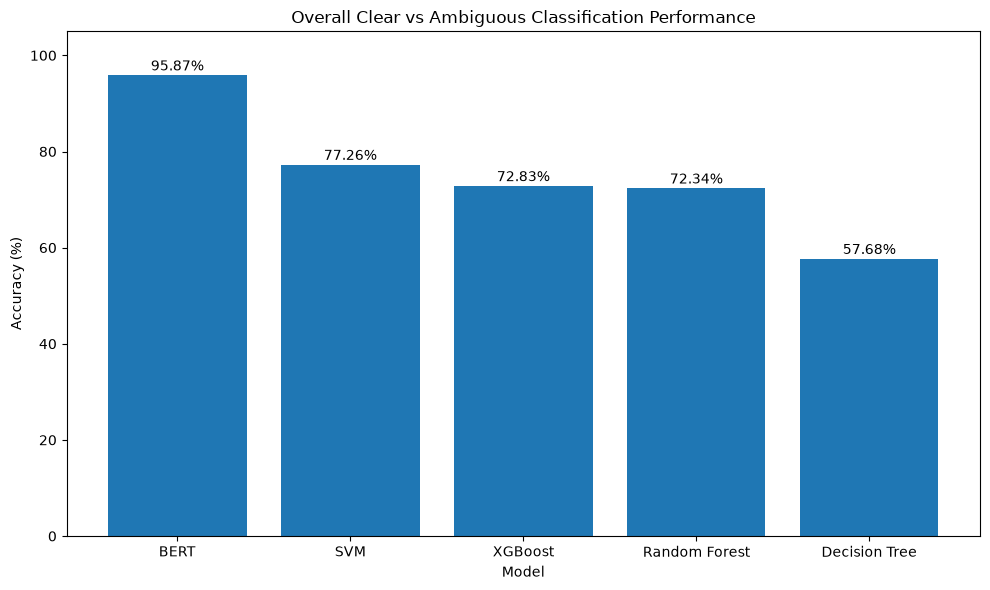

In [ ]:
# ============================================================
# FIGURE 1 — OVERALL ACCURACY COMPARISON
# ============================================================

import matplotlib.pyplot as plt

# Calculate accuracy for each model
models = {
    "Decision Tree": "Decision Tree Prediction",
    "Random Forest": "Random Forest Prediction",
    "SVM": "SVM Prediction",
    "XGBoost": "XGBoost Prediction",
    "BERT": "BERT Prediction"
}

accuracy_results = {}

for model_name, prediction_column in models.items():
    accuracy = (
        final_comparison["Actual"] == final_comparison[prediction_column]
    ).mean() * 100

    accuracy_results[model_name] = accuracy

# Convert to DataFrame
accuracy_df = (
    pd.DataFrame(
        list(accuracy_results.items()),
        columns=["Model", "Accuracy (%)"]
    )
    .sort_values("Accuracy (%)", ascending=False)
)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Overall Clear vs Ambiguous Classification Performance")

plt.ylim(0, 105)

# Add accuracy values above bars
for i, value in enumerate(accuracy_df["Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

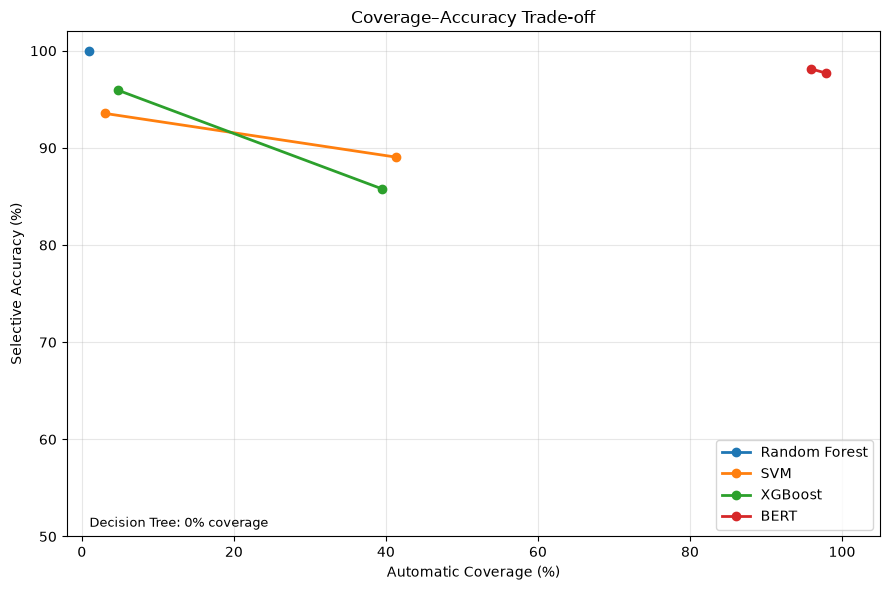

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Decision Tree", "Random Forest", "SVM", "XGBoost", "BERT"]

# Coverage (%)
coverage_80 = [0.00, 0.98, 41.34, 39.47, 97.93]
coverage_95 = [0.00, 0.00, 3.05, 4.82, 95.87]

# Selective accuracy (%)
selective_80 = [np.nan, 100.00, 89.05, 85.79, 97.69]
selective_95 = [np.nan, np.nan, 93.55, 95.92, 98.15]

plt.figure(figsize=(9, 6))

# Plot each model
for i, model in enumerate(models):

    x = []
    y = []

    if not np.isnan(selective_80[i]):
        x.append(coverage_80[i])
        y.append(selective_80[i])

    if not np.isnan(selective_95[i]):
        x.append(coverage_95[i])
        y.append(selective_95[i])

    if len(x) > 0:
        plt.plot(
            x, y,
            marker="o",
            linewidth=2,
            label=model
        )

# Mark zero-coverage cases
plt.text(
    1,
    51,
    "Decision Tree: 0% coverage",
    fontsize=9
)

plt.xlabel("Automatic Coverage (%)")
plt.ylabel("Selective Accuracy (%)")

plt.title(
    "Coverage–Accuracy Trade-off"
)

plt.xlim(-2, 105)
plt.ylim(50, 102)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_2_Coverage_Selective_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

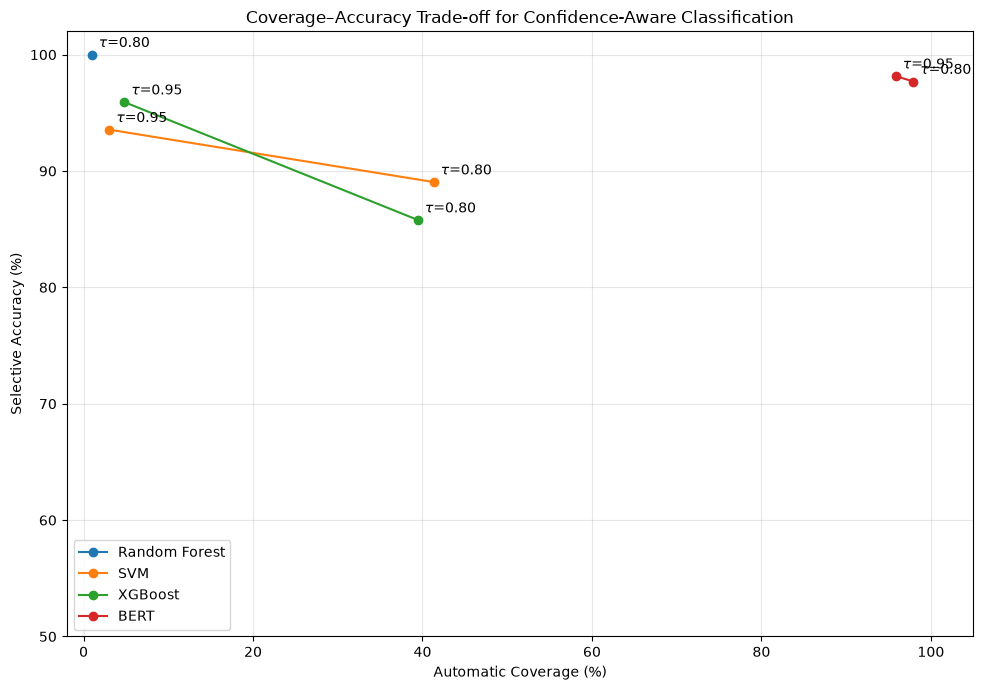

In [ ]:
# ============================================================
# FIGURE 2 — COVERAGE VS SELECTIVE ACCURACY
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

confidence_results = pd.DataFrame({
    "Model": [
        "Decision Tree", "Decision Tree",
        "Random Forest", "Random Forest",
        "SVM", "SVM",
        "XGBoost", "XGBoost",
        "BERT", "BERT"
    ],

    "Threshold": [
        0.80, 0.95,
        0.80, 0.95,
        0.80, 0.95,
        0.80, 0.95,
        0.80, 0.95
    ],

    "Coverage": [
        0.00, 0.00,
        0.98, 0.00,
        41.34, 3.05,
        39.47, 4.82,
        97.93, 95.87
    ],

    "Correct": [
        0, 0,
        10, 0,
        374, 29,
        344, 47,
        972, 956
    ],

    "Incorrect": [
        0, 0,
        0, 0,
        46, 2,
        57, 2,
        23, 18
    ]
})

# Calculate selective accuracy
confidence_results["Selective Accuracy"] = (
    confidence_results["Correct"] /
    (confidence_results["Correct"] +
     confidence_results["Incorrect"])
) * 100

# Remove cases where no prediction was automatically accepted
plot_df = confidence_results[
    (confidence_results["Correct"] +
     confidence_results["Incorrect"]) > 0
].copy()

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 7))

for model in plot_df["Model"].unique():

    subset = plot_df[
        plot_df["Model"] == model
    ].sort_values("Threshold")

    plt.plot(
        subset["Coverage"],
        subset["Selective Accuracy"],
        marker="o",
        label=model
    )

    for _, row in subset.iterrows():

        plt.annotate(
            f"$\\tau$={row['Threshold']:.2f}",
            (
                row["Coverage"],
                row["Selective Accuracy"]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.xlabel("Automatic Coverage (%)")
plt.ylabel("Selective Accuracy (%)")
plt.title(
    "Coverage–Accuracy Trade-off for Confidence-Aware Classification"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(-2, 105)
plt.ylim(50, 102)

plt.tight_layout()
plt.show()

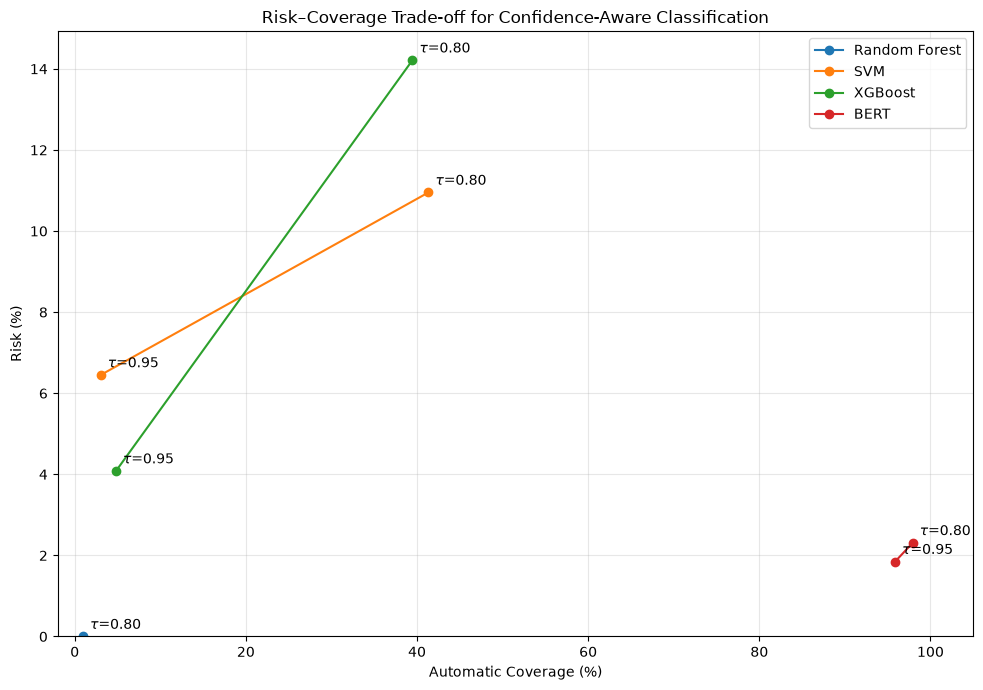

In [ ]:
# ============================================================
# FIGURE 3 — RISK VS COVERAGE
# ============================================================

import matplotlib.pyplot as plt

# Calculate risk (%)
confidence_results["Risk"] = (
    confidence_results["Incorrect"] /
    (
        confidence_results["Correct"] +
        confidence_results["Incorrect"]
    )
) * 100

# Keep only cases with automatic predictions
plot_df = confidence_results[
    (
        confidence_results["Correct"] +
        confidence_results["Incorrect"]
    ) > 0
].copy()

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 7))

for model in plot_df["Model"].unique():

    subset = plot_df[
        plot_df["Model"] == model
    ].sort_values("Threshold")

    plt.plot(
        subset["Coverage"],
        subset["Risk"],
        marker="o",
        label=model
    )

    for _, row in subset.iterrows():

        plt.annotate(
            f"$\\tau$={row['Threshold']:.2f}",
            (
                row["Coverage"],
                row["Risk"]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.xlabel("Automatic Coverage (%)")
plt.ylabel("Risk (%)")

plt.title(
    "Risk–Coverage Trade-off for Confidence-Aware Classification"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(-2, 105)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

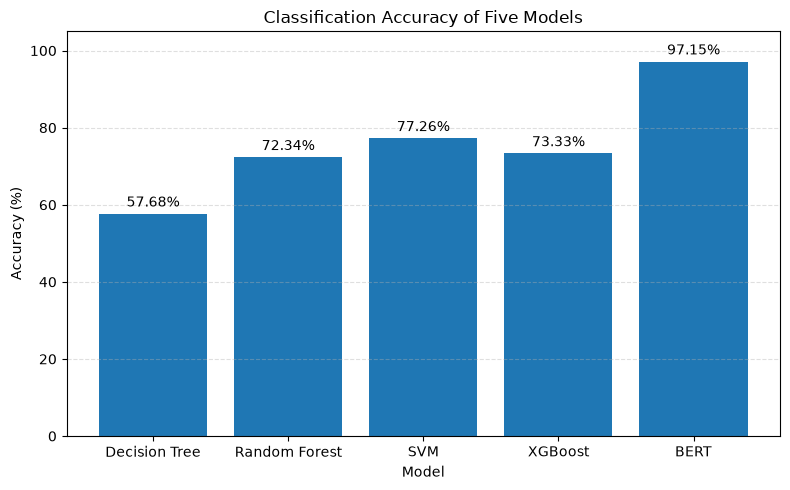

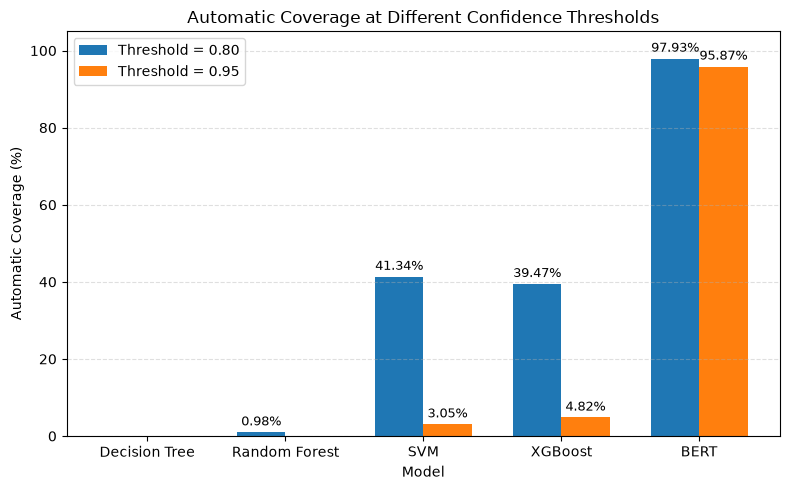

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DATA
# ============================================================

models = [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost",
    "BERT"
]

accuracy = [57.68, 72.34, 77.26, 73.33, 97.15]

# Confidence-aware automatic coverage
coverage_080 = [0.00, 0.98, 41.34, 39.47, 97.93]
coverage_095 = [0.00, 0.00, 3.05, 4.82, 95.87]

# ============================================================
# FIGURE 1
# Classification Accuracy of Five Models
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Classification Accuracy of Five Models")

plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Display values above bars
for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Figure_1_Model_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 2
# Automatic Coverage at Confidence Thresholds
# ============================================================

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    coverage_080,
    width,
    label="Threshold = 0.80"
)

bars2 = plt.bar(
    x + width / 2,
    coverage_095,
    width,
    label="Threshold = 0.95"
)

plt.ylabel("Automatic Coverage (%)")
plt.xlabel("Model")
plt.title("Automatic Coverage at Different Confidence Thresholds")

plt.xticks(x, models)
plt.ylim(0, 105)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

# Display values above bars
for bar, value in zip(bars1, coverage_080):
    if value > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

for bar, value in zip(bars2, coverage_095):
    if value > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "Figure_2_Confidence_Coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

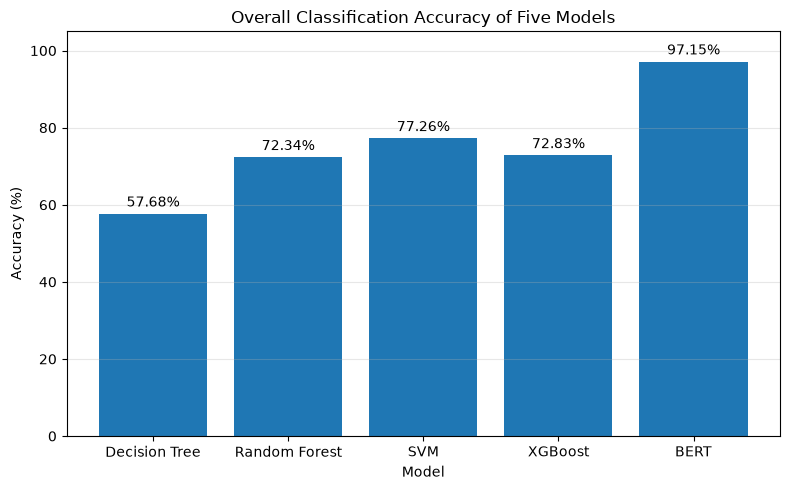

In [ ]:
# ============================================================
# FIGURE 1 — OVERALL CLASSIFICATION ACCURACY
# ============================================================

import matplotlib.pyplot as plt

models = [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost",
    "BERT"
]

accuracy = [
    57.68,
    72.34,
    77.26,
    72.83,
    97.15
]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracy)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Overall Classification Accuracy of Five Models")

plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "Figure_1_Overall_Classification_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

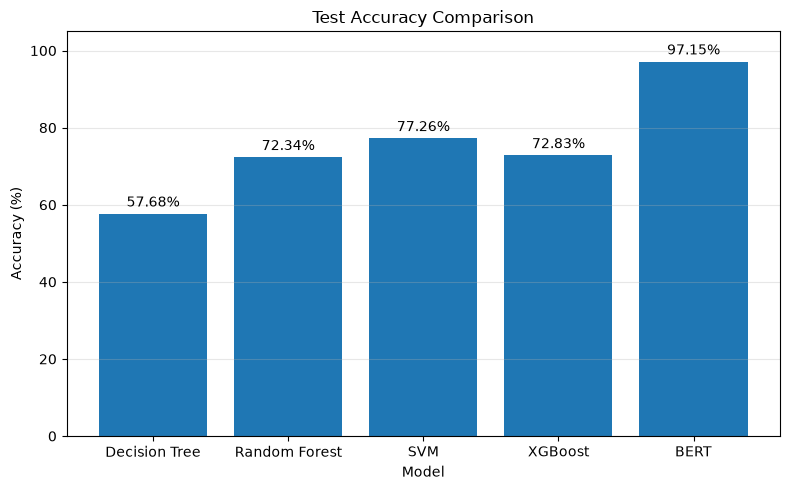

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost",
    "BERT"
]

accuracy = [
    57.68,
    72.34,
    77.26,
    72.83,
    97.15
]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracy)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy Comparison")

plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "Figure_1_Test_Accuracy_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

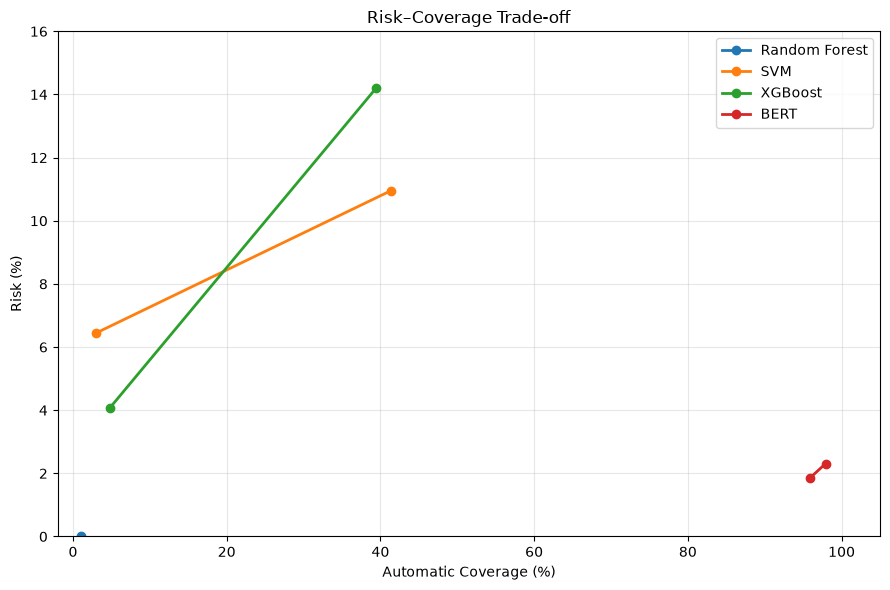

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Decision Tree", "Random Forest", "SVM", "XGBoost", "BERT"]

# Coverage (%)
coverage_80 = [0.00, 0.98, 41.34, 39.47, 97.93]
coverage_95 = [0.00, 0.00, 3.05, 4.82, 95.87]

# Risk (%)
risk_80 = [np.nan, 0.00, 10.95, 14.21, 2.31]
risk_95 = [np.nan, np.nan, 6.45, 4.08, 1.85]

plt.figure(figsize=(9, 6))

for i, model in enumerate(models):

    x = []
    y = []

    if not np.isnan(risk_80[i]):
        x.append(coverage_80[i])
        y.append(risk_80[i])

    if not np.isnan(risk_95[i]):
        x.append(coverage_95[i])
        y.append(risk_95[i])

    if len(x) > 0:
        plt.plot(
            x, y,
            marker="o",
            linewidth=2,
            label=model
        )

plt.xlabel("Automatic Coverage (%)")
plt.ylabel("Risk (%)")

plt.title(
    "Risk–Coverage Trade-off"
)

plt.xlim(-2, 105)
plt.ylim(0, 16)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_3_Risk_Coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()